In [1]:
#directorio raiz donde esta el framework
%cd D:\tesis\scrpt pyton\interfaz_correccion\interfaz_correccion\efficient-kan\src\efficient_kan

D:\tesis\scrpt pyton\interfaz_correccion\interfaz_correccion\efficient-kan\src\efficient_kan


C:\Users\ferro\AppData\Roaming\Python\Python312\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import pandas as pd
import numpy as np
import os
import joblib
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, KFold
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler, MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve, auc, ConfusionMatrixDisplay
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import OneCycleLR
from entmax import sparsemax, entmax15
from lion_pytorch import Lion
from kan import KANLinear, KAN
import shap
import lime
import lime.lime_tabular
# Configuración para usar la GPU si está disponible
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
from sklearn.preprocessing import LabelEncoder

In [3]:
# Establecer semillas para reproducibilidad
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [4]:
# Cargar el dataset desde un archivo Excel
daf = pd.read_excel('D:\\tesis\\Modelo_extraccion_no\\dataset_extraccion_up_low_bimax.xlsx')
daf.columns

Index(['Paciente', 'Edad', 'Genero', 'Etnia', 'Apiñamiento sup',
       'Apiñamiento inf', 'Overbite', 'Overjet', 'SNA', 'SNB', 'ANB',
       'A-Macna', 'Pg-Macna', 'IMPA', 'SN-MP', 'SN-GoGn', 'Fh-Npog',
       'Ngo-GoMe', 'NS-SGn', 'U1-Sn', 'U1-PP', 'U1-NA(mm)', 'U1-Na(°)',
       'L1-NB(mm)', 'L1-NB(°)', 'U1-L1', 'L1-Apog', 'U1-Apog', 'Sts-Sti',
       'UL-E-Line', 'LL-E-Line', 'UlSn-SnPmn', 'LLB'-B'Pog'',
       'discrepancia total inferior', 'discrepancia total superior',
       'Clasificación  esqueletica', 'Relación molar', 'Relación premolar',
       'Relacion canina', 'Clase real', 'Extraccion / no extraccion inf',
       'Extraccion / no extraccion sup', 'Extraccion tejidos blandos',
       'Extraccion / no extraccion', 'Tipo de extraccióin global'],
      dtype='object')

In [5]:
daf.drop(columns=["Extraccion / no extraccion inf","Extraccion / no extraccion sup", "Extraccion / no extraccion","Paciente","Extraccion tejidos blandos",'discrepancia total inferior', 'discrepancia total superior',"Clase real"],inplace=True)
daf

,Edad,Genero,Etnia,Apiñamiento sup,Apiñamiento inf,Overbite,Overjet,SNA,SNB,ANB,...,Sts-Sti,UL-E-Line,LL-E-Line,UlSn-SnPmn,LLB'-B'Pog',Clasificación esqueletica,Relación molar,Relación premolar,Relacion canina,Tipo de extraccióin global
0,39,F,afrocolombiana,-4.00,-16.0,5.945810,2.202145,84.573158,82.968865,-1.604293,...,0.220212,-4.876738,0.516159,88.976967,153.536996,Clase 3,clase 1,clase 1,clase 2,Extracción bima
1,29,F,meztizo,-2.50,-5.5,2.797421,1.165594,81.689042,76.753278,4.935764,...,0.233121,-4.594830,-1.478628,76.829501,150.843664,Clase 2,clase 1,clase 1,clase 1,Extracción bima
2,27,F,meztizo,-0.70,-0.4,-1.864948,0.233121,88.991416,88.257801,0.733615,...,0.233121,-3.142670,-2.029610,75.193551,132.754262,Clase 3,clase 3,clase 3,clase 3,No extracción
3,42,F,meztizo,4.69,-2.5,3.729886,2.098068,81.962304,77.149397,4.812907,...,0.000000,-4.233241,-2.474814,58.780804,136.972533,Clase 2,clase 2,clase 2,clase 2,No extracción
4,33,F,meztizo,7.17,-3.8,3.263663,1.165594,85.601294,80.637686,4.963608,...,0.233121,-1.258132,2.175378,75.805316,158.163527,Clase 2,clase 3,clase 3,clase 1,Extracción inf.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,40,M,meztizo,0.00,-1.0,-0.308762,-4.322586,85.785459,86.081896,0.296437,...,0.000000,-6.782278,-4.331714,64.730585,168.402454,Clase 3,clase 3,clase 3,clase 3,Extracción bima
496,23,M,meztizo,3.00,-2.0,2.778801,4.013824,81.468412,78.959218,2.509194,...,0.308762,-1.294142,-1.249473,86.513197,141.985936,Clase 2,clase 1,clase 1,clase 1,No extracción
497,19,M,meztizo,-6.00,-5.0,5.633917,3.442950,85.643270,80.706450,4.936821,...,0.938992,-3.556261,-0.994024,30.703272,138.691411,Clase 2,clase 2,clase 2,clase 2,No extracción
498,34,M,afrocolombiana,6.00,1.0,0.599442,-3.296960,85.662749,87.259750,7.077501,...,0.899167,1.513549,5.711739,95.258436,154.902959,Clase 2,clase 2,clase 2,clase 2,Extracción bima


In [6]:
daf["Tipo de extraccióin global"].value_counts()

Tipo de extraccióin global
No extracción      274
Extracción bima    196
Extracción inf.     17
Extracción sup.     13
Name: count, dtype: int64

In [10]:
LabelEncoder_1=LabelEncoder()
daf["Genero"]=LabelEncoder_1.fit_transform(daf["Genero"])
daf["Etnia"]=LabelEncoder_1.fit_transform(daf["Etnia"])
daf["Clasificación  esqueletica"]=LabelEncoder_1.fit_transform(daf["Clasificación  esqueletica"])
daf["Relación molar"]=LabelEncoder_1.fit_transform(daf["Relación molar"])
daf["Relacion canina"]=LabelEncoder_1.fit_transform(daf["Relacion canina"])
daf["Relación premolar"]=LabelEncoder_1.fit_transform(daf["Relación premolar"])

In [11]:
df = daf[daf['Tipo de extraccióin global'] != 'Extracción sup.']

In [12]:
df["Tipo de extraccióin global"].value_counts()

Tipo de extraccióin global
No extracción      274
Extracción bima    196
Extracción inf.     17
Name: count, dtype: int64

In [18]:
df['Tipo de extraccióin global'] = df['Tipo de extraccióin global'].map({'Extracción bima': 1, 'No extracción': 0,"Extracción inf.":1})
Labels = df['Tipo de extraccióin global']
Features = df.drop(['Tipo de extraccióin global'],axis=1)
X_train, X_test, y_train, y_test = train_test_split(Features, Labels, test_size=0.2, stratify=Labels, random_state=42)

C:\Users\ferro\AppData\Local\Temp\ipykernel_28264\3576407119.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Tipo de extraccióin global'] = df['Tipo de extraccióin global'].map({'Extracción bima': 1, 'No extracción': 0,"Extracción sup.":1})


In [19]:
# Guardar los conjuntos de datos de la extracción superior
joblib.dump((X_train, y_train), 'D:\\tesis\\Modelo_extraccion_no\\extrac sup\\Train_inferior.pkl')
joblib.dump((X_test, y_test), 'D:\\tesis\\Modelo_extraccion_no\\extrac sup\\Test_inferior.pkl')

['D:\\tesis\\Modelo_extraccion_no\\extrac sup\\Test_superior.pkl']

# cargar datos 

In [69]:
#CArgar tensores con el data set
# Cargar el dataset balanceado de entrenamiento
X_train, y_train = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac inf\\Train_inferior.pkl')

# Cargar el conjunto de prueba
X_test, y_test = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac inf\\Test_inferior.pkl')

In [70]:
smote = SMOTE(random_state=42)
X_train_resampled_s, y_train_resampled_s = smote.fit_resample(X_train, y_train)

# BALANCED ANY

In [41]:
X_train_unbalance= torch.tensor(X_train_resampled_s.values, dtype=torch.float32)
Y_train_unbalance= torch.tensor(y_train_resampled_s.values, dtype=torch.float32)
X_test_unbalance= torch.tensor(X_test.values, dtype=torch.float32)
Y_test_unbalance= torch.tensor(y_test.values, dtype=torch.float32)

In [42]:
# Verificar el balance de las clases
unique_classes, class_counts = torch.unique(Y_train_unbalance, return_counts=True)
for cls, count in zip(unique_classes, class_counts):
    print(f'Clase {cls.item()}: {count.item()} muestras')

Clase 0.0: 219 muestras
Clase 1.0: 219 muestras


In [43]:
Y_test_unbalance.dtype

torch.float32

## KAN

In [44]:
input_dim = X_train_unbalance.shape[1]
hidden_layers = [128, 64, 32, 16] # Reducción en el número de capas
output_dim = 1

   
def create_model():
    model = KAN([input_dim] + hidden_layers + [output_dim])
    return model

In [45]:
# Configuración inicial
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Concatenar los conjuntos de entrenamiento y prueba
X = torch.cat((X_train_unbalance, X_test_unbalance), dim=0)
y = torch.cat((Y_train_unbalance, Y_test_unbalance), dim=0)

train_losses = []
val_losses = []
train_accuracies = []  # Lista para accuracies de entrenamiento
val_accuracies = []  # Lista para accuracies de validación
precisions = []
recalls = []
f1s = []
accuracys =[]

pos_weight = torch.tensor([len(y[y == 0]) / len(y[y == 1])]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
num_epochs = 200
batch_size = 32
patience = 5  # Paciencia para EarlyStopping

best_overall_f1 = -1
best_model_path = None

# Realizar la validación cruzada
for fold, (train_index, test_index) in enumerate(kf.split(X)):
    print(f'Fold {fold+1}')

    X_train_fold, X_val_fold = X[train_index], X[test_index]
    y_train_fold, y_val_fold = y[train_index], y[test_index]

    model = create_model().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

    train_dataset = TensorDataset(X_train_fold, y_train_fold)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, generator=torch.Generator().manual_seed(42))

    val_dataset = TensorDataset(X_val_fold, y_val_fold)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, generator=torch.Generator().manual_seed(42))

    best_val_loss = float('inf')  # Inicializar la mejor pérdida de validación
    epochs_no_improve = 0  # Contador de épocas sin mejora

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0
        epoch_train_accuracy = 0  # Acumulador para accuracy de entrenamiento
        with tqdm(train_loader) as pbar:
            for inputs, labels in pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                epoch_train_loss += loss.item()
                accuracy = ((outputs > 0.5) == labels).float().mean()
                epoch_train_accuracy += accuracy.item()
                pbar.set_postfix(loss=loss.item(), accuracy=accuracy.item(), lr=optimizer.param_groups[0]['lr'])

        # Guardar accuracy promedio de entrenamiento por época
        train_losses.append(epoch_train_loss / len(train_loader))
        train_accuracies.append(epoch_train_accuracy / len(train_loader))

        model.eval()
        val_loss = 0
        val_accuracy = 0
        all_labels = []
        all_outputs = []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze()
                val_loss += criterion(outputs, labels).item()
                val_accuracy += ((outputs > 0.5) == labels).float().mean().item()
                all_labels.extend(labels.cpu().numpy())
                all_outputs.extend(torch.sigmoid(outputs).cpu().numpy())

        val_loss /= len(val_loader)
        val_accuracy /= len(val_loader)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        # Calcular las métricas
        y_pred_classes = np.array(all_outputs) > 0.5
        accuracy = accuracy_score(all_labels, y_pred_classes) * 100  # Convertir a porcentaje
        f1 = f1_score(all_labels, y_pred_classes, average='weighted') * 100  # Convertir a porcentaje
        precision = precision_score(all_labels, y_pred_classes, average='weighted') * 100  # Convertir a porcentaje
        recall = recall_score(all_labels, y_pred_classes, average='weighted') * 100  # Convertir a porcentaje

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        accuracys.append(accuracy)
        # Guardar el mejor modelo basado en la pérdida de validación
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), os.path.join("D:\\tesis\\Modelo_extraccion_no\\extrac inf\\any_bal\\", f'efficientKan_balanyinf_fold_{fold+1}.pth'))
        else:
            epochs_no_improve += 1

        scheduler.step(val_loss)
        print(f"Epoch {epoch + 1}, Train Loss: {epoch_train_loss / len(train_loader)}, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}")

        # Implementar EarlyStopping
        if epochs_no_improve == patience:
            print(f'Early stopping triggered after {epoch+1} epochs.')
            break

    # Guardar el mejor modelo basado en F1-score
    if f1 > best_overall_f1:
        best_overall_f1 = f1
        best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\extrac inf\\any_bal\\", f'efficientKan_balanyinf_fold_{fold+1}.pth')

# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

accuracy_mean_std = format_metric(np.mean(accuracys), np.std(accuracys))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nPrecisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

print(f"\nBest model saved at: {best_model_path}")

Fold 1


100%|██████████| 14/14 [00:00<00:00, 46.56it/s, accuracy=0.333, loss=0.625, lr=0.0001]


Epoch 1, Train Loss: 0.6847696687494006, Val Loss: 0.6472574770450592, Val Accuracy: 0.5234375


100%|██████████| 14/14 [00:00<00:00, 47.78it/s, accuracy=0.583, loss=0.647, lr=0.0001]


Epoch 2, Train Loss: 0.6616487715925489, Val Loss: 0.6386257857084274, Val Accuracy: 0.4947916716337204


...

Epoch 81, Train Loss: 0.37345077097415924, Val Loss: 0.37260720133781433, Val Accuracy: 0.8132102340459824


100%|██████████| 14/14 [00:00<00:00, 43.93it/s, accuracy=0.769, loss=0.726, lr=0.0001]


Epoch 82, Train Loss: 0.38461975008249283, Val Loss: 0.33817384392023087, Val Accuracy: 0.8529829680919647


100%|██████████| 14/14 [00:00<00:00, 42.15it/s, accuracy=0.769, loss=0.469, lr=0.0001]


Epoch 83, Train Loss: 0.37025673793894903, Val Loss: 0.33641041070222855, Val Accuracy: 0.8529829680919647
Early stopping triggered after 83 epochs.

Precisión: 81.42 ± 6.15%
F1-score: 81.22 ± 6.84%
Precisión (Precision): 82.20 ± 5.11%
Recall: 81.42 ± 6.15%

Best model saved at: D:\tesis\Modelo_extraccion_no\extrac inf\any_bal\efficientKan_balanyinf_fold_2.pth


In [47]:
# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

accuracy_mean_std = format_metric(np.mean(val_accuracies), np.std(val_accuracies))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nPrecisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

print(f"\nBest model saved at: {best_model_path}")


Precisión: 0.78 ± 0.10%
F1-score: 81.22 ± 6.84%
Precisión (Precision): 82.20 ± 5.11%
Recall: 81.42 ± 6.15%

Best model saved at: D:\tesis\Modelo_extraccion_no\extrac inf\any_bal\efficientKan_balanyinf_fold_2.pth


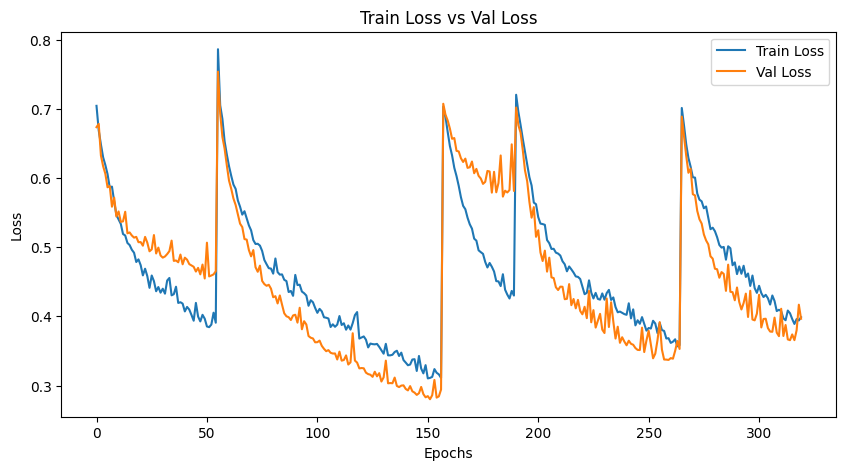

In [21]:
# Graficar Train Loss vs Val Loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train Loss vs Val Loss')
plt.legend()
plt.show()

## NODE_GAM

In [25]:
import numpy as np
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score
import torch
import os
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train_unbalance.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_resampled_df = pd.DataFrame(X_train_unbalance.numpy())
preprocessor.fit(X_train_resampled_df, Y_train_unbalance.numpy())
X_train_resampled_trans = preprocessor.transform(X_train_resampled_df)
X_test_df = pd.DataFrame(X_test_unbalance.numpy())
X_test_trans = preprocessor.transform(X_test_df)

# Definir el espacio de hiperparámetros reducido
param_distributions = {
    'num_trees': [100, 200, 300],
    'num_layers': [2, 3],
    'depth': [3, 4],
    'lr': [1e-4, 1e-3],
    'output_dropout': [0.2, 0.3],
    'last_dropout': [0.3, 0.4],
    'lr_warmup_steps': [200],
    'lr_decay_steps': [500],
    'early_stopping_steps': [500]
}

# Crear un wrapper para el modelo NodeGAMClassifier
class NodeGAMWrapper:
    def __init__(self, **params):
        self.params = params
        self.model = self.create_model(params)

    def create_model(self, params):
        return NodeGAMClassifier(
            in_features=X_train_resampled_df.shape[1],
            cat_features=None,
            arch='GAMAtt',
            batch_size=32,
            device=device,
            objective='error_rate',
            name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
            **params
        )

    def fit(self, X, y):
        print(f"Entrenando con los siguientes parámetros: {self.params}")
        self.model.fit(pd.DataFrame(X), y)
        print("Entrenamiento completado.")
        return self

    def predict(self, X):
        y_pred_prob = torch.sigmoid(torch.tensor(self.model.predict(pd.DataFrame(X)))).numpy()
        return (y_pred_prob > 0.5).astype(int)

    def predict_proba(self, X):
        y_pred_prob = torch.sigmoid(torch.tensor(self.model.predict(pd.DataFrame(X)))).numpy()
        return np.hstack([(1 - y_pred_prob).reshape(-1, 1), y_pred_prob.reshape(-1, 1)])

    def score(self, X, y):
        y_pred = self.predict(X)
        return accuracy_score(y, y_pred)

    def get_params(self, deep=False):
        return self.params

    def set_params(self, **params):
        self.params.update(params)
        self.model = self.create_model(self.params)
        return self

# Implementar RandomizedSearchCV con 5 folds de cross-validation
nodegam_model = NodeGAMWrapper()
scorings = ['f1']

for scoring in scorings:
    random_search = RandomizedSearchCV(
        estimator=nodegam_model,
        param_distributions=param_distributions,
        n_iter=10,  # Número reducido de combinaciones aleatorias a probar
        cv=5,  # Número de folds de cross-validation
        scoring=scoring,
        verbose=2,
        n_jobs=-1
    )                              

    # Entrenar el modelo con búsqueda de hiperparámetros
    random_search.fit(X_train_resampled_trans, Y_train_unbalance.numpy())

    # Mejor combinación de hiperparámetros
    print(f"Best parameters found for {scoring}: {random_search.best_params_}")
    print(f"Best cross-validation {scoring}: {random_search.best_score_}")

    # Guardar el mejor modelo completo
    best_model = random_search.best_estimator_
    model_path = f"D:\\tesis\\Modelo_extraccion_no\\node-gam\\best_nodegam_model_anybalinf_{scoring}.pkl"
    joblib.dump(best_model, model_path)

WARNING! The apex is not installed so fp16 is not available.
Using device: cuda
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Entrenando con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 200, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 4}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\qhoptim\pyt\qhadam.py:133: UserWarning: This overload of add_ is deprecated:
	add_(Number alpha, Tensor other)
Consider using one of the following signatures instead:
	add_(Tensor other, *, Number alpha) (Trig

Steps	Train Err	Val Metric (error_rate)
100	0.5864	0.1515
200	0.4128	0.1515
300	0.4142	0.0909
400	0.3336	0.1061
500	0.1525	0.1061
600	0.0599	0.0909
700	0.0358	0.0758
800	0.1422	0.0909
900	0.0771	0.0606
1000	0.0481	0.0909
1100	0.0297	0.0909
1200	0.0431	0.0909
1300	0.0178	0.0758
1400	0.0323	0.0455
1500	0.047	0.0606
1600	0.0214	0.0606
1700	0.0107	0.0606
1800	0.0492	0.0606
1900	0.0116	0.0606
2000	0.0271	0.0606
2100	0.0191	0.0606
2200	0.0309	0.0606
2300	0.0464	0.0606
2400	0.0059	0.0758
2500	0.0143	0.0758
BREAK. There is no improvment for 500 steps
Total training time: 45.5 seconds
Best step:  1400
Best Val Metric:  0.045454545454545456
Load the best checkpoint.
Entrenamiento completado.
Best parameters found for f1: {'output_dropout': 0.2, 'num_trees': 200, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 4}
Best cross-validation f1: 0.9257423371647511


In [48]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import torch
import os
import joblib
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Definir una ruta para guardar los mejores modelos
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\node_gam\\inferior\\bal\\anybal", "mejor_nodegam_scaler_any_balinf")
os.makedirs(best_model_path, exist_ok=True)

# Unir los conjuntos de entrenamiento y prueba
X_combined = torch.cat((X_train_unbalance, X_test_unbalance), dim=0)
y_combined = torch.cat((Y_train_unbalance, Y_test_unbalance), dim=0)

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_combined.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_combined_df = pd.DataFrame(X_combined.cpu().numpy())
preprocessor.fit(X_combined_df, y_combined.cpu().numpy())
X_combined_trans = preprocessor.transform(X_combined_df)

# Convertir a tensores de PyTorch y mover a la GPU
X_combined_trans = torch.tensor(X_combined_trans, dtype=torch.float32).to(device)

# Definir los mejores hiperparámetros encontrados
best_params = {
    'output_dropout': 0.2,
    'num_trees': 200,
    'num_layers': 2,
    'lr_warmup_steps': 200,
    'lr_decay_steps': 500,
    'lr': 0.001,
    'last_dropout': 0.3,
    'early_stopping_steps': 500,
    'depth': 4
}

# Crear un modelo NodeGAMClassifier con los mejores hiperparámetros
def create_model(params):
    return NodeGAMClassifier(
        in_features=X_combined_df.shape[1],
        cat_features=None,
        arch='GAMAtt',
        batch_size=32,
        device=device,
        objective='error_rate',
        name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
        **params
    )

# Implementar K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
val_losses = []
val_accuracies = []
f1s = []
precisions = []
recalls = []

best_overall_f1 = -1
best_model_fold = None

for fold, (train_index, val_index) in enumerate(kf.split(X_combined_trans)):
    print(f"Fold {fold + 1}")
    X_train_fold, X_val_fold = X_combined_trans[train_index], X_combined_trans[val_index]
    y_train_fold, y_val_fold = y_combined[train_index], y_combined[val_index]

    model = create_model(best_params)
    
    # Entrenamiento
    print(f"Entrenando fold {fold + 1} con los siguientes parámetros: {best_params}")
    model.fit(pd.DataFrame(X_train_fold.cpu().numpy()), y_train_fold.cpu().numpy())
    print("Entrenamiento completado.")
    
    # Validación
    y_val_pred = model.predict(pd.DataFrame(X_val_fold.cpu().numpy()))
    y_val_pred_classes = (torch.sigmoid(torch.tensor(y_val_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas
    val_accuracy = accuracy_score(y_val_fold.cpu().numpy(), y_val_pred_classes)*100
    f1 = f1_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted')*100
    precision = precision_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted')*100
    recall = recall_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted')*100

    val_accuracies.append(val_accuracy)
    f1s.append(f1)
    precisions.append(precision)
    recalls.append(recall)

    # Guardar el mejor modelo basado en F1-score
    if f1 > best_overall_f1:
        best_overall_f1 = f1
        best_model_fold = fold + 1

    print(f"Fold {fold + 1} val accuracy: {val_accuracy}, F1-score: {f1}")

# Guardar el mejor modelo basado en F1-score
if best_model_fold is not None:
    model_path = os.path.join(best_model_path, f"best_model_fold_{best_model_fold}.pth")
    model = create_model(best_params)
    model.fit(pd.DataFrame(X_combined_trans.cpu().numpy()), y_combined.cpu().numpy())
    joblib.dump(model, model_path)
    print(f"Mejor modelo guardado en: {model_path}")

Using device: cuda
Fold 1
Entrenando fold 1 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 200, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 4}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (428). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.5642	0.1846
200	0.3164	0.1538
300	0.3455	0.1385
400	0.4428	0.1385
500	0.0806	0.1077
600	0.0016	0.1077
700	0.045	0.1231
800	0.06	0.1077
900	0.031	0.0923
1000	0.0412	0.0923
1100	0.0157	0.1077
1200	0.0045	0.1077
1300	0.0206	0.1231
1400	0.0075	0.1077
1500	0.0009	0.1077
1600	0.0209	0.0923
1700	0.0321	0.0769
1800	0.0221	0.0769
1900	0.0249	0.0769
2000	0.0111	0.0769
2100	0.0209	0.0923
2200	0.0046	0.0769
2300	0.0233	0.0769
2400	0.0097	0.0769
2500	0.02	0.0769
BREAK. There is no improvment for 500 steps
Total training time: 48.6 seconds
Best step:  1700
Best Val Metric:  0.07692307692307693
Load the best checkpoint.
Entrenamiento completado.
Fold 1 val accuracy: 90.74074074074075, F1-score: 90.68879538725261
Fold 2
Entrenando fold 2 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 200, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 4}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (429). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.5569	0.2462
200	0.3842	0.2154
300	0.2497	0.1692
400	0.0771	0.1385
500	0.1798	0.1231
600	0.1093	0.1077
700	0.0751	0.1077
800	0.0586	0.1231
900	0.1053	0.1231
1000	0.0614	0.1077
1100	0.09	0.1231
1200	0.0043	0.0769
1300	0.02	0.0769
1400	0.025	0.0923
1500	0.0964	0.0769
1600	0.0276	0.0769
1700	0.0367	0.0769
1800	0.0409	0.0923
1900	0.0211	0.0923
2000	0.0073	0.1077
2100	0.0099	0.0923
2200	0.025	0.1231
2300	0.0296	0.1385
2400	0.0143	0.1385
2500	0.0276	0.1385
BREAK. There is no improvment for 500 steps
Total training time: 47.7 seconds
Best step:  1200
Best Val Metric:  0.07692307692307693
Load the best checkpoint.
Entrenamiento completado.
Fold 2 val accuracy: 93.45794392523365, F1-score: 93.46488816874512
Fold 3
Entrenando fold 3 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 200, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 4}


...

Steps	Train Err	Val Metric (error_rate)
100	0.5861	0.2
200	0.5735	0.0923
300	0.1585	0.0615
400	0.2338	0.0462
500	0.2221	0.0462
600	0.5227	0.0462
700	0.0449	0.0462
800	0.0553	0.0462
900	0.0554	0.0615
1000	0.0894	0.0615
1100	0.0353	0.0769
1200	0.0365	0.0615
1300	0.0899	0.0615
1400	0.0342	0.0308
1500	0.0344	0.0308
1600	0.0549	0.0308
1700	0.029	0.0308
1800	0.0308	0.0615
1900	0.0714	0.0308
2000	0.0177	0.0154
2100	0.0042	0.0154
2200	0.0252	0.0154
2300	0.0482	0.0154
2400	0.0193	0.0462
2500	0.0604	0.0462
BREAK. There is no improvment for 500 steps
Total training time: 46.6 seconds
Best step:  2000
Best Val Metric:  0.015384615384615385
Load the best checkpoint.
Entrenamiento completado.
Fold 4 val accuracy: 92.5233644859813, F1-score: 92.52728579831383
Fold 5
Entrenando fold 5 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 200, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 4}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (429). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6235	0.2154
200	0.3826	0.1077
300	0.198	0.0923
400	0.1903	0.0769
500	0.1344	0.0769
600	0.1187	0.0462
700	0.1177	0.0462
800	0.0737	0.0308
900	0.0797	0.0615
1000	0.0537	0.0615
1100	0.1063	0.0615
1200	0.0215	0.0615
1300	0.0678	0.0462
1400	0.0169	0.0462
1500	0.0464	0.0462
1600	0.0391	0.0462
1700	0.0295	0.0615
1800	0.0453	0.0615
1900	0.0937	0.0615
2000	0.0104	0.0615
2100	0.0019	0.0615
2200	0.1733	0.0615
2300	0.0048	0.0615
2400	0.0559	0.0615
2500	0.001	0.0462
BREAK. There is no improvment for 500 steps
Total training time: 46.5 seconds
Best step:  800
Best Val Metric:  0.03076923076923077
Load the best checkpoint.
Entrenamiento completado.
Fold 5 val accuracy: 93.45794392523365, F1-score: 93.45450465979523


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (536). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6326	0.2346
200	0.3998	0.1728
300	0.2826	0.1481
400	0.1663	0.1235
500	0.1417	0.1111
600	0.0287	0.1235
700	0.2878	0.0988
800	0.1018	0.0864
900	0.1021	0.0741
1000	0.0346	0.0741
1100	0.051	0.0617
1200	0.0056	0.0864
1300	0.0652	0.0741
1400	0.0573	0.0864
1500	0.0124	0.0617
1600	0.0588	0.0741
1700	0.1485	0.0617
1800	0.0102	0.0864
1900	0.0329	0.0741
2000	0.0191	0.0617
2100	0.0371	0.0617
2200	0.0746	0.0617
2300	0.0553	0.0494
2400	0.0412	0.0741
2500	0.0604	0.0741
2600	0.0159	0.0741
2700	0.0	0.0741
2800	0.0527	0.0741
BREAK. There is no improvment for 500 steps
Total training time: 50.6 seconds
Best step:  2300
Best Val Metric:  0.04938271604938271
Load the best checkpoint.
Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\node_gam\inferior\bal\anybal\mejor_nodegam_scaler_any_balinf\best_model_fold_2.pth


In [49]:
# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

accuracy_mean_std = format_metric(np.mean(val_accuracies), np.std(val_accuracies))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nPrecisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')


Precisión: 92.17 ± 1.25%
F1-score: 92.16 ± 1.26%
Precisión (Precision): 92.22 ± 1.23%
Recall: 92.17 ± 1.25%


# Balanced PCA

In [52]:
from sklearn import decomposition

pca = decomposition.PCA(n_components=0.96,svd_solver='full',tol=1e-4)
pca.fit(X_train_resampled_s)
X_train_pca= pca.transform(X_train_resampled_s)
X_test_pca=pca.transform(X_test)

In [53]:
X_train_unbalance= torch.tensor(X_train_pca, dtype=torch.float32)
Y_train_unbalance= torch.tensor(y_train_resampled_s.values, dtype=torch.float32)
X_test_unbalance= torch.tensor(X_test_pca, dtype=torch.float32)
Y_test_unbalance= torch.tensor(y_test.values, dtype=torch.float32)


## KAN

In [54]:
input_dim = X_train_unbalance.shape[1]
hidden_layers = [128, 64, 32, 16] # Reducción en el número de capas
output_dim = 1

   
def create_model():
    model = KAN([input_dim] + hidden_layers + [output_dim])
    return model

In [55]:
# Configuración inicial
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Concatenar los conjuntos de entrenamiento y prueba
X = torch.cat((X_train_unbalance, X_test_unbalance), dim=0)
y = torch.cat((Y_train_unbalance, Y_test_unbalance), dim=0)

train_losses = []
val_losses = []
train_accuracies = []  # Lista para accuracies de entrenamiento
val_accuracies = []  # Lista para accuracies de validación
precisions = []
recalls = []
f1s = []
accuracys=[]

pos_weight = torch.tensor([len(y[y == 0]) / len(y[y == 1])]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
num_epochs = 200
batch_size = 32
patience = 5  # Paciencia para EarlyStopping

best_overall_f1 = -1
best_model_path = None

# Realizar la validación cruzada
for fold, (train_index, test_index) in enumerate(kf.split(X)):
    print(f'Fold {fold+1}')

    X_train_fold, X_val_fold = X[train_index], X[test_index]
    y_train_fold, y_val_fold = y[train_index], y[test_index]

    model = create_model().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

    train_dataset = TensorDataset(X_train_fold, y_train_fold)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, generator=torch.Generator().manual_seed(42))

    val_dataset = TensorDataset(X_val_fold, y_val_fold)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, generator=torch.Generator().manual_seed(42))

    best_val_loss = float('inf')  # Inicializar la mejor pérdida de validación
    epochs_no_improve = 0  # Contador de épocas sin mejora

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0
        epoch_train_accuracy = 0  # Acumulador para accuracy de entrenamiento
        with tqdm(train_loader) as pbar:
            for inputs, labels in pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                epoch_train_loss += loss.item()
                accuracy = ((outputs > 0.5) == labels).float().mean()
                epoch_train_accuracy += accuracy.item()
                pbar.set_postfix(loss=loss.item(), accuracy=accuracy.item(), lr=optimizer.param_groups[0]['lr'])

        # Guardar accuracy promedio de entrenamiento por época
        train_losses.append(epoch_train_loss / len(train_loader))
        train_accuracies.append(epoch_train_accuracy / len(train_loader))

        model.eval()
        val_loss = 0
        val_accuracy = 0
        all_labels = []
        all_outputs = []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze()
                val_loss += criterion(outputs, labels).item()
                val_accuracy += ((outputs > 0.5) == labels).float().mean().item()
                all_labels.extend(labels.cpu().numpy())
                all_outputs.extend(torch.sigmoid(outputs).cpu().numpy())

        val_loss /= len(val_loader)
        val_accuracy /= len(val_loader)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        # Calcular las métricas
        y_pred_classes = np.array(all_outputs) > 0.5
        accuracy = accuracy_score(all_labels, y_pred_classes) * 100  # Convertir a porcentaje
        f1 = f1_score(all_labels, y_pred_classes, average='weighted') * 100  # Convertir a porcentaje
        precision = precision_score(all_labels, y_pred_classes, average='weighted') * 100  # Convertir a porcentaje
        recall = recall_score(all_labels, y_pred_classes, average='weighted') * 100  # Convertir a porcentaje

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        accuracys.append(accuracy)
        # Guardar el mejor modelo basado en la pérdida de validación
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), os.path.join("D:\\tesis\\Modelo_extraccion_no\\extrac inf\\pca_bal\\", f'efficientKan_balpcainf_fold_{fold+1}.pth'))
        else:
            epochs_no_improve += 1

        scheduler.step(val_loss)
        print(f"Epoch {epoch + 1}, Train Loss: {epoch_train_loss / len(train_loader)}, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}")

        # Implementar EarlyStopping
        if epochs_no_improve == patience:
            print(f'Early stopping triggered after {epoch+1} epochs.')
            break

    # Guardar el mejor modelo basado en F1-score
    if f1 > best_overall_f1:
        best_overall_f1 = f1
        best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\extrac inf\\pca_bal\\", f'efficientKan_balpcainf_fold_{fold+1}.pth')

# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

accuracy_mean_std = format_metric(np.mean(accuracys), np.std(accuracys))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nPrecisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

print(f"\nBest model saved at: {best_model_path}")

Fold 1


100%|██████████| 14/14 [00:00<00:00, 47.68it/s, accuracy=0.333, loss=0.712, lr=0.0001]


Epoch 1, Train Loss: 0.7050768775599343, Val Loss: 0.7103526890277863, Val Accuracy: 0.4401041716337204


100%|██████████| 14/14 [00:00<00:00, 46.77it/s, accuracy=0.583, loss=0.691, lr=0.0001]


Epoch 2, Train Loss: 0.6962734801428658, Val Loss: 0.7000684440135956, Val Accuracy: 0.4401041716337204


...

Epoch 51, Train Loss: 0.35971325635910034, Val Loss: 0.4557492211461067, Val Accuracy: 0.8139204680919647


100%|██████████| 14/14 [00:00<00:00, 50.07it/s, accuracy=0.692, loss=0.39, lr=0.0001] 


Epoch 52, Train Loss: 0.3618405205862863, Val Loss: 0.45500850677490234, Val Accuracy: 0.8139204680919647


100%|██████████| 14/14 [00:00<00:00, 47.53it/s, accuracy=0.769, loss=0.344, lr=0.0001]

Epoch 53, Train Loss: 0.3575190795319421, Val Loss: 0.457375206053257, Val Accuracy: 0.8217329680919647
Early stopping triggered after 53 epochs.

Precisión: 77.97 ± 5.33%
F1-score: 77.77 ± 5.56%
Precisión (Precision): 78.62 ± 4.77%
Recall: 77.97 ± 5.33%

Best model saved at: D:\tesis\Modelo_extraccion_no\extrac inf\pca_bal\efficientKan_balpcainf_fold_4.pth


In [56]:
# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

accuracy_mean_std = format_metric(np.mean(val_accuracies), np.std(val_accuracies))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nPrecisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

print(f"\nBest model saved at: {best_model_path}")


Precisión: 0.73 ± 0.09%
F1-score: 77.77 ± 5.56%
Precisión (Precision): 78.62 ± 4.77%
Recall: 77.97 ± 5.33%

Best model saved at: D:\tesis\Modelo_extraccion_no\extrac inf\pca_bal\efficientKan_balpcainf_fold_4.pth


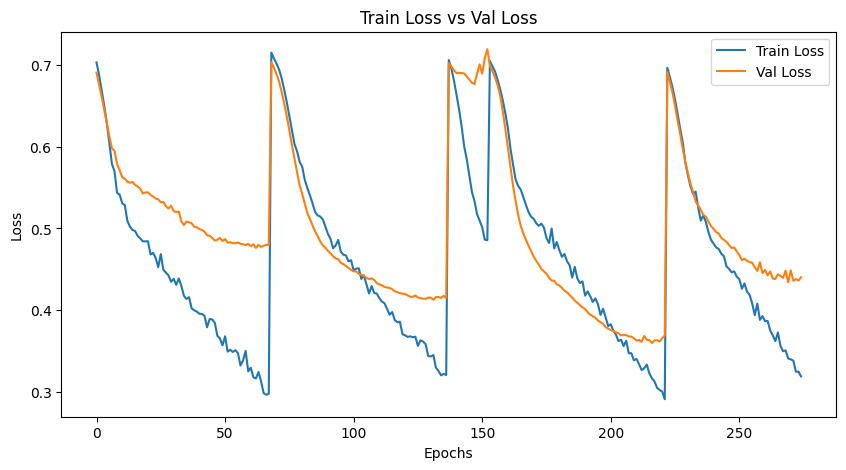

In [10]:
# Graficar Train Loss vs Val Loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train Loss vs Val Loss')
plt.legend()
plt.show()

## NODE_GAM

In [11]:
import numpy as np
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score
import torch
import os
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train_unbalance.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_resampled_df = pd.DataFrame(X_train_unbalance.numpy())
preprocessor.fit(X_train_resampled_df, Y_train_unbalance.numpy())
X_train_resampled_trans = preprocessor.transform(X_train_resampled_df)
X_test_df = pd.DataFrame(X_test_unbalance.numpy())
X_test_trans = preprocessor.transform(X_test_df)

# Definir el espacio de hiperparámetros reducido
param_distributions = {
    'num_trees': [100, 200, 300],
    'num_layers': [2, 3],
    'depth': [3, 4],
    'lr': [1e-4, 1e-3],
    'output_dropout': [0.2, 0.3],
    'last_dropout': [0.3, 0.4],
    'lr_warmup_steps': [200],
    'lr_decay_steps': [500],
    'early_stopping_steps': [500]
}

# Crear un wrapper para el modelo NodeGAMClassifier
class NodeGAMWrapper:
    def __init__(self, **params):
        self.params = params
        self.model = self.create_model(params)

    def create_model(self, params):
        return NodeGAMClassifier(
            in_features=X_train_resampled_df.shape[1],
            cat_features=None,
            arch='GAMAtt',
            batch_size=32,
            device=device,
            objective='error_rate',
            name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
            **params
        )

    def fit(self, X, y):
        print(f"Entrenando con los siguientes parámetros: {self.params}")
        self.model.fit(pd.DataFrame(X), y)
        print("Entrenamiento completado.")
        return self

    def predict(self, X):
        y_pred_prob = torch.sigmoid(torch.tensor(self.model.predict(pd.DataFrame(X)))).numpy()
        return (y_pred_prob > 0.5).astype(int)

    def predict_proba(self, X):
        y_pred_prob = torch.sigmoid(torch.tensor(self.model.predict(pd.DataFrame(X)))).numpy()
        return np.hstack([(1 - y_pred_prob).reshape(-1, 1), y_pred_prob.reshape(-1, 1)])

    def score(self, X, y):
        y_pred = self.predict(X)
        return accuracy_score(y, y_pred)

    def get_params(self, deep=False):
        return self.params

    def set_params(self, **params):
        self.params.update(params)
        self.model = self.create_model(self.params)
        return self

# Implementar RandomizedSearchCV con 5 folds de cross-validation
nodegam_model = NodeGAMWrapper()
scorings = ['f1']

for scoring in scorings:
    random_search = RandomizedSearchCV(
        estimator=nodegam_model,
        param_distributions=param_distributions,
        n_iter=10,  # Número reducido de combinaciones aleatorias a probar
        cv=5,  # Número de folds de cross-validation
        scoring=scoring,
        verbose=2,
        n_jobs=-1
    )                              

    # Entrenar el modelo con búsqueda de hiperparámetros
    random_search.fit(X_train_resampled_trans, Y_train_unbalance.numpy())

    # Mejor combinación de hiperparámetros
    print(f"Best parameters found for {scoring}: {random_search.best_params_}")
    print(f"Best cross-validation {scoring}: {random_search.best_score_}")

    # Guardar el mejor modelo completo
    best_model = random_search.best_estimator_
    model_path = f"D:\\tesis\\Modelo_extraccion_no\\node-gam\\best_nodegam_model_pcabalinf_{scoring}.pkl"
    joblib.dump(best_model, model_path)

WARNING! The apex is not installed so fp16 is not available.
Using device: cuda
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Entrenando con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 3}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\qhoptim\pyt\qhadam.py:133: UserWarning: This overload of add_ is deprecated:
	add_(Number alpha, Tensor other)
Consider using one of the following signatures instead:
	add_(Tensor other, *, Number alpha) (Trig

Steps	Train Err	Val Metric (error_rate)
100	0.7421	0.6667
200	0.6388	0.6364
300	0.6272	0.6061
400	0.5547	0.5
500	0.4723	0.4242
600	0.5362	0.3182
700	0.3476	0.2273
800	0.6077	0.197
900	0.5818	0.1667
1000	0.5238	0.1061
1100	0.28	0.1061
1200	0.3005	0.0909
1300	0.369	0.0909
1400	0.2619	0.0909
1500	0.3552	0.0909
1600	0.3928	0.0909
1700	0.3636	0.1061
1800	0.2071	0.1061
1900	0.2433	0.1061
2000	0.2903	0.1061
2100	0.6327	0.1061
2200	0.3572	0.1061
2300	0.3034	0.1061
2400	0.2094	0.1061
2500	0.4246	0.1061
BREAK. There is no improvment for 500 steps
Total training time: 71.2 seconds
Best step:  1200
Best Val Metric:  0.09090909090909091
Load the best checkpoint.
Entrenamiento completado.
Best parameters found for f1: {'output_dropout': 0.3, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 3}
Best cross-validation f1: 0.8419415311344176


In [57]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import torch
import os
import joblib
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Definir una ruta para guardar los mejores modelos
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\node_gam\\inferior\\bal\\PCA_BAL", "mejor_nodegam_scaler_PCA_BALinf")
os.makedirs(best_model_path, exist_ok=True)

# Unir los conjuntos de entrenamiento y prueba
X_combined = torch.cat((X_train_unbalance, X_test_unbalance), dim=0)
y_combined = torch.cat((Y_train_unbalance, Y_test_unbalance), dim=0)

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_combined.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_combined_df = pd.DataFrame(X_combined.cpu().numpy())
preprocessor.fit(X_combined_df, y_combined.cpu().numpy())
X_combined_trans = preprocessor.transform(X_combined_df)

# Convertir a tensores de PyTorch y mover a la GPU
X_combined_trans = torch.tensor(X_combined_trans, dtype=torch.float32).to(device)

# Definir los mejores hiperparámetros encontrados
best_params = {
    'output_dropout': 0.3,
    'num_trees': 200,
    'num_layers': 3,
    'lr_warmup_steps': 200,
    'lr_decay_steps': 500,
    'lr': 0.0001,
    'last_dropout': 0.3,
    'early_stopping_steps': 500,
    'depth': 3
}


# Crear un modelo NodeGAMClassifier con los mejores hiperparámetros
def create_model(params):
    return NodeGAMClassifier(
        in_features=X_combined_df.shape[1],
        cat_features=None,
        arch='GAMAtt',
        batch_size=32,
        device=device,
        objective='error_rate',
        name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
        **params
    )

# Implementar K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
val_losses = []
val_accuracies = []
f1s = []
precisions = []
recalls = []

best_overall_f1 = -1
best_model_fold = None

for fold, (train_index, val_index) in enumerate(kf.split(X_combined_trans)):
    print(f"Fold {fold + 1}")
    X_train_fold, X_val_fold = X_combined_trans[train_index], X_combined_trans[val_index]
    y_train_fold, y_val_fold = y_combined[train_index], y_combined[val_index]

    model = create_model(best_params)
    
    # Entrenamiento
    print(f"Entrenando fold {fold + 1} con los siguientes parámetros: {best_params}")
    model.fit(pd.DataFrame(X_train_fold.cpu().numpy()), y_train_fold.cpu().numpy())
    print("Entrenamiento completado.")
    
    # Validación
    y_val_pred = model.predict(pd.DataFrame(X_val_fold.cpu().numpy()))
    y_val_pred_classes = (torch.sigmoid(torch.tensor(y_val_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas
    val_accuracy = accuracy_score(y_val_fold.cpu().numpy(), y_val_pred_classes)*100
    f1 = f1_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted')*100
    precision = precision_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted')*100
    recall = recall_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted')*100

    val_accuracies.append(val_accuracy)
    f1s.append(f1)
    precisions.append(precision)
    recalls.append(recall)

    # Guardar el mejor modelo basado en F1-score
    if f1 > best_overall_f1:
        best_overall_f1 = f1
        best_model_fold = fold + 1

    print(f"Fold {fold + 1} val accuracy: {val_accuracy}, F1-score: {f1}")

# Guardar el mejor modelo basado en F1-score
if best_model_fold is not None:
    model_path = os.path.join(best_model_path, f"best_model_fold_{best_model_fold}.pth")
    model = create_model(best_params)
    model.fit(pd.DataFrame(X_combined_trans.cpu().numpy()), y_combined.cpu().numpy())
    joblib.dump(model, model_path)
    print(f"Mejor modelo guardado en: {model_path}")

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (428). n_quantiles is set to n_samples.
  warnings.warn(


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Using device: cuda
Fold 1
Entrenando fold 1 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 3}
Steps	Train Err	Val Metric (error_rate)
100	0.7731	0.3692
200	0.7764	0.3077
300	0.6151	0.2462
400	0.593	0.2308
500	0.6477	0.1692
600	0.5427	0.1692
700	0.6209	0.1385
800	0.4574	0.1231
900	0.3828	0.1077
1000	0.3047	0.1077
1100	0.408	0.1231
1200	0.4578	0.1231
1300	0.6383	0.1077
1400	0.2784	0.1231
1500	0.4618	0.1231
1600	0.4259	0.1231
1700	0.3437	0.1231
1800	0.4905	0.1231
1900	0.3402	0.1231
2000	0.3828	0.1231
2100	0.2166	0.1231
2200	0.3286	0.1231
2300	0.44	0.1385
2400	0.1838	0.1385
2500	0.2911	0.1385
BREAK. There is no improvment for 500 steps
Total training time: 72.7 seconds
Best step:  900
Best Val Metric:  0.1076923076923077
Load the best checkpoint.
Entrenamiento completado.
Fold 1 val accuracy: 84.25925925925925, F1-score: 84.19733

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (429). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.7664	0.4769
200	0.7255	0.4615
300	0.5939	0.4
400	0.5793	0.3538
500	0.6579	0.2615
600	0.4276	0.2308
700	0.4598	0.2154
800	0.3736	0.1846
900	0.3368	0.1846
1000	0.3627	0.1846
1100	0.3456	0.1846
1200	0.172	0.1538
1300	0.4406	0.1538
1400	0.3282	0.1846
1500	0.2414	0.1846
1600	0.3128	0.1846
1700	0.336	0.1692
1800	0.4174	0.1692
1900	0.3432	0.1692
2000	0.178	0.1538
2100	0.3016	0.1538
2200	0.4193	0.1692
2300	0.3557	0.1538
2400	0.3581	0.1538
2500	0.2113	0.1538
BREAK. There is no improvment for 500 steps
Total training time: 72.9 seconds
Best step:  1200
Best Val Metric:  0.15384615384615385
Load the best checkpoint.
Entrenamiento completado.
Fold 2 val accuracy: 89.7196261682243, F1-score: 89.74680135678305
Fold 3
Entrenando fold 3 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 3}


...

Steps	Train Err	Val Metric (error_rate)
100	0.7053	0.4308
200	0.7051	0.4308
300	0.6524	0.3692
400	0.5218	0.4
500	0.4963	0.2769
600	0.449	0.1692
700	0.5858	0.1385
800	0.5061	0.1538
900	0.4222	0.1385
1000	0.3695	0.1385
1100	0.3756	0.1385
1200	0.399	0.1231
1300	0.2845	0.1231
1400	0.2629	0.1538
1500	0.4279	0.1538
1600	0.3289	0.1538
1700	0.6057	0.1538
1800	0.2547	0.1692
1900	0.3849	0.1692
2000	0.2063	0.1692
2100	0.3449	0.1692
2200	0.5162	0.1692
2300	0.4127	0.1692
2400	0.7527	0.1692
2500	0.4741	0.1692
BREAK. There is no improvment for 500 steps
Total training time: 75.8 seconds
Best step:  1200
Best Val Metric:  0.12307692307692308
Load the best checkpoint.
Entrenamiento completado.
Fold 4 val accuracy: 92.5233644859813, F1-score: 92.52728579831383
Fold 5
Entrenando fold 5 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 3}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (429). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.7242	0.6308
200	0.8855	0.5846
300	0.7399	0.5385
400	0.6045	0.4615
500	0.5623	0.4462
600	0.4091	0.2
700	0.4809	0.1538
800	0.5274	0.1692
900	0.3071	0.1385
1000	0.4615	0.1385
1100	0.2638	0.1538
1200	0.2949	0.1538
1300	0.3317	0.1538
1400	0.6168	0.1538
1500	0.4374	0.1538
1600	0.2315	0.1692
1700	0.4633	0.1692
1800	0.2494	0.1692
1900	0.3006	0.1692
2000	0.2193	0.1692
2100	0.4449	0.1692
2200	0.2833	0.1692
2300	0.2845	0.1692
2400	0.1498	0.1692
2500	0.45	0.1692
BREAK. There is no improvment for 500 steps
Total training time: 75.0 seconds
Best step:  900
Best Val Metric:  0.13846153846153847
Load the best checkpoint.
Entrenamiento completado.
Fold 5 val accuracy: 85.98130841121495, F1-score: 85.90024001159523


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (536). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.711	0.5062
200	0.7274	0.3704
300	0.7761	0.321
400	0.5923	0.2469
500	0.5148	0.2469
600	0.7367	0.2469
700	0.391	0.2716
800	0.3767	0.2469
900	0.5083	0.2099
1000	0.3272	0.2346
1100	0.4777	0.2222
1200	0.4411	0.2222
1300	0.5207	0.1975
1400	0.4527	0.2099
1500	0.1205	0.2099
1600	0.3666	0.2099
1700	0.2691	0.2099
1800	0.4959	0.2099
1900	0.319	0.2099
2000	0.1918	0.2099
2100	0.2461	0.2099
2200	0.2079	0.2099
2300	0.2941	0.2099
2400	1.3206	0.2099
2500	0.2437	0.2099
BREAK. There is no improvment for 500 steps
Total training time: 72.4 seconds
Best step:  1300
Best Val Metric:  0.19753086419753085
Load the best checkpoint.
Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\node_gam\inferior\bal\PCA_BAL\mejor_nodegam_scaler_PCA_BALinf\best_model_fold_4.pth


In [58]:
# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

accuracy_mean_std = format_metric(np.mean(val_accuracies), np.std(val_accuracies))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nPrecisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')


Precisión: 86.76 ± 3.96%
F1-score: 86.75 ± 3.97%
Precisión (Precision): 87.22 ± 3.91%
Recall: 86.76 ± 3.96%


# Balanced scaler

In [71]:
scaler = StandardScaler().fit(X_train)

X_train_scaler = scaler.transform(X_train_resampled_s)
X_test_scaler = scaler.transform(X_test)

In [72]:
X_train_unbalance= torch.tensor(X_train_scaler, dtype=torch.float32)
Y_train_unbalance= torch.tensor(y_train_resampled_s.values, dtype=torch.float32)
X_test_unbalance= torch.tensor(X_test_scaler, dtype=torch.float32)
Y_test_unbalance= torch.tensor(y_test.values, dtype=torch.float32)

## KAN

In [18]:
input_dim = X_train_unbalance.shape[1]
hidden_layers = [128, 64, 32, 16] # Reducción en el número de capas
output_dim = 1

   
def create_model():
    model = KAN([input_dim] + hidden_layers + [output_dim])
    return model

In [19]:
# Configuración inicial
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Concatenar los conjuntos de entrenamiento y prueba
X = torch.cat((X_train_unbalance, X_test_unbalance), dim=0)
y = torch.cat((Y_train_unbalance, Y_test_unbalance), dim=0)

train_losses = []
val_losses = []
train_accuracies = []  # Lista para accuracies de entrenamiento
val_accuracies = []  # Lista para accuracies de validación
precisions = []
recalls = []
f1s = []

pos_weight = torch.tensor([len(y[y == 0]) / len(y[y == 1])]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
num_epochs = 200
batch_size = 32
patience = 5  # Paciencia para EarlyStopping

best_overall_f1 = -1
best_model_path = None

# Realizar la validación cruzada
for fold, (train_index, test_index) in enumerate(kf.split(X)):
    print(f'Fold {fold+1}')

    X_train_fold, X_val_fold = X[train_index], X[test_index]
    y_train_fold, y_val_fold = y[train_index], y[test_index]

    model = create_model().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

    train_dataset = TensorDataset(X_train_fold, y_train_fold)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, generator=torch.Generator().manual_seed(42))

    val_dataset = TensorDataset(X_val_fold, y_val_fold)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, generator=torch.Generator().manual_seed(42))

    best_val_loss = float('inf')  # Inicializar la mejor pérdida de validación
    epochs_no_improve = 0  # Contador de épocas sin mejora

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0
        epoch_train_accuracy = 0  # Acumulador para accuracy de entrenamiento
        with tqdm(train_loader) as pbar:
            for inputs, labels in pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                epoch_train_loss += loss.item()
                accuracy = ((outputs > 0.5) == labels).float().mean()
                epoch_train_accuracy += accuracy.item()
                pbar.set_postfix(loss=loss.item(), accuracy=accuracy.item(), lr=optimizer.param_groups[0]['lr'])

        # Guardar accuracy promedio de entrenamiento por época
        train_losses.append(epoch_train_loss / len(train_loader))
        train_accuracies.append(epoch_train_accuracy / len(train_loader))

        model.eval()
        val_loss = 0
        val_accuracy = 0
        all_labels = []
        all_outputs = []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze()
                val_loss += criterion(outputs, labels).item()
                val_accuracy += ((outputs > 0.5) == labels).float().mean().item()
                all_labels.extend(labels.cpu().numpy())
                all_outputs.extend(torch.sigmoid(outputs).cpu().numpy())

        val_loss /= len(val_loader)
        val_accuracy /= len(val_loader)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        # Calcular las métricas
        y_pred_classes = np.array(all_outputs) > 0.5
        accuracy = accuracy_score(all_labels, y_pred_classes) * 100  # Convertir a porcentaje
        f1 = f1_score(all_labels, y_pred_classes, average='weighted') * 100  # Convertir a porcentaje
        precision = precision_score(all_labels, y_pred_classes, average='weighted') * 100  # Convertir a porcentaje
        recall = recall_score(all_labels, y_pred_classes, average='weighted') * 100  # Convertir a porcentaje

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)

        # Guardar el mejor modelo basado en la pérdida de validación
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), os.path.join("D:\\tesis\\Modelo_extraccion_no\\extrac inf\\scale_bal\\", f'efficientKan_scale_balinf_fold_{fold+1}.pth'))
        else:
            epochs_no_improve += 1

        scheduler.step(val_loss)
        print(f"Epoch {epoch + 1}, Train Loss: {epoch_train_loss / len(train_loader)}, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}")

        # Implementar EarlyStopping
        if epochs_no_improve == patience:
            print(f'Early stopping triggered after {epoch+1} epochs.')
            break

    # Guardar el mejor modelo basado en F1-score
    if f1 > best_overall_f1:
        best_overall_f1 = f1
        best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\extrac inf\\scale_bal\\", f'efficientKan_scale_balinf_fold_{fold+1}.pth')



Fold 1


100%|██████████| 14/14 [00:00<00:00, 45.82it/s, accuracy=0.333, loss=0.714, lr=0.0001]


Epoch 1, Train Loss: 0.7078827321529388, Val Loss: 0.7102459669113159, Val Accuracy: 0.4401041716337204


100%|██████████| 14/14 [00:00<00:00, 49.86it/s, accuracy=0.583, loss=0.704, lr=0.0001]


Epoch 2, Train Loss: 0.7065751552581787, Val Loss: 0.7092088758945465, Val Accuracy: 0.4401041716337204


...

Epoch 63, Train Loss: 0.12583093970481837, Val Loss: 0.20571782812476158, Val Accuracy: 0.9303977340459824


100%|██████████| 14/14 [00:00<00:00, 48.54it/s, accuracy=1, loss=0.0267, lr=0.0001]   


Epoch 64, Train Loss: 0.12058576209736722, Val Loss: 0.2052796259522438, Val Accuracy: 0.9303977340459824


100%|██████████| 14/14 [00:00<00:00, 49.98it/s, accuracy=0.923, loss=0.214, lr=0.0001]

Epoch 65, Train Loss: 0.12580336417470658, Val Loss: 0.20421966165304184, Val Accuracy: 0.9303977340459824
Early stopping triggered after 65 epochs.


In [20]:
# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

accuracy_mean_std = format_metric(np.mean(val_accuracies), np.std(val_accuracies))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nPrecisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

print(f"\nBest model saved at: {best_model_path}")


Precisión: 0.82 ± 0.13%
F1-score: 85.79 ± 7.93%
Precisión (Precision): 86.83 ± 5.68%
Recall: 85.97 ± 7.30%

Best model saved at: D:\tesis\Modelo_extraccion_no\extrac inf\scale_bal\efficientKan_scale_balinf_fold_2.pth


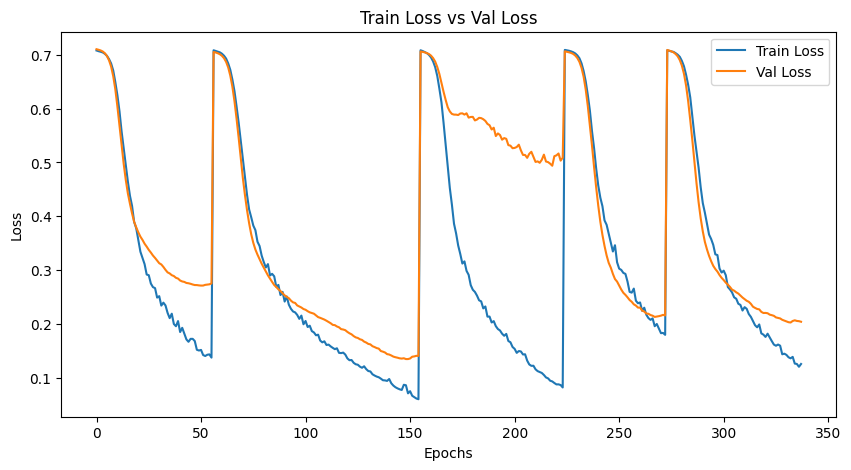

In [21]:
# Graficar Train Loss vs Val Loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train Loss vs Val Loss')
plt.legend()
plt.show()

## NODE_GAM

In [22]:
import numpy as np
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score
import torch
import os
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train_unbalance.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_resampled_df = pd.DataFrame(X_train_unbalance.numpy())
preprocessor.fit(X_train_resampled_df, Y_train_unbalance.numpy())
X_train_resampled_trans = preprocessor.transform(X_train_resampled_df)
X_test_df = pd.DataFrame(X_test_unbalance.numpy())
X_test_trans = preprocessor.transform(X_test_df)

# Definir el espacio de hiperparámetros reducido
param_distributions = {
    'num_trees': [100, 200, 300],
    'num_layers': [2, 3],
    'depth': [3, 4],
    'lr': [1e-4, 1e-3],
    'output_dropout': [0.2, 0.3],
    'last_dropout': [0.3, 0.4],
    'lr_warmup_steps': [200],
    'lr_decay_steps': [500],
    'early_stopping_steps': [500]
}

# Crear un wrapper para el modelo NodeGAMClassifier
class NodeGAMWrapper:
    def __init__(self, **params):
        self.params = params
        self.model = self.create_model(params)

    def create_model(self, params):
        return NodeGAMClassifier(
            in_features=X_train_resampled_df.shape[1],
            cat_features=None,
            arch='GAMAtt',
            batch_size=32,
            device=device,
            objective='error_rate',
            name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
            **params
        )

    def fit(self, X, y):
        print(f"Entrenando con los siguientes parámetros: {self.params}")
        self.model.fit(pd.DataFrame(X), y)
        print("Entrenamiento completado.")
        return self

    def predict(self, X):
        y_pred_prob = torch.sigmoid(torch.tensor(self.model.predict(pd.DataFrame(X)))).numpy()
        return (y_pred_prob > 0.5).astype(int)

    def predict_proba(self, X):
        y_pred_prob = torch.sigmoid(torch.tensor(self.model.predict(pd.DataFrame(X)))).numpy()
        return np.hstack([(1 - y_pred_prob).reshape(-1, 1), y_pred_prob.reshape(-1, 1)])

    def score(self, X, y):
        y_pred = self.predict(X)
        return accuracy_score(y, y_pred)

    def get_params(self, deep=False):
        return self.params

    def set_params(self, **params):
        self.params.update(params)
        self.model = self.create_model(self.params)
        return self

# Implementar RandomizedSearchCV con 5 folds de cross-validation
nodegam_model = NodeGAMWrapper()
scorings = ['f1']

for scoring in scorings:
    random_search = RandomizedSearchCV(
        estimator=nodegam_model,
        param_distributions=param_distributions,
        n_iter=10,  # Número reducido de combinaciones aleatorias a probar
        cv=5,  # Número de folds de cross-validation
        scoring=scoring,
        verbose=2,
        n_jobs=-1
    )                              

    # Entrenar el modelo con búsqueda de hiperparámetros
    random_search.fit(X_train_resampled_trans, Y_train_unbalance.numpy())

    # Mejor combinación de hiperparámetros
    print(f"Best parameters found for {scoring}: {random_search.best_params_}")
    print(f"Best cross-validation {scoring}: {random_search.best_score_}")

    # Guardar el mejor modelo completo
    best_model = random_search.best_estimator_
    model_path = f"D:\\tesis\\Modelo_extraccion_no\\node-gam\\best_nodegam_model_scabalinf_{scoring}.pkl"
    joblib.dump(best_model, model_path)

Using device: cuda
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Entrenando con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.4, 'early_stopping_steps': 500, 'depth': 4}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.5583	0.2424
200	0.4302	0.2273
300	0.2651	0.1364
400	0.1383	0.0909
500	0.1132	0.0909
600	0.0552	0.1212
700	0.0368	0.1061
800	0.0893	0.0909
900	0.0176	0.0909
1000	0.0267	0.0909
1100	0.0315	0.0758
1200	0.059	0.0758
1300	0.0289	0.0758
1400	0.006	0.0758
1500	0.0507	0.0758
1600	0.0222	0.0758
1700	0.0298	0.0758
1800	0.0123	0.0909
1900	0.0269	0.0758
2000	0.0169	0.0758
2100	0.0727	0.0758
2200	0.0067	0.0758
2300	0.0084	0.0758
2400	0.0281	0.0758
2500	0.0092	0.0758
BREAK. There is no improvment for 500 steps
Total training time: 69.1 seconds
Best step:  1100
Best Val Metric:  0.07575757575757576
Load the best checkpoint.
Entrenamiento completado.
Best parameters found for f1: {'output_dropout': 0.2, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.4, 'early_stopping_steps': 500, 'depth': 4}
Best cross-validation f1: 0.9146628683090319


In [73]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import torch
import os
import joblib
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Definir una ruta para guardar los mejores modelos
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\node_gam\\inferior\\bal\\SCALER_BAL", "best_nodegam_model_scabal_inf")
os.makedirs(best_model_path, exist_ok=True)

# Unir los conjuntos de entrenamiento y prueba
X_combined = torch.cat((X_train_unbalance, X_test_unbalance), dim=0)
y_combined = torch.cat((Y_train_unbalance, Y_test_unbalance), dim=0)

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_combined.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_combined_df = pd.DataFrame(X_combined.cpu().numpy())
preprocessor.fit(X_combined_df, y_combined.cpu().numpy())
X_combined_trans = preprocessor.transform(X_combined_df)

# Convertir a tensores de PyTorch y mover a la GPU
X_combined_trans = torch.tensor(X_combined_trans, dtype=torch.float32).to(device)

# Definir los mejores hiperparámetros encontrados
best_params = {
    'output_dropout': 0.2,
    'num_trees': 200,
    'num_layers': 3,
    'lr_warmup_steps': 200,
    'lr_decay_steps': 500,
    'lr': 0.001,
    'last_dropout': 0.4,
    'early_stopping_steps': 500,
    'depth': 4
}


# Crear un modelo NodeGAMClassifier con los mejores hiperparámetros
def create_model(params):
    return NodeGAMClassifier(
        in_features=X_combined_df.shape[1],
        cat_features=None,
        arch='GAMAtt',
        batch_size=32,
        device=device,
        objective='error_rate',
        name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
        **params
    )

# Implementar K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
val_losses = []
val_accuracies = []
f1s = []
precisions = []
recalls = []

best_overall_f1 = -1
best_model_fold = None

for fold, (train_index, val_index) in enumerate(kf.split(X_combined_trans)):
    print(f"Fold {fold + 1}")
    X_train_fold, X_val_fold = X_combined_trans[train_index], X_combined_trans[val_index]
    y_train_fold, y_val_fold = y_combined[train_index], y_combined[val_index]

    model = create_model(best_params)
    
    # Entrenamiento
    print(f"Entrenando fold {fold + 1} con los siguientes parámetros: {best_params}")
    model.fit(pd.DataFrame(X_train_fold.cpu().numpy()), y_train_fold.cpu().numpy())
    print("Entrenamiento completado.")
    
    # Validación
    y_val_pred = model.predict(pd.DataFrame(X_val_fold.cpu().numpy()))
    y_val_pred_classes = (torch.sigmoid(torch.tensor(y_val_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas
    val_accuracy = accuracy_score(y_val_fold.cpu().numpy(), y_val_pred_classes)*100
    f1 = f1_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted')*100
    precision = precision_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted')*100
    recall = recall_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted')*100

    val_accuracies.append(val_accuracy)
    f1s.append(f1)
    precisions.append(precision)
    recalls.append(recall)

    # Guardar el mejor modelo basado en F1-score
    if f1 > best_overall_f1:
        best_overall_f1 = f1
        best_model_fold = fold + 1

    print(f"Fold {fold + 1} val accuracy: {val_accuracy}, F1-score: {f1}")

# Guardar el mejor modelo basado en F1-score
if best_model_fold is not None:
    model_path = os.path.join(best_model_path, f"best_model_fold_{best_model_fold}.pth")
    model = create_model(best_params)
    model.fit(pd.DataFrame(X_combined_trans.cpu().numpy()), y_combined.cpu().numpy())
    joblib.dump(model, model_path)
    print(f"Mejor modelo guardado en: {model_path}")

Using device: cuda
Fold 1
Entrenando fold 1 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.4, 'early_stopping_steps': 500, 'depth': 4}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (428). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.5423	0.1385
200	0.2367	0.1538
300	0.26	0.1385
400	0.1028	0.1385
500	0.07	0.0923
600	0.2015	0.1077
700	0.097	0.0923
800	0.0356	0.0923
900	0.0182	0.1077
1000	0.0177	0.1231
1100	0.0179	0.0923
1200	0.0066	0.0923
1300	0.0149	0.1077
1400	0.0379	0.1077
1500	0.0819	0.0923
1600	0.0113	0.0923
1700	0.0491	0.0923
1800	0.0193	0.0769
1900	0.0141	0.0923
2000	0.0596	0.0769
2100	0.034	0.0769
2200	0.016	0.0769
2300	0.0039	0.0769
2400	0.0097	0.0769
2500	0.0326	0.0769
BREAK. There is no improvment for 500 steps
Total training time: 73.7 seconds
Best step:  1800
Best Val Metric:  0.07692307692307693
Load the best checkpoint.
Entrenamiento completado.
Fold 1 val accuracy: 90.74074074074075, F1-score: 90.71813355036237
Fold 2
Entrenando fold 2 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.4, 'early_stopping_steps': 500, 'depth': 4}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (429). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.5715	0.2462
200	0.2726	0.2
300	0.1032	0.1231
400	0.1119	0.1538
500	0.1044	0.1231
600	0.0986	0.1077
700	0.0632	0.0923
800	0.1371	0.1077
900	0.1072	0.1077
1000	0.0752	0.0923
1100	0.0678	0.1077
1200	0.0058	0.0923
1300	0.0634	0.0769
1400	0.0076	0.0769
1500	0.0012	0.1231
1600	0.0756	0.1077
1700	0.0199	0.0923
1800	0.0007	0.0769
1900	0.0019	0.0923
2000	0.0017	0.0615
2100	0.0091	0.0769
2200	0.0032	0.0769
2300	0.0128	0.0769
2400	0.0067	0.0923
2500	0.0142	0.0923
BREAK. There is no improvment for 500 steps
Total training time: 69.9 seconds
Best step:  2000
Best Val Metric:  0.06153846153846154
Load the best checkpoint.
Entrenamiento completado.
Fold 2 val accuracy: 91.58878504672897, F1-score: 91.59771335981515
Fold 3
Entrenando fold 3 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.4, 'early_stopping_steps': 500, 'depth': 4}


...

Steps	Train Err	Val Metric (error_rate)
100	0.7107	0.1538
200	0.27	0.1077
300	0.1792	0.0923
400	0.1636	0.0769
500	0.2795	0.0769
600	0.0429	0.0769
700	0.0422	0.0308
800	0.0537	0.0462
900	0.0895	0.0462
1000	0.0218	0.0308
1100	0.0693	0.0154
1200	0.0435	0.0154
1300	0.0322	0.0462
1400	0.0507	0.0308
1500	0.1044	0.0615
1600	0.0275	0.0462
1700	0.0393	0.0462
1800	0.0122	0.0462
1900	0.0077	0.0308
2000	0.0194	0.0308
2100	0.0093	0.0308
2200	0.0165	0.0308
2300	0.0446	0.0308
2400	0.0035	0.0308
2500	0.0047	0.0308
BREAK. There is no improvment for 500 steps
Total training time: 70.0 seconds
Best step:  1100
Best Val Metric:  0.015384615384615385
Load the best checkpoint.
Entrenamiento completado.
Fold 4 val accuracy: 94.39252336448598, F1-score: 94.39252336448598
Fold 5
Entrenando fold 5 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.4, 'early_stopping_steps': 500, 'depth': 4}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (429). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6034	0.1846
200	0.4511	0.1077
300	0.6926	0.0923
400	0.1712	0.0308
500	0.1419	0.0462
600	0.2857	0.0462
700	0.2313	0.0462
800	0.029	0.0462
900	0.0889	0.0462
1000	0.0398	0.0462
1100	0.0462	0.0462
1200	0.0265	0.0462
1300	0.042	0.0462
1400	0.0047	0.0462
1500	0.0874	0.0462
1600	0.0548	0.0462
1700	0.0804	0.0462
1800	0.0588	0.0462
1900	0.0075	0.0462
2000	0.0146	0.0462
2100	0.0258	0.0462
2200	0.0114	0.0462
2300	0.0242	0.0462
2400	0.0123	0.0462
2500	0.0383	0.0462
BREAK. There is no improvment for 500 steps
Total training time: 70.7 seconds
Best step:  400
Best Val Metric:  0.03076923076923077
Load the best checkpoint.
Entrenamiento completado.
Fold 5 val accuracy: 91.58878504672897, F1-score: 91.58436313402245


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (536). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.5542	0.2469
200	0.3468	0.1728
300	0.1567	0.1358
400	0.1591	0.1358
500	0.0749	0.0988
600	0.583	0.1111
700	0.061	0.1358
800	0.0686	0.1358
900	0.0352	0.1235
1000	0.0302	0.0988
1100	0.0224	0.0988
1200	0.006	0.0864
1300	0.0398	0.0864
1400	0.0245	0.0617
1500	0.014	0.0617
1600	0.0282	0.0617
1700	0.0965	0.0617
1800	0.0156	0.0617
1900	0.0173	0.0494
2000	0.0226	0.0741
2100	0.0009	0.0617
2200	0.0697	0.0617
2300	0.0146	0.0617
2400	0.0014	0.0494
2500	0.0419	0.0494
BREAK. There is no improvment for 500 steps
Total training time: 70.1 seconds
Best step:  1900
Best Val Metric:  0.04938271604938271
Load the best checkpoint.
Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\node_gam\inferior\bal\SCALER_BAL\best_nodegam_model_scabal_inf\best_model_fold_4.pth


In [74]:
# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

accuracy_mean_std = format_metric(np.mean(val_accuracies), np.std(val_accuracies))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nPrecisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')


Precisión: 91.79 ± 1.36%
F1-score: 91.79 ± 1.36%
Precisión (Precision): 91.80 ± 1.36%
Recall: 91.79 ± 1.36%


# BALANCED PCA_SCALER

In [61]:
scaler = StandardScaler().fit(X_train)

X_train_scaler = scaler.transform(X_train_resampled_s)
X_test_scaler = scaler.transform(X_test)

In [62]:
from sklearn import decomposition

pca = decomposition.PCA(n_components=0.96,svd_solver='full',tol=1e-4)
pca.fit(X_train_scaler)
X_train_pca= pca.transform(X_train_scaler)
X_test_pca=pca.transform(X_test_scaler)

In [63]:
X_train_unbalance= torch.tensor(X_train_pca, dtype=torch.float32)
Y_train_unbalance= torch.tensor(y_train_resampled_s.values, dtype=torch.float32)
X_test_unbalance= torch.tensor(X_test_pca, dtype=torch.float32)
Y_test_unbalance= torch.tensor(y_test.values, dtype=torch.float32)

## KAN

In [64]:
input_dim = X_train_unbalance.shape[1]
hidden_layers = [128, 64, 32, 16] # Reducción en el número de capas
output_dim = 1

   
def create_model():
    model = KAN([input_dim] + hidden_layers + [output_dim])
    return model

In [65]:
# Configuración inicial
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Concatenar los conjuntos de entrenamiento y prueba
X = torch.cat((X_train_unbalance, X_test_unbalance), dim=0)
y = torch.cat((Y_train_unbalance, Y_test_unbalance), dim=0)

train_losses = []
val_losses = []
train_accuracies = []  # Lista para accuracies de entrenamiento
val_accuracies = []  # Lista para accuracies de validación
precisions = []
recalls = []
f1s = []
accuracys=[]
pos_weight = torch.tensor([len(y[y == 0]) / len(y[y == 1])]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
num_epochs = 200
batch_size = 32
patience = 5  # Paciencia para EarlyStopping

best_overall_f1 = -1
best_model_path = None

# Realizar la validación cruzada
for fold, (train_index, test_index) in enumerate(kf.split(X)):
    print(f'Fold {fold+1}')

    X_train_fold, X_val_fold = X[train_index], X[test_index]
    y_train_fold, y_val_fold = y[train_index], y[test_index]

    model = create_model().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

    train_dataset = TensorDataset(X_train_fold, y_train_fold)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, generator=torch.Generator().manual_seed(42))

    val_dataset = TensorDataset(X_val_fold, y_val_fold)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, generator=torch.Generator().manual_seed(42))

    best_val_loss = float('inf')  # Inicializar la mejor pérdida de validación
    epochs_no_improve = 0  # Contador de épocas sin mejora

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0
        epoch_train_accuracy = 0  # Acumulador para accuracy de entrenamiento
        with tqdm(train_loader) as pbar:
            for inputs, labels in pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                epoch_train_loss += loss.item()
                accuracy = ((outputs > 0.5) == labels).float().mean()
                epoch_train_accuracy += accuracy.item()
                pbar.set_postfix(loss=loss.item(), accuracy=accuracy.item(), lr=optimizer.param_groups[0]['lr'])

        # Guardar accuracy promedio de entrenamiento por época
        train_losses.append(epoch_train_loss / len(train_loader))
        train_accuracies.append(epoch_train_accuracy / len(train_loader))

        model.eval()
        val_loss = 0
        val_accuracy = 0
        all_labels = []
        all_outputs = []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze()
                val_loss += criterion(outputs, labels).item()
                val_accuracy += ((outputs > 0.5) == labels).float().mean().item()
                all_labels.extend(labels.cpu().numpy())
                all_outputs.extend(torch.sigmoid(outputs).cpu().numpy())

        val_loss /= len(val_loader)
        val_accuracy /= len(val_loader)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        # Calcular las métricas
        y_pred_classes = np.array(all_outputs) > 0.5
        accuracy = accuracy_score(all_labels, y_pred_classes) * 100  # Convertir a porcentaje
        f1 = f1_score(all_labels, y_pred_classes, average='weighted') * 100  # Convertir a porcentaje
        precision = precision_score(all_labels, y_pred_classes, average='weighted') * 100  # Convertir a porcentaje
        recall = recall_score(all_labels, y_pred_classes, average='weighted') * 100  # Convertir a porcentaje

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        accuracys.append(accuracy)
        # Guardar el mejor modelo basado en la pérdida de validación
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), os.path.join("D:\\tesis\\Modelo_extraccion_no\\extrac inf\\scale_pca__bal\\", f'efficientKan_scale_ pca_balinf_fold_{fold+1}.pth'))
        else:
            epochs_no_improve += 1

        scheduler.step(val_loss)
        print(f"Epoch {epoch + 1}, Train Loss: {epoch_train_loss / len(train_loader)}, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}")

        # Implementar EarlyStopping
        if epochs_no_improve == patience:
            print(f'Early stopping triggered after {epoch+1} epochs.')
            break

    # Guardar el mejor modelo basado en F1-score
    if f1 > best_overall_f1:
        best_overall_f1 = f1
        best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\extrac inf\\scale_pca__bal\\", f'efficientKan_scale_ pca_balinf_fold_{fold+1}.pth')

# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

accuracy_mean_std = format_metric(np.mean(accuracy), np.std(accuracy))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nPrecisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

print(f"\nBest model saved at: {best_model_path}")

Fold 1


100%|██████████| 14/14 [00:00<00:00, 44.73it/s, accuracy=0.333, loss=0.714, lr=0.0001]


Epoch 1, Train Loss: 0.7076575628348759, Val Loss: 0.7096719294786453, Val Accuracy: 0.4401041716337204


100%|██████████| 14/14 [00:00<00:00, 51.19it/s, accuracy=0.583, loss=0.703, lr=0.0001]


Epoch 2, Train Loss: 0.7059501196656909, Val Loss: 0.7084311693906784, Val Accuracy: 0.4401041716337204


...

Epoch 57, Train Loss: 0.254491069487163, Val Loss: 0.2646789364516735, Val Accuracy: 0.8771306872367859


100%|██████████| 14/14 [00:00<00:00, 44.90it/s, accuracy=0.923, loss=0.289, lr=0.0001]


Epoch 58, Train Loss: 0.2541320462312017, Val Loss: 0.26461242139339447, Val Accuracy: 0.8771306872367859


100%|██████████| 14/14 [00:00<00:00, 43.87it/s, accuracy=0.769, loss=0.306, lr=0.0001]


Epoch 59, Train Loss: 0.25138070647205624, Val Loss: 0.26737794280052185, Val Accuracy: 0.8771306872367859
Early stopping triggered after 59 epochs.

Precisión: 91.59 ± 0.00%
F1-score: 83.27 ± 7.46%
Precisión (Precision): 84.99 ± 5.07%
Recall: 83.48 ± 7.02%

Best model saved at: D:\tesis\Modelo_extraccion_no\extrac inf\scale_pca__bal\efficientKan_scale_ pca_balinf_fold_5.pth


In [66]:
# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

accuracy_mean_std = format_metric(np.mean(val_accuracies), np.std(val_accuracies))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nPrecisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

print(f"\nBest model saved at: {best_model_path}")


Precisión: 0.74 ± 0.14%
F1-score: 83.27 ± 7.46%
Precisión (Precision): 84.99 ± 5.07%
Recall: 83.48 ± 7.02%

Best model saved at: D:\tesis\Modelo_extraccion_no\extrac inf\scale_pca__bal\efficientKan_scale_ pca_balinf_fold_5.pth


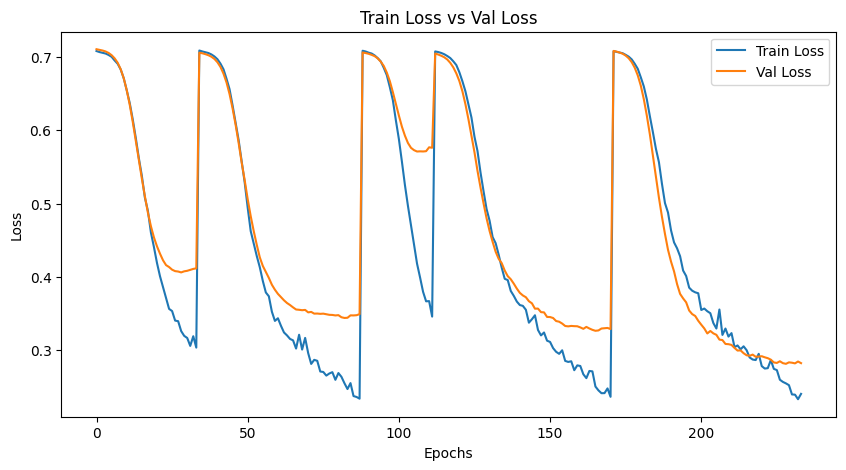

In [33]:
# Graficar Train Loss vs Val Loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train Loss vs Val Loss')
plt.legend()
plt.show()

## NODE_GAM

In [34]:
import numpy as np
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score
import torch
import os
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train_unbalance.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_resampled_df = pd.DataFrame(X_train_unbalance.numpy())
preprocessor.fit(X_train_resampled_df, Y_train_unbalance.numpy())
X_train_resampled_trans = preprocessor.transform(X_train_resampled_df)
X_test_df = pd.DataFrame(X_test_unbalance.numpy())
X_test_trans = preprocessor.transform(X_test_df)

# Definir el espacio de hiperparámetros reducido
param_distributions = {
    'num_trees': [100, 200, 300],
    'num_layers': [2, 3],
    'depth': [3, 4],
    'lr': [1e-4, 1e-3],
    'output_dropout': [0.2, 0.3],
    'last_dropout': [0.3, 0.4],
    'lr_warmup_steps': [200],
    'lr_decay_steps': [500],
    'early_stopping_steps': [500]
}

# Crear un wrapper para el modelo NodeGAMClassifier
class NodeGAMWrapper:
    def __init__(self, **params):
        self.params = params
        self.model = self.create_model(params)

    def create_model(self, params):
        return NodeGAMClassifier(
            in_features=X_train_resampled_df.shape[1],
            cat_features=None,
            arch='GAMAtt',
            batch_size=32,
            device=device,
            objective='error_rate',
            name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
            **params
        )

    def fit(self, X, y):
        print(f"Entrenando con los siguientes parámetros: {self.params}")
        self.model.fit(pd.DataFrame(X), y)
        print("Entrenamiento completado.")
        return self

    def predict(self, X):
        y_pred_prob = torch.sigmoid(torch.tensor(self.model.predict(pd.DataFrame(X)))).numpy()
        return (y_pred_prob > 0.5).astype(int)

    def predict_proba(self, X):
        y_pred_prob = torch.sigmoid(torch.tensor(self.model.predict(pd.DataFrame(X)))).numpy()
        return np.hstack([(1 - y_pred_prob).reshape(-1, 1), y_pred_prob.reshape(-1, 1)])

    def score(self, X, y):
        y_pred = self.predict(X)
        return accuracy_score(y, y_pred)

    def get_params(self, deep=False):
        return self.params

    def set_params(self, **params):
        self.params.update(params)
        self.model = self.create_model(self.params)
        return self

# Implementar RandomizedSearchCV con 5 folds de cross-validation
nodegam_model = NodeGAMWrapper()
scorings = ['f1']

for scoring in scorings:
    random_search = RandomizedSearchCV(
        estimator=nodegam_model,
        param_distributions=param_distributions,
        n_iter=10,  # Número reducido de combinaciones aleatorias a probar
        cv=5,  # Número de folds de cross-validation
        scoring=scoring,
        verbose=2,
        n_jobs=-1
    )                              

    # Entrenar el modelo con búsqueda de hiperparámetros
    random_search.fit(X_train_resampled_trans, Y_train_unbalance.numpy())

    # Mejor combinación de hiperparámetros
    print(f"Best parameters found for {scoring}: {random_search.best_params_}")
    print(f"Best cross-validation {scoring}: {random_search.best_score_}")

    # Guardar el mejor modelo completo
    best_model = random_search.best_estimator_
    model_path = f"D:\\tesis\\Modelo_extraccion_no\\node-gam\\best_nodegam_model_scapcabalinf_{scoring}.pkl"
    joblib.dump(best_model, model_path)

Using device: cuda
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Entrenando con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 300, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 3}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6976	0.3485
200	0.4825	0.1364
300	0.2704	0.0758
400	0.23	0.0455
500	0.1653	0.0455
600	0.1828	0.0152
700	0.1695	0.0303
800	0.0782	0.0303
900	0.0186	0.0152
1000	0.0444	0.0152
1100	0.1348	0.0152
1200	0.0312	0.0152
1300	0.0503	0.0152
1400	0.0999	0.0152
1500	0.0491	0.0152
1600	0.2938	0.0152
1700	0.0619	0.0152
1800	0.0521	0.0152
1900	0.0346	0.0152
2000	0.0269	0.0152
2100	0.0453	0.0152
2200	0.0871	0.0152
2300	0.1643	0.0152
2400	0.1003	0.0152
2500	0.0923	0.0152
BREAK. There is no improvment for 500 steps
Total training time: 46.1 seconds
Best step:  600
Best Val Metric:  0.015151515151515152
Load the best checkpoint.
Entrenamiento completado.
Best parameters found for f1: {'output_dropout': 0.3, 'num_trees': 300, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 3}
Best cross-validation f1: 0.9191856664580416


In [67]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import torch
import os
import joblib
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Definir una ruta para guardar los mejores modelos
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\node_gam\\inferior\\bal\\scaler_pca_bal", "mejor_nodegam_scaler_pca_balinf")
os.makedirs(best_model_path, exist_ok=True)

# Unir los conjuntos de entrenamiento y prueba
X_combined = torch.cat((X_train_unbalance, X_test_unbalance), dim=0)
y_combined = torch.cat((Y_train_unbalance, Y_test_unbalance), dim=0)

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_combined.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_combined_df = pd.DataFrame(X_combined.cpu().numpy())
preprocessor.fit(X_combined_df, y_combined.cpu().numpy())
X_combined_trans = preprocessor.transform(X_combined_df)

# Convertir a tensores de PyTorch y mover a la GPU
X_combined_trans = torch.tensor(X_combined_trans, dtype=torch.float32).to(device)

# Definir los mejores hiperparámetros encontrados
best_params = {
    'output_dropout': 0.3,
    'num_trees': 300,
    'num_layers': 2,
    'lr_warmup_steps': 200,
    'lr_decay_steps': 500,
    'lr': 0.001,
    'last_dropout': 0.3,
    'early_stopping_steps': 500,
    'depth': 3
}


# Crear un modelo NodeGAMClassifier con los mejores hiperparámetros
def create_model(params):
    return NodeGAMClassifier(
        in_features=X_combined_df.shape[1],
        cat_features=None,
        arch='GAMAtt',
        batch_size=32,
        device=device,
        objective='error_rate',
        name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
        **params
    )

# Implementar K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
val_losses = []
val_accuracies = []
f1s = []
precisions = []
recalls = []

best_overall_f1 = -1
best_model_fold = None

for fold, (train_index, val_index) in enumerate(kf.split(X_combined_trans)):
    print(f"Fold {fold + 1}")
    X_train_fold, X_val_fold = X_combined_trans[train_index], X_combined_trans[val_index]
    y_train_fold, y_val_fold = y_combined[train_index], y_combined[val_index]

    model = create_model(best_params)
    
    # Entrenamiento
    print(f"Entrenando fold {fold + 1} con los siguientes parámetros: {best_params}")
    model.fit(pd.DataFrame(X_train_fold.cpu().numpy()), y_train_fold.cpu().numpy())
    print("Entrenamiento completado.")
    
    # Validación
    y_val_pred = model.predict(pd.DataFrame(X_val_fold.cpu().numpy()))
    y_val_pred_classes = (torch.sigmoid(torch.tensor(y_val_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas
    val_accuracy = accuracy_score(y_val_fold.cpu().numpy(), y_val_pred_classes)*100
    f1 = f1_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted')*100
    precision = precision_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted')*100
    recall = recall_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted')*100

    val_accuracies.append(val_accuracy)
    f1s.append(f1)
    precisions.append(precision)
    recalls.append(recall)

    # Guardar el mejor modelo basado en F1-score
    if f1 > best_overall_f1:
        best_overall_f1 = f1
        best_model_fold = fold + 1

    print(f"Fold {fold + 1} val accuracy: {val_accuracy}, F1-score: {f1}")

# Guardar el mejor modelo basado en F1-score
if best_model_fold is not None:
    model_path = os.path.join(best_model_path, f"best_model_fold_{best_model_fold}.pth")
    model = create_model(best_params)
    model.fit(pd.DataFrame(X_combined_trans.cpu().numpy()), y_combined.cpu().numpy())
    joblib.dump(model, model_path)
    print(f"Mejor modelo guardado en: {model_path}")

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (428). n_quantiles is set to n_samples.
  warnings.warn(


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Using device: cuda
Fold 1
Entrenando fold 1 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 300, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 3}
Steps	Train Err	Val Metric (error_rate)
100	0.5847	0.2154
200	0.4457	0.1692
300	0.2477	0.1385
400	0.1618	0.0923
500	0.1685	0.0923
600	0.0783	0.0923
700	0.4459	0.0923
800	0.1029	0.0769
900	0.1119	0.0769
1000	0.2901	0.0769
1100	0.0453	0.0923
1200	0.1987	0.0923
1300	0.0706	0.0923
1400	0.0952	0.0923
1500	0.0514	0.0769
1600	0.0506	0.0769
1700	0.1731	0.0615
1800	0.0071	0.0769
1900	0.0904	0.0769
2000	0.0266	0.0769
2100	0.0935	0.0769
2200	0.1063	0.0923
2300	0.0536	0.0769
2400	0.065	0.0923
2500	0.0404	0.0923
BREAK. There is no improvment for 500 steps
Total training time: 47.7 seconds
Best step:  1700
Best Val Metric:  0.06153846153846154
Load the best checkpoint.
Entrenamiento completado.
Fold 1 val accuracy: 89.81481481481481, F1-score: 89.8

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (429). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.643	0.4462
200	0.4585	0.1846
300	0.44	0.2308
400	0.2664	0.1846
500	0.1258	0.1538
600	0.153	0.1538
700	0.0498	0.1846
800	0.142	0.1538
900	0.0258	0.1231
1000	0.056	0.1231
1100	0.1019	0.0769
1200	0.1083	0.0615
1300	0.0562	0.0769
1400	0.1098	0.0769
1500	0.0983	0.0923
1600	0.098	0.0923
1700	0.0648	0.0769
1800	0.021	0.0769
1900	0.07	0.0769
2000	0.0873	0.0769
2100	0.0194	0.0769
2200	0.0465	0.0769
2300	0.1093	0.0769
2400	0.0487	0.0769
2500	0.02	0.0769
BREAK. There is no improvment for 500 steps
Total training time: 48.7 seconds
Best step:  1200
Best Val Metric:  0.06153846153846154
Load the best checkpoint.
Entrenamiento completado.
Fold 2 val accuracy: 93.45794392523365, F1-score: 93.42988900773264
Fold 3
Entrenando fold 3 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 300, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 3}


...

Steps	Train Err	Val Metric (error_rate)
100	0.6847	0.2923
200	0.5261	0.1538
300	0.194	0.0615
400	0.3385	0.0154
500	0.2658	0.0154
600	0.1378	0.0
700	0.1646	0.0
800	0.3056	0.0
900	0.1822	0.0462
1000	0.084	0.0462
1100	0.07	0.0308
1200	0.0361	0.0308
1300	0.0939	0.0615
1400	0.0898	0.0615
1500	0.0462	0.0615
1600	0.1163	0.0615
1700	0.0923	0.0462
1800	0.0411	0.0462
1900	0.1482	0.0462
2000	0.1096	0.0462
2100	0.2294	0.0462
2200	0.0381	0.0462
2300	0.0312	0.0462
2400	0.0604	0.0615
2500	0.0415	0.0615
BREAK. There is no improvment for 500 steps
Total training time: 47.4 seconds
Best step:  600
Best Val Metric:  0.0
Load the best checkpoint.
Entrenamiento completado.
Fold 4 val accuracy: 92.5233644859813, F1-score: 92.5233644859813
Fold 5
Entrenando fold 5 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 300, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 3}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (429). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.5822	0.2308
200	0.4315	0.1385
300	0.1779	0.1077
400	0.1924	0.1077
500	0.1662	0.0615
600	0.1159	0.0462
700	0.0679	0.0615
800	0.1097	0.0769
900	0.2015	0.0769
1000	0.1802	0.0615
1100	0.2084	0.0769
1200	0.0422	0.0615
1300	0.1206	0.0769
1400	0.1462	0.0462
1500	0.4388	0.0769
1600	0.1034	0.0923
1700	0.0558	0.0923
1800	0.0478	0.0923
1900	0.174	0.0923
2000	0.1509	0.0923
2100	0.176	0.0923
2200	0.0779	0.0923
2300	0.0323	0.0923
2400	0.1443	0.0923
2500	0.0458	0.0923
BREAK. There is no improvment for 500 steps
Total training time: 48.4 seconds
Best step:  600
Best Val Metric:  0.046153846153846156
Load the best checkpoint.
Entrenamiento completado.
Fold 5 val accuracy: 95.32710280373831, F1-score: 95.32464618556803


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (536). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6424	0.2716
200	0.4403	0.1481
300	0.1934	0.0988
400	0.2343	0.0864
500	0.1492	0.0864
600	0.4275	0.1235
700	0.1071	0.1111
800	0.209	0.1111
900	0.1323	0.1235
1000	0.157	0.1235
1100	0.0675	0.1235
1200	0.0844	0.1111
1300	0.1626	0.1111
1400	0.1069	0.1111
1500	0.0939	0.1111
1600	0.0301	0.1235
1700	0.0485	0.1235
1800	0.0457	0.1235
1900	0.0587	0.1235
2000	0.0576	0.1235
2100	0.0531	0.1358
2200	0.2124	0.1358
2300	0.0719	0.1358
2400	0.0506	0.1481
2500	0.048	0.1481
BREAK. There is no improvment for 500 steps
Total training time: 48.3 seconds
Best step:  400
Best Val Metric:  0.08641975308641975
Load the best checkpoint.
Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\node_gam\inferior\bal\scaler_pca_bal\mejor_nodegam_scaler_pca_balinf\best_model_fold_5.pth


In [68]:
# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

accuracy_mean_std = format_metric(np.mean(val_accuracies), np.std(val_accuracies))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nPrecisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')


Precisión: 91.98 ± 2.39%
F1-score: 91.98 ± 2.38%
Precisión (Precision): 92.02 ± 2.38%
Recall: 91.98 ± 2.39%


# Nuevo

# BALANCED ANY

In [3]:
#CArgar tensores con el data set
# Cargar el dataset balanceado de entrenamiento
X_train, y_train = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac inf\\Train_inferior.pkl')

# Cargar el conjunto de prueba
X_test, y_test = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac inf\\Test_inferior.pkl')

In [4]:
smote = SMOTE(random_state=42)
X_train_resampled_s, y_train_resampled_s = smote.fit_resample(X_train, y_train)

In [5]:
X_train_unbalance= torch.tensor(X_train_resampled_s.values, dtype=torch.float32)
Y_train_unbalance= torch.tensor(y_train_resampled_s.values, dtype=torch.float32)
X_test_unbalance= torch.tensor(X_test.values, dtype=torch.float32)
Y_test_unbalance= torch.tensor(y_test.values, dtype=torch.float32)

In [6]:
# Verificar el balance de las clases
unique_classes, class_counts = torch.unique(Y_train_unbalance, return_counts=True)
for cls, count in zip(unique_classes, class_counts):
    print(f'Clase {cls.item()}: {count.item()} muestras')

Clase 0.0: 219 muestras
Clase 1.0: 219 muestras


## KAN

In [7]:
input_dim = X_train_unbalance.shape[1]
hidden_layers = [128, 64, 32, 16] # Reducción en el número de capas
output_dim = 1

   
def create_model():
    model = KAN([input_dim] + hidden_layers + [output_dim])
    return model

In [8]:
# Configuración inicial
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Ruta para guardar el mejor modelo
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\extrac inf\\any_bal\\", 'best_model.pth')

pos_weight = torch.tensor([len(y_train[y_train == 0]) / len(y_train[y_train == 1])]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
num_epochs = 200
batch_size = 32
patience = 10  # Paciencia para EarlyStopping

best_overall_f1 = -1
best_val_loss = float('inf')

# Realizar la validación cruzada
fold_no = 1
for train_index, val_index in kf.split(X_train):
    print(f'Fold {fold_no}')

    # Recrear el modelo y el optimizador para asegurarse de que los pesos se reinician
    model = create_model().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

    # División de los datos en entrenamiento y validación
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    train_dataset = TensorDataset(X_train_fold, y_train_fold)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    val_dataset = TensorDataset(X_val_fold, y_val_fold)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0
        epoch_train_accuracy = 0
        with tqdm(train_loader) as pbar:
            for inputs, labels in pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                epoch_train_loss += loss.item()
                accuracy = ((outputs > 0.5) == labels).float().mean()
                epoch_train_accuracy += accuracy.item()
                pbar.set_postfix(loss=loss.item(), accuracy=accuracy.item(), lr=optimizer.param_groups[0]['lr'])

        train_losses.append(epoch_train_loss / len(train_loader))
        train_accuracies.append(epoch_train_accuracy / len(train_loader))

        model.eval()
        val_loss = 0
        val_accuracy = 0
        all_labels = []
        all_outputs = []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze()
                val_loss += criterion(outputs, labels).item()
                val_accuracy += ((outputs > 0.5) == labels).float().mean().item()
                all_labels.extend(labels.cpu().numpy())
                all_outputs.extend(torch.sigmoid(outputs).cpu().numpy())

        val_loss /= len(val_loader)
        val_accuracy /= len(val_loader)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        y_pred_classes = np.array(all_outputs) > 0.5
        accuracy = accuracy_score(all_labels, y_pred_classes) * 100
        f1 = f1_score(all_labels, y_pred_classes, average='weighted') * 100
        precision = precision_score(all_labels, y_pred_classes, average='weighted') * 100
        recall = recall_score(all_labels, y_pred_classes, average='weighted') * 100

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        accuracys.append(accuracy)

        # Guardar el mejor modelo basado en la pérdida de validación
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_model_path)
            print(f'Mejor modelo guardado en: {best_model_path} con val_loss: {best_val_loss}')
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        scheduler.step(val_loss)
        print(f"Epoch {epoch + 1}, Train Loss: {epoch_train_loss / len(train_loader)}, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}")

        if epochs_no_improve == patience:
            print(f'Early stopping triggered after {epoch + 1} epochs.')
            break

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

    test_loss = 0
    test_accuracy = 0
    all_labels_test = []
    all_outputs_test = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            if outputs.dim() == 0:  # Si el output es un escalar
                outputs = outputs.unsqueeze(0)  # Añade una dimensión para que coincida con labels
            elif outputs.dim() == 1 and labels.dim() == 2:
                outputs = outputs.unsqueeze(1)  # Ajusta la salida para que coincida con labels
            test_loss += criterion(outputs, labels).item()
            test_accuracy += ((outputs > 0.5) == labels).float().mean().item()
            all_labels_test.extend(labels.cpu().numpy())
            all_outputs_test.extend(torch.sigmoid(outputs).cpu().numpy())

    test_loss /= len(test_loader)
    test_accuracy /= len(test_loader)

    # Calcular las métricas para el conjunto de prueba
    y_pred_classes_test = np.array(all_outputs_test) > 0.5
    accuracy_test = accuracy_score(all_labels_test, y_pred_classes_test) * 100
    f1_test = f1_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    precision_test = precision_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    recall_test = recall_score(all_labels_test, y_pred_classes_test, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Test metrics for fold {fold_no}: Accuracy: {accuracy_test}%, F1-score: {f1_test}%, Precision: {precision_test}%, Recall: {recall_test}%")


Fold 1


100%|██████████| 11/11 [00:00<00:00, 20.28it/s, accuracy=0.5, loss=0.684, lr=0.0001] 


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\extrac inf\any_bal\best_model.pth con val_loss: 0.6697882811228434
Epoch 1, Train Loss: 0.6854847723787482, Val Loss: 0.6697882811228434, Val Accuracy: 0.4861111144224803


100%|██████████| 11/11 [00:00<00:00, 42.65it/s, accuracy=0.5, loss=0.676, lr=0.0001] 


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\extrac inf\any_bal\best_model.pth con val_loss: 0.6584755579630533
Epoch 2, Train Loss: 0.6715499650348317, Val Loss: 0.6584755579630533, Val Accuracy: 0.4965277810891469


...

Epoch 8, Train Loss: 0.6151592623103749, Val Loss: 0.6086588501930237, Val Accuracy: 0.4950181146462758


100%|██████████| 11/11 [00:00<00:00, 52.18it/s, accuracy=0.548, loss=0.574, lr=0.0001]


Epoch 9, Train Loss: 0.6072791272943671, Val Loss: 0.594344953695933, Val Accuracy: 0.5303442080815634


100%|██████████| 11/11 [00:00<00:00, 48.41it/s, accuracy=0.677, loss=0.59, lr=0.0001]


Epoch 10, Train Loss: 0.5949982621453025, Val Loss: 0.5867605010668436, Val Accuracy: 0.5303442080815634
Early stopping triggered after 10 epochs.
Test metrics for fold 1: Accuracy: 79.59183673469387%, F1-score: 79.53109815354712%, Precision: 79.53769441024163%, Recall: 79.59183673469387%


In [9]:
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'
# Calcular las métricas medias y desviaciones estándar de validación cruzada
accuracy_mean_std = format_metric(np.mean(accuracys), np.std(accuracys))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Calcular las métricas medias y desviaciones estándar para el conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 77.09 ± 7.20%
F1-score: 76.68 ± 8.50%
Precisión (Precision): 78.19 ± 6.56%
Recall: 77.09 ± 7.20%

Métricas del Conjunto de Prueba:
Precisión: 78.37 ± 2.45%
F1-score: 78.37 ± 2.41%
Precisión (Precision): 78.82 ± 2.31%
Recall: 78.37 ± 2.45%


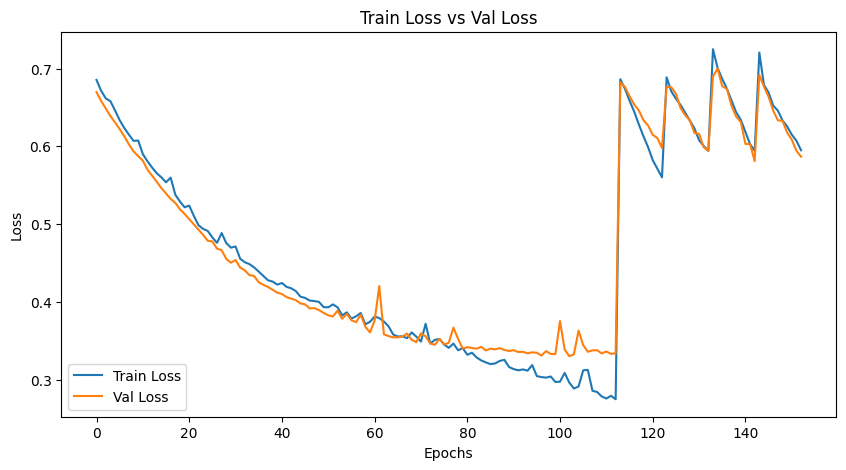

In [10]:
# Graficar Train Loss vs Val Loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train Loss vs Val Loss')
plt.legend()
plt.show()

## NODE_GAM

In [11]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import torch
import os
import joblib
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Definir una ruta para guardar los mejores modelos
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\node_gam\\inferior\\bal\\anybal")
os.makedirs(best_model_path, exist_ok=True)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train.shape[0] + X_test.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_df = pd.DataFrame(X_train.cpu().numpy())
X_test_df = pd.DataFrame(X_test.cpu().numpy())

preprocessor.fit(X_train_df, y_train.cpu().numpy())
X_train_trans = preprocessor.transform(X_train_df)
X_test_trans = preprocessor.transform(X_test_df)

# Convertir a tensores de PyTorch y mover a la GPU
X_train_trans = torch.tensor(X_train_trans, dtype=torch.float32).to(device)
X_test_trans = torch.tensor(X_test_trans, dtype=torch.float32).to(device)

# Definir los mejores hiperparámetros encontrados
best_params = {
    'output_dropout': 0.2,
    'num_trees': 200,
    'num_layers': 2,
    'lr_warmup_steps': 200,
    'lr_decay_steps': 500,
    'lr': 0.001,
    'last_dropout': 0.3,
    'early_stopping_steps': 500,
    'depth': 4
}

# Crear un modelo NodeGAMClassifier con los mejores hiperparámetros
def create_model(params):
    return NodeGAMClassifier(
        in_features=X_train_df.shape[1],
        cat_features=None,
        arch='GAMAtt',
        batch_size=32,
        device=device,
        objective='error_rate',
        name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
        **params
    )

# Inicializar listas para almacenar métricas
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Implementar K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
best_overall_f1 = -1
best_model_fold = None

for fold, (train_index, val_index) in enumerate(kf.split(X_train_trans)):
    print(f"Fold {fold + 1}")
    X_train_fold, X_val_fold = X_train_trans[train_index], X_train_trans[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    model = create_model(best_params)
    
    # Entrenamiento
    print(f"Entrenando fold {fold + 1} con los siguientes parámetros: {best_params}")
    model.fit(pd.DataFrame(X_train_fold.cpu().numpy()), y_train_fold.cpu().numpy())
    print("Entrenamiento completado.")
    
    # Validación
    y_val_pred = model.predict(pd.DataFrame(X_val_fold.cpu().numpy()))
    y_val_pred_classes = (torch.sigmoid(torch.tensor(y_val_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas
    val_accuracy = accuracy_score(y_val_fold.cpu().numpy(), y_val_pred_classes) * 100
    f1 = f1_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    precision = precision_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    recall = recall_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100

    val_accuracies.append(val_accuracy)
    f1s.append(f1)
    precisions.append(precision)
    recalls.append(recall)

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    y_test_pred = model.predict(pd.DataFrame(X_test_trans.cpu().numpy()))
    y_test_pred_classes = (torch.sigmoid(torch.tensor(y_test_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas para el conjunto de prueba
    accuracy_test = accuracy_score(y_test.cpu().numpy(), y_test_pred_classes) * 100
    f1_test = f1_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    precision_test = precision_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    recall_test = recall_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Fold {fold + 1} val accuracy: {val_accuracy}%, F1-score: {f1}%, Test accuracy: {accuracy_test}%, Test F1-score: {f1_test}%")

    # Guardar el mejor modelo basado en F1-score
    if f1 > best_overall_f1:
        best_overall_f1 = f1
        best_model_fold = fold + 1

# Guardar el mejor modelo basado en F1-score en el conjunto completo
if best_model_fold is not None:
    model_path = os.path.join(best_model_path, f"best_model_fold_{best_model_fold}.pth")
    best_model = create_model(best_params)
    best_model.fit(pd.DataFrame(X_train_trans.cpu().numpy()), y_train.cpu().numpy())
    joblib.dump(best_model, model_path)
    print(f"Mejor modelo guardado en: {model_path}")



WARNING! The apex is not installed so fp16 is not available.
Using device: cuda
Fold 1
Entrenando fold 1 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 200, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 4}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (536) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (350). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "
c:\Users\ferro\AppData\Local\Programs\Py

Steps	Train Err	Val Metric (error_rate)
100	0.5572	0.2264
200	0.3871	0.1698
300	0.2173	0.1698
400	0.1454	0.1321
500	0.0212	0.1321
600	0.0276	0.1321
700	0.0039	0.1321
800	0.0416	0.1321
900	0.019	0.1132
1000	0.0062	0.1132
1100	0.0396	0.0755
1200	0.0043	0.0755
1300	0.0524	0.0755
1400	0.0286	0.0755
1500	0.0032	0.0566
1600	0.0256	0.0377
1700	0.0672	0.0377
1800	0.0266	0.0377
1900	0.0091	0.0377
2000	0.0354	0.0377
2100	0.0164	0.0377
2200	0.0039	0.0566
2300	0.0093	0.0377
2400	0.0011	0.0377
2500	0.0019	0.0377
BREAK. There is no improvment for 500 steps
Total training time: 45.9 seconds
Best step:  1600
Best Val Metric:  0.03773584905660377
Load the best checkpoint.
Entrenamiento completado.
Fold 1 val accuracy: 90.9090909090909%, F1-score: 90.90439276485789%, Test accuracy: 92.85714285714286%, Test F1-score: 92.86542836052486%
Fold 2
Entrenando fold 2 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 200, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (350). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.5247	0.0755
200	0.4836	0.1132
300	0.4219	0.0943
400	0.0784	0.1321
500	0.116	0.1321
600	0.156	0.0755
700	0.0517	0.0566
800	0.0616	0.0755
900	0.0794	0.0377
1000	0.0676	0.0566
1100	0.0522	0.0566
1200	0.0061	0.0377
1300	0.0175	0.0377
1400	0.0023	0.0377
1500	0.0238	0.0377
1600	0.0223	0.0377
1700	0.0685	0.0377
1800	0.0162	0.0566
1900	0.1541	0.0377
2000	0.0698	0.0377
2100	0.0023	0.0189
2200	0.0113	0.0377
2300	0.003	0.0377
2400	0.0053	0.0377
2500	0.0165	0.0377
2600	0.017	0.0377
BREAK. There is no improvment for 500 steps
Total training time: 45.5 seconds
Best step:  2100
Best Val Metric:  0.018867924528301886
Load the best checkpoint.
Entrenamiento completado.
Fold 2 val accuracy: 89.77272727272727%, F1-score: 89.77140643161565%, Test accuracy: 90.81632653061224%, Test F1-score: 90.82697932067481%
Fold 3
Entrenando fold 3 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 200, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_step

...

Steps	Train Err	Val Metric (error_rate)
100	0.7453	0.1509
200	0.5678	0.0943
300	0.4115	0.0566
400	0.1209	0.0755
500	0.137	0.0943
600	0.1292	0.0943
700	0.0265	0.0943
800	0.1293	0.0755
900	0.0643	0.0755
1000	0.1378	0.0755
1100	0.0502	0.0755
1200	0.0015	0.0755
1300	0.0191	0.0943
1400	0.001	0.0755
1500	0.0087	0.0943
1600	0.0203	0.0943
1700	0.0002	0.0566
1800	0.0111	0.0943
1900	0.0501	0.0755
2000	0.0035	0.0755
2100	0.016	0.0755
2200	0.012	0.0943
2300	0.0049	0.0943
2400	0.0571	0.0943
2500	0.0042	0.0943
BREAK. There is no improvment for 500 steps
Total training time: 44.6 seconds
Best step:  300
Best Val Metric:  0.05660377358490566
Load the best checkpoint.
Entrenamiento completado.
Fold 4 val accuracy: 83.9080459770115%, F1-score: 83.9080459770115%, Test accuracy: 87.75510204081633%, Test F1-score: 87.7961750738031%
Fold 5
Entrenando fold 5 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 200, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'l

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (351). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6919	0.1321
200	0.5091	0.1132
300	0.257	0.0755
400	0.2346	0.0755
500	0.0914	0.0755
600	0.0291	0.0755
700	0.1459	0.0943
800	0.0867	0.0755
900	0.0783	0.0566
1000	0.0426	0.0377
1100	0.0675	0.0377
1200	0.0259	0.0377
1300	0.0041	0.0377
1400	0.1202	0.0377
1500	0.0882	0.0377
1600	0.0527	0.0377
1700	0.009	0.0377
1800	0.0077	0.0377
1900	0.026	0.0566
2000	0.0048	0.0377
2100	0.0017	0.0377
2200	0.0063	0.0377
2300	0.0	0.0377
2400	0.0005	0.0377
2500	0.0212	0.0377
BREAK. There is no improvment for 500 steps
Total training time: 44.7 seconds
Best step:  1000
Best Val Metric:  0.03773584905660377
Load the best checkpoint.
Entrenamiento completado.
Fold 5 val accuracy: 93.10344827586206%, F1-score: 93.10344827586206%, Test accuracy: 92.85714285714286%, Test F1-score: 92.87739457853917%


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.5549	0.2424
200	0.3131	0.197
300	0.1343	0.1818
400	0.1279	0.1515
500	0.0655	0.1061
600	0.0712	0.0758
700	0.2918	0.0606
800	0.0227	0.0606
900	0.059	0.0758
1000	0.0322	0.0758
1100	0.0096	0.0758
1200	0.0246	0.0758
1300	0.0482	0.1212
1400	0.0663	0.0758
1500	0.0184	0.0758
1600	0.0345	0.0758
1700	0.0319	0.1061
1800	0.0728	0.0909
1900	0.0319	0.0758
2000	0.0127	0.1061
2100	0.0126	0.0909
2200	0.0215	0.1061
2300	0.0218	0.0909
2400	0.0154	0.0909
2500	0.0253	0.0758
BREAK. There is no improvment for 500 steps
Total training time: 44.7 seconds
Best step:  700
Best Val Metric:  0.06060606060606061
Load the best checkpoint.
Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\node_gam\inferior\bal\anybal\best_model_fold_5.pth


In [12]:
# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

# Métricas de validación cruzada
accuracy_mean_std = format_metric(np.mean(val_accuracies), np.std(val_accuracies))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Métricas del conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 89.49 ± 3.05%
F1-score: 89.49 ± 3.05%
Precisión (Precision): 89.51 ± 3.05%
Recall: 89.49 ± 3.05%

Métricas del Conjunto de Prueba:
Precisión: 91.22 ± 1.89%
F1-score: 91.24 ± 1.88%
Precisión (Precision): 91.36 ± 1.80%
Recall: 91.22 ± 1.89%


# Balanced PCA

In [13]:
#CArgar tensores con el data set
# Cargar el dataset balanceado de entrenamiento
X_train, y_train = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac inf\\Train_inferior.pkl')

# Cargar el conjunto de prueba
X_test, y_test = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac inf\\Test_inferior.pkl')

In [14]:
smote = SMOTE(random_state=42)
X_train_resampled_s, y_train_resampled_s = smote.fit_resample(X_train, y_train)

In [15]:
from sklearn import decomposition

pca = decomposition.PCA(n_components=0.96,svd_solver='full',tol=1e-4)
pca.fit(X_train_resampled_s)
X_train_pca= pca.transform(X_train_resampled_s)
X_test_pca=pca.transform(X_test)

In [16]:
X_train_unbalance= torch.tensor(X_train_pca, dtype=torch.float32)
Y_train_unbalance= torch.tensor(y_train_resampled_s.values, dtype=torch.float32)
X_test_unbalance= torch.tensor(X_test_pca, dtype=torch.float32)
Y_test_unbalance= torch.tensor(y_test.values, dtype=torch.float32)


## KAN

In [17]:
input_dim = X_train_unbalance.shape[1]
hidden_layers = [128, 64, 32, 16] # Reducción en el número de capas
output_dim = 1

   
def create_model():
    model = KAN([input_dim] + hidden_layers + [output_dim])
    return model

In [18]:
# Configuración inicial
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Ruta para guardar el mejor modelo
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\extrac inf\\pca_bal\\", 'best_model.pth')

pos_weight = torch.tensor([len(y_train[y_train == 0]) / len(y_train[y_train == 1])]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
num_epochs = 200
batch_size = 32
patience = 10  # Paciencia para EarlyStopping

best_overall_f1 = -1
best_val_loss = float('inf')

# Realizar la validación cruzada
fold_no = 1
for train_index, val_index in kf.split(X_train):
    print(f'Fold {fold_no}')

    # Recrear el modelo y el optimizador para asegurarse de que los pesos se reinician
    model = create_model().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

    # División de los datos en entrenamiento y validación
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    train_dataset = TensorDataset(X_train_fold, y_train_fold)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    val_dataset = TensorDataset(X_val_fold, y_val_fold)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0
        epoch_train_accuracy = 0
        with tqdm(train_loader) as pbar:
            for inputs, labels in pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                epoch_train_loss += loss.item()
                accuracy = ((outputs > 0.5) == labels).float().mean()
                epoch_train_accuracy += accuracy.item()
                pbar.set_postfix(loss=loss.item(), accuracy=accuracy.item(), lr=optimizer.param_groups[0]['lr'])

        train_losses.append(epoch_train_loss / len(train_loader))
        train_accuracies.append(epoch_train_accuracy / len(train_loader))

        model.eval()
        val_loss = 0
        val_accuracy = 0
        all_labels = []
        all_outputs = []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze()
                val_loss += criterion(outputs, labels).item()
                val_accuracy += ((outputs > 0.5) == labels).float().mean().item()
                all_labels.extend(labels.cpu().numpy())
                all_outputs.extend(torch.sigmoid(outputs).cpu().numpy())

        val_loss /= len(val_loader)
        val_accuracy /= len(val_loader)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        y_pred_classes = np.array(all_outputs) > 0.5
        accuracy = accuracy_score(all_labels, y_pred_classes) * 100
        f1 = f1_score(all_labels, y_pred_classes, average='weighted') * 100
        precision = precision_score(all_labels, y_pred_classes, average='weighted') * 100
        recall = recall_score(all_labels, y_pred_classes, average='weighted') * 100

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        accuracys.append(accuracy)

        # Guardar el mejor modelo basado en la pérdida de validación
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_model_path)
            print(f'Mejor modelo guardado en: {best_model_path} con val_loss: {best_val_loss}')
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        scheduler.step(val_loss)
        print(f"Epoch {epoch + 1}, Train Loss: {epoch_train_loss / len(train_loader)}, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}")

        if epochs_no_improve == patience:
            print(f'Early stopping triggered after {epoch + 1} epochs.')
            break

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

    test_loss = 0
    test_accuracy = 0
    all_labels_test = []
    all_outputs_test = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            if outputs.dim() == 0:  # Si el output es un escalar
                outputs = outputs.unsqueeze(0)  # Añade una dimensión para que coincida con labels
            elif outputs.dim() == 1 and labels.dim() == 2:
                outputs = outputs.unsqueeze(1)  # Ajusta la salida para que coincida con labels
            test_loss += criterion(outputs, labels).item()
            test_accuracy += ((outputs > 0.5) == labels).float().mean().item()
            all_labels_test.extend(labels.cpu().numpy())
            all_outputs_test.extend(torch.sigmoid(outputs).cpu().numpy())

    test_loss /= len(test_loader)
    test_accuracy /= len(test_loader)

    # Calcular las métricas para el conjunto de prueba
    y_pred_classes_test = np.array(all_outputs_test) > 0.5
    accuracy_test = accuracy_score(all_labels_test, y_pred_classes_test) * 100
    f1_test = f1_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    precision_test = precision_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    recall_test = recall_score(all_labels_test, y_pred_classes_test, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Test metrics for fold {fold_no}: Accuracy: {accuracy_test}%, F1-score: {f1_test}%, Precision: {precision_test}%, Recall: {recall_test}%")


Fold 1


100%|██████████| 11/11 [00:00<00:00, 45.95it/s, accuracy=0.567, loss=0.69, lr=0.0001] 


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\extrac inf\pca_bal\best_model.pth con val_loss: 0.6866719921429952
Epoch 1, Train Loss: 0.6910179907625372, Val Loss: 0.6866719921429952, Val Accuracy: 0.4861111144224803


100%|██████████| 11/11 [00:00<00:00, 40.66it/s, accuracy=0.367, loss=0.687, lr=0.0001]


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\extrac inf\pca_bal\best_model.pth con val_loss: 0.6800585587819418
Epoch 2, Train Loss: 0.6854801232164557, Val Loss: 0.6800585587819418, Val Accuracy: 0.4861111144224803


...

Epoch 8, Train Loss: 0.613796201619235, Val Loss: 0.6226354241371155, Val Accuracy: 0.5262681146462759


100%|██████████| 11/11 [00:00<00:00, 50.55it/s, accuracy=0.581, loss=0.619, lr=0.0001]


Epoch 9, Train Loss: 0.5968234159729697, Val Loss: 0.6067818800608317, Val Accuracy: 0.5656702915827433


100%|██████████| 11/11 [00:00<00:00, 45.04it/s, accuracy=0.613, loss=0.581, lr=0.0001]


Epoch 10, Train Loss: 0.5794679847630587, Val Loss: 0.5915519197781881, Val Accuracy: 0.5865036249160767
Early stopping triggered after 10 epochs.
Test metrics for fold 1: Accuracy: 75.51020408163265%, F1-score: 75.34253752849021%, Precision: 75.43215460891005%, Recall: 75.51020408163265%


In [19]:
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'
# Calcular las métricas medias y desviaciones estándar de validación cruzada
accuracy_mean_std = format_metric(np.mean(accuracys), np.std(accuracys))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Calcular las métricas medias y desviaciones estándar para el conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 74.69 ± 6.22%
F1-score: 74.44 ± 6.63%
Precisión (Precision): 75.85 ± 5.68%
Recall: 74.69 ± 6.22%

Métricas del Conjunto de Prueba:
Precisión: 72.86 ± 2.93%
F1-score: 72.85 ± 2.91%
Precisión (Precision): 73.22 ± 2.86%
Recall: 72.86 ± 2.93%


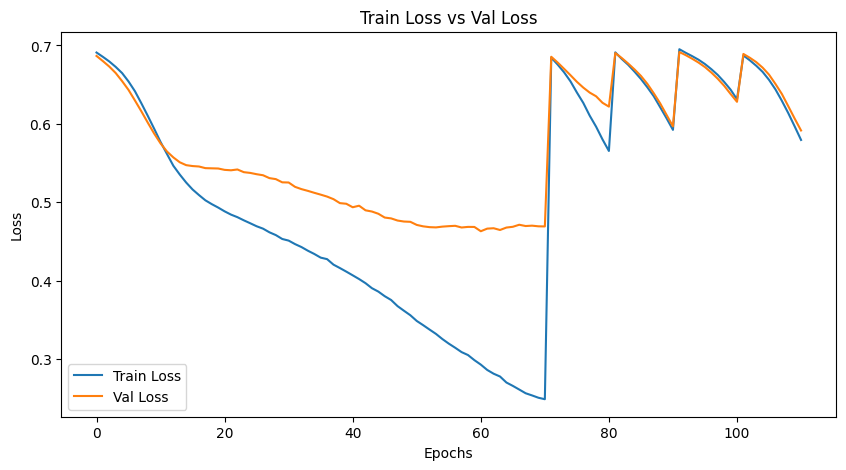

In [20]:
# Graficar Train Loss vs Val Loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train Loss vs Val Loss')
plt.legend()
plt.show()

## NODE_GAM

In [21]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import torch
import os
import joblib
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Definir una ruta para guardar los mejores modelos
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\node_gam\\inferior\\bal\\PCA_BAL")
os.makedirs(best_model_path, exist_ok=True)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train.shape[0] + X_test.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_df = pd.DataFrame(X_train.cpu().numpy())
X_test_df = pd.DataFrame(X_test.cpu().numpy())

preprocessor.fit(X_train_df, y_train.cpu().numpy())
X_train_trans = preprocessor.transform(X_train_df)
X_test_trans = preprocessor.transform(X_test_df)

# Convertir a tensores de PyTorch y mover a la GPU
X_train_trans = torch.tensor(X_train_trans, dtype=torch.float32).to(device)
X_test_trans = torch.tensor(X_test_trans, dtype=torch.float32).to(device)

# Definir los mejores hiperparámetros encontrados
# Definir los mejores hiperparámetros encontrados
best_params = {
    'output_dropout': 0.3,
    'num_trees': 200,
    'num_layers': 3,
    'lr_warmup_steps': 200,
    'lr_decay_steps': 500,
    'lr': 0.0001,
    'last_dropout': 0.3,
    'early_stopping_steps': 500,
    'depth': 3
}


# Crear un modelo NodeGAMClassifier con los mejores hiperparámetros
def create_model(params):
    return NodeGAMClassifier(
        in_features=X_train_df.shape[1],
        cat_features=None,
        arch='GAMAtt',
        batch_size=32,
        device=device,
        objective='error_rate',
        name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
        **params
    )

# Inicializar listas para almacenar métricas
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Implementar K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
best_overall_f1 = -1
best_model_fold = None

for fold, (train_index, val_index) in enumerate(kf.split(X_train_trans)):
    print(f"Fold {fold + 1}")
    X_train_fold, X_val_fold = X_train_trans[train_index], X_train_trans[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    model = create_model(best_params)
    
    # Entrenamiento
    print(f"Entrenando fold {fold + 1} con los siguientes parámetros: {best_params}")
    model.fit(pd.DataFrame(X_train_fold.cpu().numpy()), y_train_fold.cpu().numpy())
    print("Entrenamiento completado.")
    
    # Validación
    y_val_pred = model.predict(pd.DataFrame(X_val_fold.cpu().numpy()))
    y_val_pred_classes = (torch.sigmoid(torch.tensor(y_val_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas
    val_accuracy = accuracy_score(y_val_fold.cpu().numpy(), y_val_pred_classes) * 100
    f1 = f1_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    precision = precision_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    recall = recall_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100

    val_accuracies.append(val_accuracy)
    f1s.append(f1)
    precisions.append(precision)
    recalls.append(recall)

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    y_test_pred = model.predict(pd.DataFrame(X_test_trans.cpu().numpy()))
    y_test_pred_classes = (torch.sigmoid(torch.tensor(y_test_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas para el conjunto de prueba
    accuracy_test = accuracy_score(y_test.cpu().numpy(), y_test_pred_classes) * 100
    f1_test = f1_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    precision_test = precision_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    recall_test = recall_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Fold {fold + 1} val accuracy: {val_accuracy}%, F1-score: {f1}%, Test accuracy: {accuracy_test}%, Test F1-score: {f1_test}%")

    # Guardar el mejor modelo basado en F1-score
    if f1 > best_overall_f1:
        best_overall_f1 = f1
        best_model_fold = fold + 1

# Guardar el mejor modelo basado en F1-score en el conjunto completo
if best_model_fold is not None:
    model_path = os.path.join(best_model_path, f"best_model_fold_{best_model_fold}.pth")
    best_model = create_model(best_params)
    best_model.fit(pd.DataFrame(X_train_trans.cpu().numpy()), y_train.cpu().numpy())
    joblib.dump(best_model, model_path)
    print(f"Mejor modelo guardado en: {model_path}")


Using device: cuda
Fold 1
Entrenando fold 1 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 3}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (536) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (350). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.7708	0.4528
200	0.7595	0.3774
300	0.4861	0.3396
400	0.5435	0.2453
500	0.7984	0.2075
600	0.4536	0.1698
700	0.3771	0.1887
800	0.4335	0.1887
900	0.4368	0.1698
1000	0.3281	0.1698
1100	0.4439	0.1509
1200	0.3025	0.1509
1300	0.3105	0.1509
1400	0.1342	0.1698
1500	0.2512	0.1509
1600	0.0414	0.1509
1700	0.4736	0.1509
1800	0.2865	0.1509
1900	0.2763	0.1509
2000	0.1236	0.1698
2100	0.3015	0.1698
2200	0.2073	0.1509
2300	0.4521	0.1509
2400	0.1344	0.1509
2500	0.3213	0.1509
BREAK. There is no improvment for 500 steps
Total training time: 68.7 seconds
Best step:  1100
Best Val Metric:  0.1509433962264151
Load the best checkpoint.
Entrenamiento completado.
Fold 1 val accuracy: 86.36363636363636%, F1-score: 86.35658914728683%, Test accuracy: 82.6530612244898%, Test F1-score: 82.70224397645228%
Fold 2
Entrenando fold 2 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (350). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.796	0.5849
200	0.8853	0.5283
300	0.5968	0.3396
400	0.64	0.3019
500	0.6474	0.2453
600	0.4329	0.2453
700	0.5736	0.1321
800	0.38	0.0943
900	0.1952	0.1132
1000	0.3529	0.0943
1100	0.3818	0.0755
1200	0.2042	0.0943
1300	0.3772	0.0755
1400	0.4859	0.1132
1500	1.0284	0.0943
1600	0.5911	0.1321
1700	0.6373	0.1321
1800	0.394	0.1321
1900	0.2002	0.1321
2000	0.3002	0.1132
2100	0.6778	0.1321
2200	0.1398	0.1321
2300	0.1741	0.1321
2400	1.5296	0.1132
2500	0.4325	0.1132
BREAK. There is no improvment for 500 steps
Total training time: 70.8 seconds
Best step:  1100
Best Val Metric:  0.07547169811320754
Load the best checkpoint.
Entrenamiento completado.
Fold 2 val accuracy: 84.0909090909091%, F1-score: 83.78947368421052%, Test accuracy: 86.73469387755102%, Test F1-score: 86.75008124097472%
Fold 3
Entrenando fold 3 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0001, 

...

Steps	Train Err	Val Metric (error_rate)
100	0.6366	0.4528
200	0.6452	0.4528
300	0.5348	0.3585
400	0.6548	0.3208
500	0.5341	0.2453
600	0.726	0.1698
700	0.367	0.1698
800	0.3812	0.1509
900	0.6093	0.1509
1000	0.2214	0.1509
1100	0.4146	0.1698
1200	0.1776	0.1698
1300	0.2364	0.1698
1400	0.2119	0.1698
1500	0.4471	0.1509
1600	0.4967	0.1698
1700	0.4102	0.1698
1800	0.3711	0.1321
1900	0.6069	0.1321
2000	0.4613	0.1509
2100	0.1311	0.1509
2200	0.2363	0.1509
2300	0.3497	0.1698
2400	0.1617	0.1509
2500	0.242	0.1509
BREAK. There is no improvment for 500 steps
Total training time: 65.8 seconds
Best step:  1800
Best Val Metric:  0.1320754716981132
Load the best checkpoint.
Entrenamiento completado.
Fold 4 val accuracy: 86.20689655172413%, F1-score: 86.2839325018342%, Test accuracy: 85.71428571428571%, Test F1-score: 85.671768707483%
Fold 5
Entrenando fold 5 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0001, 

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (351). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.7655	0.6038
200	0.7668	0.5472
300	0.5733	0.4151
400	0.5527	0.3208
500	0.5945	0.2075
600	0.4657	0.1698
700	0.9679	0.1509
800	0.4386	0.1321
900	0.5522	0.1132
1000	0.2386	0.1321
1100	0.3776	0.1321
1200	0.7683	0.1321
1300	0.2859	0.1132
1400	0.2296	0.1321
1500	0.3923	0.1321
1600	0.2699	0.1321
1700	0.1667	0.1509
1800	0.283	0.1509
1900	0.2956	0.1509
2000	0.3239	0.1509
2100	0.1579	0.1509
2200	0.3001	0.1509
2300	0.2039	0.1321
2400	0.3806	0.1321
2500	0.4245	0.1321
BREAK. There is no improvment for 500 steps
Total training time: 64.9 seconds
Best step:  900
Best Val Metric:  0.11320754716981132
Load the best checkpoint.
Entrenamiento completado.
Fold 5 val accuracy: 87.35632183908046%, F1-score: 87.28893381423879%, Test accuracy: 85.71428571428571%, Test F1-score: 85.76220425277029%


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.7135	0.6364
200	0.5887	0.6061
300	0.638	0.5
400	0.6204	0.3788
500	0.4297	0.2576
600	0.5021	0.2121
700	0.416	0.1364
800	0.4193	0.1212
900	0.7048	0.1364
1000	0.5399	0.1212
1100	0.366	0.1212
1200	0.5209	0.1212
1300	0.3617	0.1061
1400	0.2715	0.1061
1500	0.2151	0.0909
1600	0.3123	0.0909
1700	0.4775	0.0909
1800	0.2039	0.0909
1900	0.3673	0.0909
2000	0.3865	0.0909
2100	0.3687	0.0909
2200	0.2758	0.0909
2300	0.1982	0.0909
2400	0.3032	0.0909
2500	0.2878	0.0909
BREAK. There is no improvment for 500 steps
Total training time: 65.9 seconds
Best step:  1500
Best Val Metric:  0.09090909090909091
Load the best checkpoint.
Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\node_gam\inferior\bal\PCA_BAL\best_model_fold_5.pth


In [22]:
# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

# Métricas de validación cruzada
accuracy_mean_std = format_metric(np.mean(val_accuracies), np.std(val_accuracies))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Métricas del conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 84.94 ± 2.38%
F1-score: 84.91 ± 2.35%
Precisión (Precision): 85.95 ± 2.28%
Recall: 84.94 ± 2.38%

Métricas del Conjunto de Prueba:
Precisión: 85.31 ± 1.38%
F1-score: 85.32 ± 1.37%
Precisión (Precision): 85.44 ± 1.33%
Recall: 85.31 ± 1.38%


# Balanced scaler

In [23]:
#CArgar tensores con el data set
# Cargar el dataset balanceado de entrenamiento
X_train, y_train = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac inf\\Train_inferior.pkl')

# Cargar el conjunto de prueba
X_test, y_test = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac inf\\Test_inferior.pkl')

In [24]:
smote = SMOTE(random_state=42)
X_train_resampled_s, y_train_resampled_s = smote.fit_resample(X_train, y_train)

In [25]:
scaler = StandardScaler().fit(X_train)

X_train_scaler = scaler.transform(X_train_resampled_s)
X_test_scaler = scaler.transform(X_test)

In [26]:
X_train_unbalance= torch.tensor(X_train_scaler, dtype=torch.float32)
Y_train_unbalance= torch.tensor(y_train_resampled_s.values, dtype=torch.float32)
X_test_unbalance= torch.tensor(X_test_scaler, dtype=torch.float32)
Y_test_unbalance= torch.tensor(y_test.values, dtype=torch.float32)

## KAN

In [27]:
input_dim = X_train_unbalance.shape[1]
hidden_layers = [128, 64, 32, 16] # Reducción en el número de capas
output_dim = 1

   
def create_model():
    model = KAN([input_dim] + hidden_layers + [output_dim])
    return model

In [28]:
# Configuración inicial
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Ruta para guardar el mejor modelo
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\extrac inf\\scale_bal\\", 'best_model.pth')

pos_weight = torch.tensor([len(y_train[y_train == 0]) / len(y_train[y_train == 1])]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
num_epochs = 200
batch_size = 32
patience = 10  # Paciencia para EarlyStopping

best_overall_f1 = -1
best_val_loss = float('inf')

# Realizar la validación cruzada
fold_no = 1
for train_index, val_index in kf.split(X_train):
    print(f'Fold {fold_no}')

    # Recrear el modelo y el optimizador para asegurarse de que los pesos se reinician
    model = create_model().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

    # División de los datos en entrenamiento y validación
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    train_dataset = TensorDataset(X_train_fold, y_train_fold)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    val_dataset = TensorDataset(X_val_fold, y_val_fold)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0
        epoch_train_accuracy = 0
        with tqdm(train_loader) as pbar:
            for inputs, labels in pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                epoch_train_loss += loss.item()
                accuracy = ((outputs > 0.5) == labels).float().mean()
                epoch_train_accuracy += accuracy.item()
                pbar.set_postfix(loss=loss.item(), accuracy=accuracy.item(), lr=optimizer.param_groups[0]['lr'])

        train_losses.append(epoch_train_loss / len(train_loader))
        train_accuracies.append(epoch_train_accuracy / len(train_loader))

        model.eval()
        val_loss = 0
        val_accuracy = 0
        all_labels = []
        all_outputs = []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze()
                val_loss += criterion(outputs, labels).item()
                val_accuracy += ((outputs > 0.5) == labels).float().mean().item()
                all_labels.extend(labels.cpu().numpy())
                all_outputs.extend(torch.sigmoid(outputs).cpu().numpy())

        val_loss /= len(val_loader)
        val_accuracy /= len(val_loader)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        y_pred_classes = np.array(all_outputs) > 0.5
        accuracy = accuracy_score(all_labels, y_pred_classes) * 100
        f1 = f1_score(all_labels, y_pred_classes, average='weighted') * 100
        precision = precision_score(all_labels, y_pred_classes, average='weighted') * 100
        recall = recall_score(all_labels, y_pred_classes, average='weighted') * 100

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        accuracys.append(accuracy)

        # Guardar el mejor modelo basado en la pérdida de validación
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_model_path)
            print(f'Mejor modelo guardado en: {best_model_path} con val_loss: {best_val_loss}')
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        scheduler.step(val_loss)
        print(f"Epoch {epoch + 1}, Train Loss: {epoch_train_loss / len(train_loader)}, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}")

        if epochs_no_improve == patience:
            print(f'Early stopping triggered after {epoch + 1} epochs.')
            break

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

    test_loss = 0
    test_accuracy = 0
    all_labels_test = []
    all_outputs_test = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            if outputs.dim() == 0:  # Si el output es un escalar
                outputs = outputs.unsqueeze(0)  # Añade una dimensión para que coincida con labels
            elif outputs.dim() == 1 and labels.dim() == 2:
                outputs = outputs.unsqueeze(1)  # Ajusta la salida para que coincida con labels
            test_loss += criterion(outputs, labels).item()
            test_accuracy += ((outputs > 0.5) == labels).float().mean().item()
            all_labels_test.extend(labels.cpu().numpy())
            all_outputs_test.extend(torch.sigmoid(outputs).cpu().numpy())

    test_loss /= len(test_loader)
    test_accuracy /= len(test_loader)

    # Calcular las métricas para el conjunto de prueba
    y_pred_classes_test = np.array(all_outputs_test) > 0.5
    accuracy_test = accuracy_score(all_labels_test, y_pred_classes_test) * 100
    f1_test = f1_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    precision_test = precision_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    recall_test = recall_score(all_labels_test, y_pred_classes_test, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Test metrics for fold {fold_no}: Accuracy: {accuracy_test}%, F1-score: {f1_test}%, Precision: {precision_test}%, Recall: {recall_test}%")


Fold 1


100%|██████████| 11/11 [00:00<00:00, 42.34it/s, accuracy=0.367, loss=0.691, lr=0.0001]


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\extrac inf\scale_bal\best_model.pth con val_loss: 0.6919812758763632
Epoch 1, Train Loss: 0.6923849149183794, Val Loss: 0.6919812758763632, Val Accuracy: 0.4861111144224803


100%|██████████| 11/11 [00:00<00:00, 39.26it/s, accuracy=0.567, loss=0.692, lr=0.0001]


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\extrac inf\scale_bal\best_model.pth con val_loss: 0.6910241842269897
Epoch 2, Train Loss: 0.6914542100646279, Val Loss: 0.6910241842269897, Val Accuracy: 0.4861111144224803


...

Epoch 8, Train Loss: 0.6803045056082986, Val Loss: 0.6777107119560242, Val Accuracy: 0.4701086978117625


100%|██████████| 11/11 [00:00<00:00, 47.71it/s, accuracy=0.419, loss=0.669, lr=0.0001]


Epoch 9, Train Loss: 0.6750005917115645, Val Loss: 0.6715253194173177, Val Accuracy: 0.4701086978117625


100%|██████████| 11/11 [00:00<00:00, 51.14it/s, accuracy=0.419, loss=0.667, lr=0.0001]


Epoch 10, Train Loss: 0.6678203669461337, Val Loss: 0.6627719600995382, Val Accuracy: 0.4701086978117625
Early stopping triggered after 10 epochs.
Test metrics for fold 1: Accuracy: 84.6938775510204%, F1-score: 84.73727409686967%, Precision: 84.93959456692376%, Recall: 84.6938775510204%


In [29]:
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'
# Calcular las métricas medias y desviaciones estándar de validación cruzada
accuracy_mean_std = format_metric(np.mean(accuracys), np.std(accuracys))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Calcular las métricas medias y desviaciones estándar para el conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 77.51 ± 8.72%
F1-score: 76.82 ± 10.34%
Precisión (Precision): 79.76 ± 6.05%
Recall: 77.51 ± 8.72%

Métricas del Conjunto de Prueba:
Precisión: 81.63 ± 3.76%
F1-score: 81.55 ± 3.87%
Precisión (Precision): 83.50 ± 1.99%
Recall: 81.63 ± 3.76%


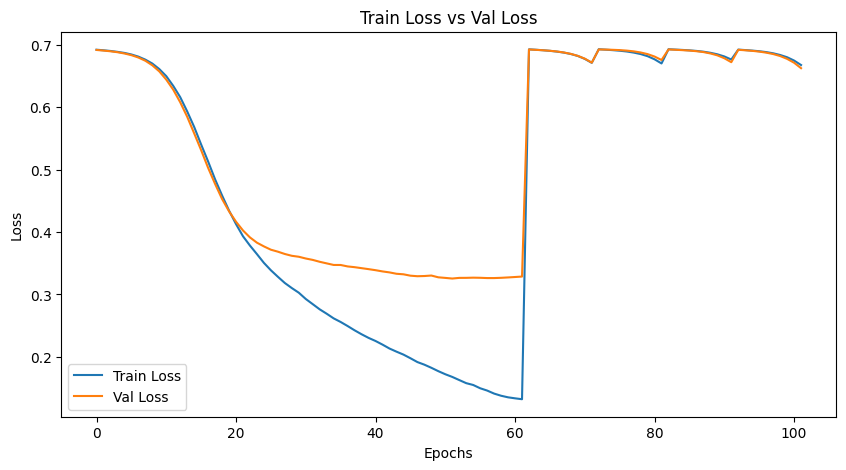

In [30]:
# Graficar Train Loss vs Val Loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train Loss vs Val Loss')
plt.legend()
plt.show()

## NODE_GAM

In [31]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import torch
import os
import joblib
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Definir una ruta para guardar los mejores modelos
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\node_gam\\inferior\\bal\\SCALER_BAL")
os.makedirs(best_model_path, exist_ok=True)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train.shape[0] + X_test.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_df = pd.DataFrame(X_train.cpu().numpy())
X_test_df = pd.DataFrame(X_test.cpu().numpy())

preprocessor.fit(X_train_df, y_train.cpu().numpy())
X_train_trans = preprocessor.transform(X_train_df)
X_test_trans = preprocessor.transform(X_test_df)

# Convertir a tensores de PyTorch y mover a la GPU
X_train_trans = torch.tensor(X_train_trans, dtype=torch.float32).to(device)
X_test_trans = torch.tensor(X_test_trans, dtype=torch.float32).to(device)

# Definir los mejores hiperparámetros encontrados
# Definir los mejores hiperparámetros encontrados
best_params = {
    'output_dropout': 0.2,
    'num_trees': 200,
    'num_layers': 3,
    'lr_warmup_steps': 200,
    'lr_decay_steps': 500,
    'lr': 0.001,
    'last_dropout': 0.4,
    'early_stopping_steps': 500,
    'depth': 4
}




# Crear un modelo NodeGAMClassifier con los mejores hiperparámetros
def create_model(params):
    return NodeGAMClassifier(
        in_features=X_train_df.shape[1],
        cat_features=None,
        arch='GAMAtt',
        batch_size=32,
        device=device,
        objective='error_rate',
        name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
        **params
    )

# Inicializar listas para almacenar métricas
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Implementar K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
best_overall_f1 = -1
best_model_fold = None

for fold, (train_index, val_index) in enumerate(kf.split(X_train_trans)):
    print(f"Fold {fold + 1}")
    X_train_fold, X_val_fold = X_train_trans[train_index], X_train_trans[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    model = create_model(best_params)
    
    # Entrenamiento
    print(f"Entrenando fold {fold + 1} con los siguientes parámetros: {best_params}")
    model.fit(pd.DataFrame(X_train_fold.cpu().numpy()), y_train_fold.cpu().numpy())
    print("Entrenamiento completado.")
    
    # Validación
    y_val_pred = model.predict(pd.DataFrame(X_val_fold.cpu().numpy()))
    y_val_pred_classes = (torch.sigmoid(torch.tensor(y_val_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas
    val_accuracy = accuracy_score(y_val_fold.cpu().numpy(), y_val_pred_classes) * 100
    f1 = f1_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    precision = precision_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    recall = recall_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100

    val_accuracies.append(val_accuracy)
    f1s.append(f1)
    precisions.append(precision)
    recalls.append(recall)

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    y_test_pred = model.predict(pd.DataFrame(X_test_trans.cpu().numpy()))
    y_test_pred_classes = (torch.sigmoid(torch.tensor(y_test_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas para el conjunto de prueba
    accuracy_test = accuracy_score(y_test.cpu().numpy(), y_test_pred_classes) * 100
    f1_test = f1_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    precision_test = precision_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    recall_test = recall_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Fold {fold + 1} val accuracy: {val_accuracy}%, F1-score: {f1}%, Test accuracy: {accuracy_test}%, Test F1-score: {f1_test}%")

    # Guardar el mejor modelo basado en F1-score
    if f1 > best_overall_f1:
        best_overall_f1 = f1
        best_model_fold = fold + 1

# Guardar el mejor modelo basado en F1-score en el conjunto completo
if best_model_fold is not None:
    model_path = os.path.join(best_model_path, f"best_model_fold_{best_model_fold}.pth")
    best_model = create_model(best_params)
    best_model.fit(pd.DataFrame(X_train_trans.cpu().numpy()), y_train.cpu().numpy())
    joblib.dump(best_model, model_path)
    print(f"Mejor modelo guardado en: {model_path}")


Using device: cuda
Fold 1
Entrenando fold 1 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.4, 'early_stopping_steps': 500, 'depth': 4}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (536) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (350). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.5552	0.1698
200	0.4003	0.1698
300	0.2256	0.1887
400	0.3397	0.1321
500	0.9532	0.1321
600	0.0078	0.1321
700	0.0333	0.1321
800	0.3128	0.1321
900	0.0302	0.1321
1000	0.0419	0.0566
1100	0.0537	0.0377
1200	0.0393	0.0189
1300	0.0099	0.0377
1400	0.0123	0.0377
1500	0.0061	0.0377
1600	0.0067	0.0377
1700	0.0148	0.0566
1800	0.0004	0.0377
1900	0.015	0.0377
2000	0.0856	0.0566
2100	0.0057	0.0377
2200	0.0052	0.0189
2300	0.0311	0.0189
2400	0.0171	0.0189
2500	0.0015	0.0189
BREAK. There is no improvment for 500 steps
Total training time: 65.8 seconds
Best step:  1200
Best Val Metric:  0.018867924528301886
Load the best checkpoint.
Entrenamiento completado.
Fold 1 val accuracy: 90.9090909090909%, F1-score: 90.89026915113872%, Test accuracy: 92.85714285714286%, Test F1-score: 92.86542836052486%
Fold 2
Entrenando fold 2 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (350). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.5632	0.3208
200	0.3411	0.2264
300	0.2473	0.1321
400	0.0822	0.0943
500	0.049	0.0755
600	0.3863	0.0943
700	0.0356	0.0755
800	0.1073	0.0755
900	0.0303	0.0755
1000	0.0129	0.0943
1100	0.0012	0.0943
1200	0.3412	0.0943
1300	0.0065	0.0943
1400	0.0051	0.0755
1500	0.0557	0.0755
1600	0.0403	0.0755
1700	0.031	0.0566
1800	0.0039	0.0377
1900	0.0689	0.0755
2000	0.0006	0.0755
2100	0.0066	0.0566
2200	0.0014	0.0566
2300	0.0012	0.0377
2400	0.0949	0.0377
2500	0.0163	0.0377
BREAK. There is no improvment for 500 steps
Total training time: 65.6 seconds
Best step:  1800
Best Val Metric:  0.03773584905660377
Load the best checkpoint.
Entrenamiento completado.
Fold 2 val accuracy: 87.5%, F1-score: 87.48545572074984%, Test accuracy: 92.85714285714286%, Test F1-score: 92.87739457853917%
Fold 3
Entrenando fold 3 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dro

...

Steps	Train Err	Val Metric (error_rate)
100	0.6494	0.0943
200	0.5505	0.0755
300	0.175	0.0566
400	0.0807	0.0755
500	0.149	0.0755
600	0.1154	0.0943
700	0.145	0.0943
800	0.0338	0.0755
900	0.0047	0.0755
1000	0.0262	0.0943
1100	0.0257	0.0755
1200	0.0182	0.0566
1300	0.0491	0.0755
1400	0.0169	0.0566
1500	0.0309	0.0755
1600	0.0136	0.0755
1700	0.003	0.0566
1800	0.0194	0.0755
1900	0.0413	0.0755
2000	0.0202	0.0943
2100	0.0297	0.0943
2200	0.0684	0.0943
2300	0.0094	0.0943
2400	0.0019	0.0943
2500	0.0009	0.0943
BREAK. There is no improvment for 500 steps
Total training time: 68.2 seconds
Best step:  300
Best Val Metric:  0.05660377358490566
Load the best checkpoint.
Entrenamiento completado.
Fold 4 val accuracy: 88.50574712643679%, F1-score: 88.56994375152848%, Test accuracy: 92.85714285714286%, Test F1-score: 92.8228717651897%
Fold 5
Entrenando fold 5 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (351). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6623	0.1698
200	0.4235	0.0755
300	0.193	0.0566
400	0.1317	0.0566
500	0.1459	0.0566
600	0.0787	0.0377
700	0.0526	0.0566
800	0.0522	0.0566
900	0.0376	0.0377
1000	0.0735	0.0566
1100	0.0301	0.0566
1200	0.0373	0.0566
1300	0.0049	0.0377
1400	0.0362	0.0377
1500	0.0141	0.0377
1600	0.0153	0.0377
1700	0.0299	0.0755
1800	0.0044	0.0566
1900	0.0449	0.0566
2000	0.0153	0.0566
2100	0.0005	0.0566
2200	0.0235	0.0566
2300	0.0676	0.0377
2400	0.0204	0.0377
2500	0.023	0.0189
2600	0.0902	0.0189
2700	0.073	0.0189
2800	0.0193	0.0377
2900	0.0099	0.0189
3000	0.0001	0.0189
BREAK. There is no improvment for 500 steps
Total training time: 76.2 seconds
Best step:  2500
Best Val Metric:  0.018867924528301886
Load the best checkpoint.
Entrenamiento completado.
Fold 5 val accuracy: 93.10344827586206%, F1-score: 93.09430650528395%, Test accuracy: 92.85714285714286%, Test F1-score: 92.87739457853917%


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6398	0.2424
200	0.3795	0.1515
300	0.3898	0.1061
400	0.4319	0.0758
500	0.0895	0.0758
600	0.1061	0.0758
700	0.0457	0.0606
800	0.0396	0.0909
900	0.0567	0.0909
1000	0.0311	0.0606
1100	0.0752	0.0758
1200	0.064	0.0758
1300	0.0203	0.0758
1400	0.0093	0.0758
1500	0.0346	0.0758
1600	0.0116	0.0758
1700	0.0099	0.0758
1800	0.0746	0.0758
1900	0.0108	0.0758
2000	0.0178	0.0758
2100	0.0541	0.0758
2200	0.0542	0.0758
2300	0.0434	0.0758
2400	0.0179	0.0758
2500	0.0055	0.0758
BREAK. There is no improvment for 500 steps
Total training time: 67.9 seconds
Best step:  700
Best Val Metric:  0.06060606060606061
Load the best checkpoint.
Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\node_gam\inferior\bal\SCALER_BAL\best_model_fold_5.pth


In [32]:
# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

# Métricas de validación cruzada
accuracy_mean_std = format_metric(np.mean(val_accuracies), np.std(val_accuracies))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Métricas del conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 90.41 ± 2.11%
F1-score: 90.42 ± 2.10%
Precisión (Precision): 90.74 ± 1.95%
Recall: 90.41 ± 2.11%

Métricas del Conjunto de Prueba:
Precisión: 92.45 ± 0.82%
F1-score: 92.45 ± 0.81%
Precisión (Precision): 92.57 ± 0.86%
Recall: 92.45 ± 0.82%


# BALANCED PCA_SCALER

In [33]:
#CArgar tensores con el data set
# Cargar el dataset balanceado de entrenamiento
X_train, y_train = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac inf\\Train_inferior.pkl')

# Cargar el conjunto de prueba
X_test, y_test = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac inf\\Test_inferior.pkl')

In [34]:
smote = SMOTE(random_state=42)
X_train_resampled_s, y_train_resampled_s = smote.fit_resample(X_train, y_train)

In [35]:
scaler = StandardScaler().fit(X_train)

X_train_scaler = scaler.transform(X_train_resampled_s)
X_test_scaler = scaler.transform(X_test)

In [36]:
from sklearn import decomposition

pca = decomposition.PCA(n_components=0.96,svd_solver='full',tol=1e-4)
pca.fit(X_train_scaler)
X_train_pca= pca.transform(X_train_scaler)
X_test_pca=pca.transform(X_test_scaler)

In [37]:
X_train_unbalance= torch.tensor(X_train_pca, dtype=torch.float32)
Y_train_unbalance= torch.tensor(y_train_resampled_s.values, dtype=torch.float32)
X_test_unbalance= torch.tensor(X_test_pca, dtype=torch.float32)
Y_test_unbalance= torch.tensor(y_test.values, dtype=torch.float32)

## KAN

In [38]:
input_dim = X_train_unbalance.shape[1]
hidden_layers = [128, 64, 32, 16] # Reducción en el número de capas
output_dim = 1

   
def create_model():
    model = KAN([input_dim] + hidden_layers + [output_dim])
    return model

In [39]:
# Configuración inicial
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Ruta para guardar el mejor modelo
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\extrac inf\\scale_pca__bal\\", 'best_model.pth')

pos_weight = torch.tensor([len(y_train[y_train == 0]) / len(y_train[y_train == 1])]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
num_epochs = 200
batch_size = 32
patience = 10  # Paciencia para EarlyStopping

best_overall_f1 = -1
best_val_loss = float('inf')

# Realizar la validación cruzada
fold_no = 1
for train_index, val_index in kf.split(X_train):
    print(f'Fold {fold_no}')

    # Recrear el modelo y el optimizador para asegurarse de que los pesos se reinician
    model = create_model().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

    # División de los datos en entrenamiento y validación
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    train_dataset = TensorDataset(X_train_fold, y_train_fold)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    val_dataset = TensorDataset(X_val_fold, y_val_fold)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0
        epoch_train_accuracy = 0
        with tqdm(train_loader) as pbar:
            for inputs, labels in pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                epoch_train_loss += loss.item()
                accuracy = ((outputs > 0.5) == labels).float().mean()
                epoch_train_accuracy += accuracy.item()
                pbar.set_postfix(loss=loss.item(), accuracy=accuracy.item(), lr=optimizer.param_groups[0]['lr'])

        train_losses.append(epoch_train_loss / len(train_loader))
        train_accuracies.append(epoch_train_accuracy / len(train_loader))

        model.eval()
        val_loss = 0
        val_accuracy = 0
        all_labels = []
        all_outputs = []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze()
                val_loss += criterion(outputs, labels).item()
                val_accuracy += ((outputs > 0.5) == labels).float().mean().item()
                all_labels.extend(labels.cpu().numpy())
                all_outputs.extend(torch.sigmoid(outputs).cpu().numpy())

        val_loss /= len(val_loader)
        val_accuracy /= len(val_loader)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        y_pred_classes = np.array(all_outputs) > 0.5
        accuracy = accuracy_score(all_labels, y_pred_classes) * 100
        f1 = f1_score(all_labels, y_pred_classes, average='weighted') * 100
        precision = precision_score(all_labels, y_pred_classes, average='weighted') * 100
        recall = recall_score(all_labels, y_pred_classes, average='weighted') * 100

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        accuracys.append(accuracy)

        # Guardar el mejor modelo basado en la pérdida de validación
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_model_path)
            print(f'Mejor modelo guardado en: {best_model_path} con val_loss: {best_val_loss}')
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        scheduler.step(val_loss)
        print(f"Epoch {epoch + 1}, Train Loss: {epoch_train_loss / len(train_loader)}, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}")

        if epochs_no_improve == patience:
            print(f'Early stopping triggered after {epoch + 1} epochs.')
            break

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

    test_loss = 0
    test_accuracy = 0
    all_labels_test = []
    all_outputs_test = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            if outputs.dim() == 0:  # Si el output es un escalar
                outputs = outputs.unsqueeze(0)  # Añade una dimensión para que coincida con labels
            elif outputs.dim() == 1 and labels.dim() == 2:
                outputs = outputs.unsqueeze(1)  # Ajusta la salida para que coincida con labels
            test_loss += criterion(outputs, labels).item()
            test_accuracy += ((outputs > 0.5) == labels).float().mean().item()
            all_labels_test.extend(labels.cpu().numpy())
            all_outputs_test.extend(torch.sigmoid(outputs).cpu().numpy())

    test_loss /= len(test_loader)
    test_accuracy /= len(test_loader)

    # Calcular las métricas para el conjunto de prueba
    y_pred_classes_test = np.array(all_outputs_test) > 0.5
    accuracy_test = accuracy_score(all_labels_test, y_pred_classes_test) * 100
    f1_test = f1_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    precision_test = precision_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    recall_test = recall_score(all_labels_test, y_pred_classes_test, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Test metrics for fold {fold_no}: Accuracy: {accuracy_test}%, F1-score: {f1_test}%, Precision: {precision_test}%, Recall: {recall_test}%")


Fold 1


100%|██████████| 11/11 [00:00<00:00, 39.77it/s, accuracy=0.667, loss=0.692, lr=0.0001]


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\extrac inf\scale_pca__bal\best_model.pth con val_loss: 0.6926953395207723
Epoch 1, Train Loss: 0.6926787983287465, Val Loss: 0.6926953395207723, Val Accuracy: 0.4861111144224803


100%|██████████| 11/11 [00:00<00:00, 48.01it/s, accuracy=0.633, loss=0.691, lr=0.0001]


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\extrac inf\scale_pca__bal\best_model.pth con val_loss: 0.6919370293617249
Epoch 2, Train Loss: 0.6916150667450645, Val Loss: 0.6919370293617249, Val Accuracy: 0.4861111144224803


...

Epoch 8, Train Loss: 0.6831724643707275, Val Loss: 0.6819889346758524, Val Accuracy: 0.4701086978117625


100%|██████████| 11/11 [00:00<00:00, 41.83it/s, accuracy=0.613, loss=0.669, lr=0.0001]


Epoch 9, Train Loss: 0.6796305558898232, Val Loss: 0.6778758565584818, Val Accuracy: 0.4701086978117625


100%|██████████| 11/11 [00:00<00:00, 49.75it/s, accuracy=0.419, loss=0.673, lr=0.0001]


Epoch 10, Train Loss: 0.6751787066459656, Val Loss: 0.6723632017771403, Val Accuracy: 0.4701086978117625
Early stopping triggered after 10 epochs.
Test metrics for fold 1: Accuracy: 79.59183673469387%, F1-score: 79.59183673469387%, Precision: 82.01492859300168%, Recall: 79.59183673469387%


In [40]:
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'
# Calcular las métricas medias y desviaciones estándar de validación cruzada
accuracy_mean_std = format_metric(np.mean(accuracys), np.std(accuracys))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Calcular las métricas medias y desviaciones estándar para el conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 75.66 ± 7.88%
F1-score: 75.29 ± 8.60%
Precisión (Precision): 77.54 ± 6.19%
Recall: 75.66 ± 7.88%

Métricas del Conjunto de Prueba:
Precisión: 77.96 ± 3.00%
F1-score: 77.73 ± 3.29%
Precisión (Precision): 80.20 ± 2.16%
Recall: 77.96 ± 3.00%


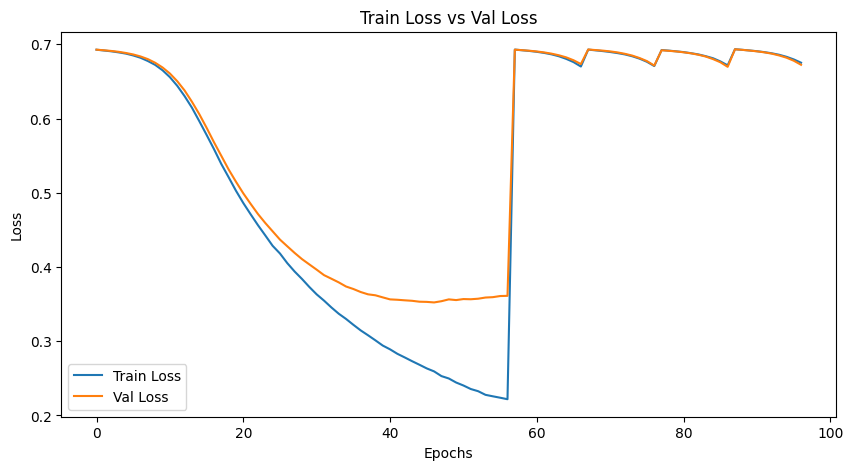

In [41]:
# Graficar Train Loss vs Val Loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train Loss vs Val Loss')
plt.legend()
plt.show()

## NODE_GAM

In [42]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import torch
import os
import joblib
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Definir una ruta para guardar los mejores modelos
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\node_gam\\inferior\\bal\\scaler_pca_bal")
os.makedirs(best_model_path, exist_ok=True)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train.shape[0] + X_test.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_df = pd.DataFrame(X_train.cpu().numpy())
X_test_df = pd.DataFrame(X_test.cpu().numpy())

preprocessor.fit(X_train_df, y_train.cpu().numpy())
X_train_trans = preprocessor.transform(X_train_df)
X_test_trans = preprocessor.transform(X_test_df)

# Convertir a tensores de PyTorch y mover a la GPU
X_train_trans = torch.tensor(X_train_trans, dtype=torch.float32).to(device)
X_test_trans = torch.tensor(X_test_trans, dtype=torch.float32).to(device)

# Definir los mejores hiperparámetros encontrados
# Definir los mejores hiperparámetros encontrados
best_params = {
    'output_dropout': 0.3,
    'num_trees': 300,
    'num_layers': 2,
    'lr_warmup_steps': 200,
    'lr_decay_steps': 500,
    'lr': 0.001,
    'last_dropout': 0.3,
    'early_stopping_steps': 500,
    'depth': 3
}



# Crear un modelo NodeGAMClassifier con los mejores hiperparámetros
def create_model(params):
    return NodeGAMClassifier(
        in_features=X_train_df.shape[1],
        cat_features=None,
        arch='GAMAtt',
        batch_size=32,
        device=device,
        objective='error_rate',
        name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
        **params
    )

# Inicializar listas para almacenar métricas
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Implementar K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
best_overall_f1 = -1
best_model_fold = None

for fold, (train_index, val_index) in enumerate(kf.split(X_train_trans)):
    print(f"Fold {fold + 1}")
    X_train_fold, X_val_fold = X_train_trans[train_index], X_train_trans[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    model = create_model(best_params)
    
    # Entrenamiento
    print(f"Entrenando fold {fold + 1} con los siguientes parámetros: {best_params}")
    model.fit(pd.DataFrame(X_train_fold.cpu().numpy()), y_train_fold.cpu().numpy())
    print("Entrenamiento completado.")
    
    # Validación
    y_val_pred = model.predict(pd.DataFrame(X_val_fold.cpu().numpy()))
    y_val_pred_classes = (torch.sigmoid(torch.tensor(y_val_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas
    val_accuracy = accuracy_score(y_val_fold.cpu().numpy(), y_val_pred_classes) * 100
    f1 = f1_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    precision = precision_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    recall = recall_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100

    val_accuracies.append(val_accuracy)
    f1s.append(f1)
    precisions.append(precision)
    recalls.append(recall)

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    y_test_pred = model.predict(pd.DataFrame(X_test_trans.cpu().numpy()))
    y_test_pred_classes = (torch.sigmoid(torch.tensor(y_test_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas para el conjunto de prueba
    accuracy_test = accuracy_score(y_test.cpu().numpy(), y_test_pred_classes) * 100
    f1_test = f1_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    precision_test = precision_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    recall_test = recall_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Fold {fold + 1} val accuracy: {val_accuracy}%, F1-score: {f1}%, Test accuracy: {accuracy_test}%, Test F1-score: {f1_test}%")

    # Guardar el mejor modelo basado en F1-score
    if f1 > best_overall_f1:
        best_overall_f1 = f1
        best_model_fold = fold + 1

# Guardar el mejor modelo basado en F1-score en el conjunto completo
if best_model_fold is not None:
    model_path = os.path.join(best_model_path, f"best_model_fold_{best_model_fold}.pth")
    best_model = create_model(best_params)
    best_model.fit(pd.DataFrame(X_train_trans.cpu().numpy()), y_train.cpu().numpy())
    joblib.dump(best_model, model_path)
    print(f"Mejor modelo guardado en: {model_path}")


Using device: cuda
Fold 1
Entrenando fold 1 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 300, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 3}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (536) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (350). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.7295	0.3962
200	0.3913	0.2264
300	0.3309	0.1321
400	0.2569	0.1321
500	0.208	0.1132
600	0.0935	0.1132
700	0.2319	0.0943
800	0.2453	0.0566
900	0.0148	0.0566
1000	0.0103	0.0566
1100	0.057	0.0755
1200	0.0104	0.0755
1300	0.118	0.0755
1400	0.1193	0.0755
1500	0.0277	0.0755
1600	0.0404	0.0755
1700	0.0235	0.0755
1800	0.0322	0.0755
1900	0.0811	0.0755
2000	0.1224	0.0755
2100	0.0298	0.0755
2200	0.0235	0.0566
2300	0.0684	0.0566
2400	0.0555	0.0566
2500	0.0136	0.0566
BREAK. There is no improvment for 500 steps
Total training time: 43.9 seconds
Best step:  800
Best Val Metric:  0.05660377358490566
Load the best checkpoint.
Entrenamiento completado.
Fold 1 val accuracy: 89.77272727272727%, F1-score: 89.77140643161565%, Test accuracy: 90.81632653061224%, Test F1-score: 90.80367282047955%
Fold 2
Entrenando fold 2 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 300, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (350). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6886	0.3396
200	0.4762	0.1698
300	0.5173	0.0943
400	0.2504	0.0566
500	0.1338	0.0377
600	0.2123	0.0943
700	0.0738	0.0755
800	0.0935	0.0755
900	0.0487	0.0755
1000	0.1075	0.0566
1100	0.2128	0.0566
1200	0.0307	0.0566
1300	0.078	0.0566
1400	0.0233	0.0566
1500	0.2174	0.0566
1600	0.156	0.0566
1700	0.0416	0.0566
1800	0.185	0.0566
1900	0.06	0.0755
2000	0.0092	0.0566
2100	0.0223	0.0566
2200	0.1297	0.0566
2300	0.0642	0.0566
2400	0.1626	0.0566
2500	0.0221	0.0566
BREAK. There is no improvment for 500 steps
Total training time: 43.0 seconds
Best step:  500
Best Val Metric:  0.03773584905660377
Load the best checkpoint.
Entrenamiento completado.
Fold 2 val accuracy: 92.04545454545455%, F1-score: 92.03619909502262%, Test accuracy: 88.77551020408163%, Test F1-score: 88.76004455836389%
Fold 3
Entrenando fold 3 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 300, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 

...

Steps	Train Err	Val Metric (error_rate)
100	0.6553	0.283
200	0.4415	0.1321
300	0.1919	0.0943
400	0.4429	0.0755
500	0.0632	0.1132
600	0.11	0.1132
700	0.0224	0.0566
800	0.0902	0.0943
900	0.0125	0.0755
1000	0.067	0.0566
1100	0.0735	0.1132
1200	0.1426	0.1132
1300	0.0636	0.1321
1400	0.0343	0.1321
1500	0.013	0.1132
1600	0.0771	0.1132
1700	0.0051	0.1132
1800	0.0229	0.1509
1900	0.0403	0.1321
2000	0.0091	0.1321
2100	0.0302	0.1321
2200	0.0266	0.1509
2300	0.0215	0.1321
2400	0.0469	0.1509
2500	0.0094	0.1321
BREAK. There is no improvment for 500 steps
Total training time: 42.9 seconds
Best step:  700
Best Val Metric:  0.05660377358490566
Load the best checkpoint.
Entrenamiento completado.
Fold 4 val accuracy: 93.10344827586206%, F1-score: 93.13660477453581%, Test accuracy: 92.85714285714286%, Test F1-score: 92.86542836052486%
Fold 5
Entrenando fold 5 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 300, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (351). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.7706	0.2642
200	0.3726	0.0755
300	0.3739	0.0943
400	0.1567	0.1132
500	0.2289	0.1132
600	0.1499	0.0943
700	0.2357	0.1132
800	0.0127	0.0943
900	0.1277	0.0943
1000	0.1104	0.0943
1100	0.0852	0.0943
1200	0.3413	0.0943
1300	0.1306	0.0943
1400	0.0511	0.0943
1500	0.0501	0.0943
1600	0.0142	0.0943
1700	0.4993	0.0943
1800	0.0091	0.0943
1900	0.0325	0.0943
2000	0.0202	0.0943
2100	0.2527	0.0943
2200	0.1373	0.0943
2300	0.2944	0.0943
2400	0.2031	0.0943
2500	0.1197	0.0943
BREAK. There is no improvment for 500 steps
Total training time: 43.9 seconds
Best step:  200
Best Val Metric:  0.07547169811320754
Load the best checkpoint.
Entrenamiento completado.
Fold 5 val accuracy: 86.20689655172413%, F1-score: 86.10742705570293%, Test accuracy: 82.6530612244898%, Test F1-score: 82.70224397645228%


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6896	0.3333
200	0.5108	0.1212
300	0.236	0.0606
400	0.1247	0.0606
500	0.1372	0.0606
600	0.2713	0.0455
700	0.0943	0.0303
800	0.3965	0.0455
900	0.1064	0.0303
1000	0.1016	0.0303
1100	0.1065	0.0303
1200	0.0561	0.0455
1300	0.1252	0.0455
1400	0.0325	0.0455
1500	0.203	0.0455
1600	0.0932	0.0455
1700	0.0525	0.0606
1800	0.1506	0.0606
1900	0.1517	0.0606
2000	0.0761	0.0455
2100	0.074	0.0606
2200	0.2991	0.0455
2300	0.0797	0.0303
2400	0.0626	0.0303
2500	0.1317	0.0303
BREAK. There is no improvment for 500 steps
Total training time: 43.6 seconds
Best step:  700
Best Val Metric:  0.030303030303030304
Load the best checkpoint.
Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\node_gam\inferior\bal\scaler_pca_bal\best_model_fold_4.pth


In [43]:
# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

# Métricas de validación cruzada
accuracy_mean_std = format_metric(np.mean(val_accuracies), np.std(val_accuracies))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Métricas del conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 89.27 ± 3.11%
F1-score: 89.28 ± 3.11%
Precisión (Precision): 89.80 ± 2.81%
Recall: 89.27 ± 3.11%

Métricas del Conjunto de Prueba:
Precisión: 89.39 ± 3.63%
F1-score: 89.40 ± 3.61%
Precisión (Precision): 89.51 ± 3.59%
Recall: 89.39 ± 3.63%


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score
import torch
import os
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train_unbalance.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_resampled_df = pd.DataFrame(X_train_unbalance.numpy())
preprocessor.fit(X_train_resampled_df, Y_train_unbalance.numpy())
X_train_resampled_trans = preprocessor.transform(X_train_resampled_df)
X_test_df = pd.DataFrame(X_test_unbalance.numpy())
X_test_trans = preprocessor.transform(X_test_df)

# Definir el espacio de hiperparámetros reducido
param_distributions = {
    'num_trees': [100, 200, 300],
    'num_layers': [2, 3],
    'depth': [3, 4],
    'lr': [1e-4, 1e-3],
    'output_dropout': [0.2, 0.3],
    'last_dropout': [0.3, 0.4],
    'lr_warmup_steps': [200],
    'lr_decay_steps': [500],
    'early_stopping_steps': [500]
}

# Crear un wrapper para el modelo NodeGAMClassifier
class NodeGAMWrapper:
    def __init__(self, **params):
        self.params = params
        self.model = self.create_model(params)

    def create_model(self, params):
        return NodeGAMClassifier(
            in_features=X_train_resampled_df.shape[1],
            cat_features=None,
            arch='GAMAtt',
            batch_size=32,
            device=device,
            objective='error_rate',
            name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
            **params
        )

    def fit(self, X, y):
        print(f"Entrenando con los siguientes parámetros: {self.params}")
        self.model.fit(pd.DataFrame(X), y)
        print("Entrenamiento completado.")
        return self

    def predict(self, X):
        y_pred_prob = torch.sigmoid(torch.tensor(self.model.predict(pd.DataFrame(X)))).numpy()
        return (y_pred_prob > 0.5).astype(int)

    def predict_proba(self, X):
        y_pred_prob = torch.sigmoid(torch.tensor(self.model.predict(pd.DataFrame(X)))).numpy()
        return np.hstack([(1 - y_pred_prob).reshape(-1, 1), y_pred_prob.reshape(-1, 1)])

    def score(self, X, y):
        y_pred = self.predict(X)
        return accuracy_score(y, y_pred)

    def get_params(self, deep=False):
        return self.params

    def set_params(self, **params):
        self.params.update(params)
        self.model = self.create_model(self.params)
        return self

# Implementar RandomizedSearchCV con 5 folds de cross-validation
nodegam_model = NodeGAMWrapper()
scorings = ['f1']

for scoring in scorings:
    random_search = RandomizedSearchCV(
        estimator=nodegam_model,
        param_distributions=param_distributions,
        n_iter=10,  # Número reducido de combinaciones aleatorias a probar
        cv=5,  # Número de folds de cross-validation
        scoring=scoring,
        verbose=2,
        n_jobs=-1
    )                              

    # Entrenar el modelo con búsqueda de hiperparámetros
    random_search.fit(X_train_resampled_trans, Y_train_unbalance.numpy())

    # Mejor combinación de hiperparámetros
    print(f"Best parameters found for {scoring}: {random_search.best_params_}")
    print(f"Best cross-validation {scoring}: {random_search.best_score_}")

    # Guardar el mejor modelo completo
    best_model = random_search.best_estimator_
    model_path = f"D:\\tesis\\Modelo_extraccion_no\\node-gam\\best_nodegam_model_scapcabal_{scoring}.pkl"
    joblib.dump(best_model, model_path)

Using device: cuda
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Entrenando con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 100, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.4, 'early_stopping_steps': 500, 'depth': 3}


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6945	0.3939
200	0.676	0.2273
300	0.5074	0.1364
400	0.3719	0.1061
500	0.163	0.1212
600	0.2544	0.1364
700	0.1532	0.1212
800	0.1458	0.1212
900	0.2594	0.1212
1000	0.2379	0.1212
1100	0.3965	0.1212
1200	0.3103	0.1061
1300	0.0683	0.0909
1400	0.2033	0.1364
1500	0.1377	0.1061
1600	0.1288	0.1212
1700	0.2286	0.1212
1800	0.1508	0.0758
1900	0.1067	0.0758
2000	0.1006	0.1061
2100	0.1142	0.0909
2200	0.3433	0.1061
2300	0.0802	0.1061
2400	0.2947	0.0758
2500	0.1099	0.0758
BREAK. There is no improvment for 500 steps
Total training time: 43.7 seconds
Best step:  1800
Best Val Metric:  0.07575757575757576
Load the best checkpoint.
Entrenamiento completado.
Best parameters found for f1: {'output_dropout': 0.3, 'num_trees': 100, 'num_layers': 2, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.4, 'early_stopping_steps': 500, 'depth': 3}
Best cross-validation f1: 0.8948930818810338


# Balanced Robustscaler

In [44]:
#CArgar tensores con el data set
# Cargar el dataset balanceado de entrenamiento
X_train, y_train = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac inf\\Train_inferior.pkl')

# Cargar el conjunto de prueba
X_test, y_test = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac inf\\Test_inferior.pkl')

In [45]:
smote = SMOTE(random_state=42)
X_train_resampled_s, y_train_resampled_s = smote.fit_resample(X_train, y_train)

In [46]:
scaler = RobustScaler().fit(X_train)

X_train_scaler = scaler.transform(X_train_resampled_s)
X_test_scaler = scaler.transform(X_test)

In [47]:
X_train_unbalance= torch.tensor(X_train_scaler, dtype=torch.float32)
Y_train_unbalance= torch.tensor(y_train_resampled_s.values, dtype=torch.float32)
X_test_unbalance= torch.tensor(X_test_scaler, dtype=torch.float32)
Y_test_unbalance= torch.tensor(y_test.values, dtype=torch.float32)


## KAN

In [48]:
input_dim = X_train_unbalance.shape[1]
hidden_layers = [128, 64, 32, 16] # Reducción en el número de capas
output_dim = 1

   
def create_model():
    model = KAN([input_dim] + hidden_layers + [output_dim])
    return model

In [49]:
# Configuración inicial
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Ruta para guardar el mejor modelo
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\extrac inf\\Roscaler_bal\\", 'best_model.pth')

pos_weight = torch.tensor([len(y_train[y_train == 0]) / len(y_train[y_train == 1])]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
num_epochs = 200
batch_size = 32
patience = 10  # Paciencia para EarlyStopping

best_overall_f1 = -1
best_val_loss = float('inf')

# Realizar la validación cruzada
fold_no = 1
for train_index, val_index in kf.split(X_train):
    print(f'Fold {fold_no}')

    # Recrear el modelo y el optimizador para asegurarse de que los pesos se reinician
    model = create_model().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

    # División de los datos en entrenamiento y validación
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    train_dataset = TensorDataset(X_train_fold, y_train_fold)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    val_dataset = TensorDataset(X_val_fold, y_val_fold)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0
        epoch_train_accuracy = 0
        with tqdm(train_loader) as pbar:
            for inputs, labels in pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                epoch_train_loss += loss.item()
                accuracy = ((outputs > 0.5) == labels).float().mean()
                epoch_train_accuracy += accuracy.item()
                pbar.set_postfix(loss=loss.item(), accuracy=accuracy.item(), lr=optimizer.param_groups[0]['lr'])

        train_losses.append(epoch_train_loss / len(train_loader))
        train_accuracies.append(epoch_train_accuracy / len(train_loader))

        model.eval()
        val_loss = 0
        val_accuracy = 0
        all_labels = []
        all_outputs = []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze()
                val_loss += criterion(outputs, labels).item()
                val_accuracy += ((outputs > 0.5) == labels).float().mean().item()
                all_labels.extend(labels.cpu().numpy())
                all_outputs.extend(torch.sigmoid(outputs).cpu().numpy())

        val_loss /= len(val_loader)
        val_accuracy /= len(val_loader)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        y_pred_classes = np.array(all_outputs) > 0.5
        accuracy = accuracy_score(all_labels, y_pred_classes) * 100
        f1 = f1_score(all_labels, y_pred_classes, average='weighted') * 100
        precision = precision_score(all_labels, y_pred_classes, average='weighted') * 100
        recall = recall_score(all_labels, y_pred_classes, average='weighted') * 100

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        accuracys.append(accuracy)

        # Guardar el mejor modelo basado en la pérdida de validación
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_model_path)
            print(f'Mejor modelo guardado en: {best_model_path} con val_loss: {best_val_loss}')
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        scheduler.step(val_loss)
        print(f"Epoch {epoch + 1}, Train Loss: {epoch_train_loss / len(train_loader)}, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}")

        if epochs_no_improve == patience:
            print(f'Early stopping triggered after {epoch + 1} epochs.')
            break

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

    test_loss = 0
    test_accuracy = 0
    all_labels_test = []
    all_outputs_test = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            if outputs.dim() == 0:  # Si el output es un escalar
                outputs = outputs.unsqueeze(0)  # Añade una dimensión para que coincida con labels
            elif outputs.dim() == 1 and labels.dim() == 2:
                outputs = outputs.unsqueeze(1)  # Ajusta la salida para que coincida con labels
            test_loss += criterion(outputs, labels).item()
            test_accuracy += ((outputs > 0.5) == labels).float().mean().item()
            all_labels_test.extend(labels.cpu().numpy())
            all_outputs_test.extend(torch.sigmoid(outputs).cpu().numpy())

    test_loss /= len(test_loader)
    test_accuracy /= len(test_loader)

    # Calcular las métricas para el conjunto de prueba
    y_pred_classes_test = np.array(all_outputs_test) > 0.5
    accuracy_test = accuracy_score(all_labels_test, y_pred_classes_test) * 100
    f1_test = f1_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    precision_test = precision_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    recall_test = recall_score(all_labels_test, y_pred_classes_test, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Test metrics for fold {fold_no}: Accuracy: {accuracy_test}%, F1-score: {f1_test}%, Precision: {precision_test}%, Recall: {recall_test}%")




Fold 1


100%|██████████| 11/11 [00:00<00:00, 36.72it/s, accuracy=0.567, loss=0.692, lr=0.0001]


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\extrac inf\Roscaler_bal\best_model.pth con val_loss: 0.6928304235140482
Epoch 1, Train Loss: 0.6928626298904419, Val Loss: 0.6928304235140482, Val Accuracy: 0.4861111144224803


100%|██████████| 11/11 [00:00<00:00, 51.15it/s, accuracy=0.467, loss=0.692, lr=0.0001]


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\extrac inf\Roscaler_bal\best_model.pth con val_loss: 0.6922591725985209
Epoch 2, Train Loss: 0.6922173770991239, Val Loss: 0.6922591725985209, Val Accuracy: 0.4861111144224803


...

Epoch 8, Train Loss: 0.6853417645801197, Val Loss: 0.6838567058245341, Val Accuracy: 0.4701086978117625


100%|██████████| 11/11 [00:00<00:00, 41.33it/s, accuracy=0.613, loss=0.679, lr=0.0001]


Epoch 9, Train Loss: 0.6818508939309553, Val Loss: 0.6795194745063782, Val Accuracy: 0.4701086978117625


100%|██████████| 11/11 [00:00<00:00, 48.63it/s, accuracy=0.484, loss=0.674, lr=0.0001]


Epoch 10, Train Loss: 0.67677626284686, Val Loss: 0.673378606637319, Val Accuracy: 0.4701086978117625
Early stopping triggered after 10 epochs.
Test metrics for fold 1: Accuracy: 84.6938775510204%, F1-score: 84.67278803413258%, Precision: 84.66958211856172%, Recall: 84.6938775510204%


In [50]:
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'
# Calcular las métricas medias y desviaciones estándar de validación cruzada
accuracy_mean_std = format_metric(np.mean(accuracys), np.std(accuracys))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Calcular las métricas medias y desviaciones estándar para el conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 78.08 ± 11.82%
F1-score: 76.72 ± 15.26%
Precisión (Precision): 79.33 ± 13.75%
Recall: 78.08 ± 11.82%

Métricas del Conjunto de Prueba:
Precisión: 81.63 ± 5.59%
F1-score: 81.43 ± 5.89%
Precisión (Precision): 83.38 ± 2.91%
Recall: 81.63 ± 5.59%


## NODE_GAM

In [51]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import torch
import os
import joblib
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Definir una ruta para guardar los mejores modelos
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\node_gam\\inferior\\bal\\roscaler")
os.makedirs(best_model_path, exist_ok=True)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train.shape[0] + X_test.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_df = pd.DataFrame(X_train.cpu().numpy())
X_test_df = pd.DataFrame(X_test.cpu().numpy())

preprocessor.fit(X_train_df, y_train.cpu().numpy())
X_train_trans = preprocessor.transform(X_train_df)
X_test_trans = preprocessor.transform(X_test_df)

# Convertir a tensores de PyTorch y mover a la GPU
X_train_trans = torch.tensor(X_train_trans, dtype=torch.float32).to(device)
X_test_trans = torch.tensor(X_test_trans, dtype=torch.float32).to(device)

# Definir los mejores hiperparámetros encontrados
best_params = {
    'output_dropout': 0.3,
    'num_trees': 300,
    'num_layers': 3,
    'lr_warmup_steps': 200,
    'lr_decay_steps': 500,
    'lr': 0.001,
    'last_dropout': 0.3,
    'early_stopping_steps': 500,
    'depth': 3
}

# Crear un modelo NodeGAMClassifier con los mejores hiperparámetros
def create_model(params):
    return NodeGAMClassifier(
        in_features=X_train_df.shape[1],
        cat_features=None,
        arch='GAMAtt',
        batch_size=32,
        device=device,
        objective='error_rate',
        name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
        **params
    )

# Inicializar listas para almacenar métricas
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Implementar K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
best_overall_f1 = -1
best_model_fold = None

for fold, (train_index, val_index) in enumerate(kf.split(X_train_trans)):
    print(f"Fold {fold + 1}")
    X_train_fold, X_val_fold = X_train_trans[train_index], X_train_trans[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    model = create_model(best_params)
    
    # Entrenamiento
    print(f"Entrenando fold {fold + 1} con los siguientes parámetros: {best_params}")
    model.fit(pd.DataFrame(X_train_fold.cpu().numpy()), y_train_fold.cpu().numpy())
    print("Entrenamiento completado.")
    
    # Validación
    y_val_pred = model.predict(pd.DataFrame(X_val_fold.cpu().numpy()))
    y_val_pred_classes = (torch.sigmoid(torch.tensor(y_val_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas
    val_accuracy = accuracy_score(y_val_fold.cpu().numpy(), y_val_pred_classes) * 100
    f1 = f1_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    precision = precision_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    recall = recall_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100

    val_accuracies.append(val_accuracy)
    f1s.append(f1)
    precisions.append(precision)
    recalls.append(recall)

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    y_test_pred = model.predict(pd.DataFrame(X_test_trans.cpu().numpy()))
    y_test_pred_classes = (torch.sigmoid(torch.tensor(y_test_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas para el conjunto de prueba
    accuracy_test = accuracy_score(y_test.cpu().numpy(), y_test_pred_classes) * 100
    f1_test = f1_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    precision_test = precision_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    recall_test = recall_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Fold {fold + 1} val accuracy: {val_accuracy}%, F1-score: {f1}%, Test accuracy: {accuracy_test}%, Test F1-score: {f1_test}%")

    # Guardar el mejor modelo basado en F1-score
    if f1 > best_overall_f1:
        best_overall_f1 = f1
        best_model_fold = fold + 1

# Guardar el mejor modelo basado en F1-score en el conjunto completo
if best_model_fold is not None:
    model_path = os.path.join(best_model_path, f"best_model_fold_{best_model_fold}.pth")
    best_model = create_model(best_params)
    best_model.fit(pd.DataFrame(X_train_trans.cpu().numpy()), y_train.cpu().numpy())
    joblib.dump(best_model, model_path)
    print(f"Mejor modelo guardado en: {model_path}")


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (536) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (350). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Using device: cuda
Fold 1
Entrenando fold 1 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 300, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 3}
Steps	Train Err	Val Metric (error_rate)
100	0.6012	0.1698
200	0.247	0.1509
300	0.2087	0.1321
400	0.0965	0.1698
500	0.1033	0.1509
600	0.0802	0.1509
700	0.0904	0.1321
800	0.0689	0.1509
900	0.1025	0.0943
1000	0.0007	0.0943
1100	0.0136	0.0755
1200	0.0209	0.0943
1300	0.0025	0.0755
1400	0.0102	0.0755
1500	0.0308	0.0566
1600	0.0115	0.0566
1700	0.0069	0.0566
1800	0.0047	0.0377
1900	0.0843	0.0377
2000	0.0005	0.0377
2100	0.0147	0.0377
2200	0.0061	0.0377
2300	0.0314	0.0377
2400	0.0002	0.0377
2500	0.0102	0.0377
BREAK. There is no improvment for 500 steps
Total training time: 64.1 seconds
Best step:  1800
Best Val Metric:  0.03773584905660377
Load the best checkpoint.
Entrenamiento completado.
Fold 1 val accuracy: 93.18181818181817%, F1-score: 93.

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (350). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.7278	0.2264
200	0.275	0.1509
300	0.5023	0.0943
400	0.0799	0.0943
500	0.0418	0.0943
600	0.0535	0.0755
700	0.0057	0.0755
800	0.1998	0.0566
900	0.024	0.0755
1000	0.008	0.0566
1100	0.0014	0.0755
1200	0.0345	0.0755
1300	0.0504	0.0755
1400	0.0113	0.0566
1500	0.0316	0.0943
1600	0.0383	0.0566
1700	0.0037	0.0566
1800	0.0292	0.0566
1900	0.0063	0.0566
2000	0.0163	0.0755
2100	0.032	0.0566
2200	0.0298	0.0566
2300	0.0072	0.0566
2400	0.0001	0.0566
2500	0.0414	0.0755
BREAK. There is no improvment for 500 steps
Total training time: 63.7 seconds
Best step:  800
Best Val Metric:  0.05660377358490566
Load the best checkpoint.
Entrenamiento completado.
Fold 2 val accuracy: 86.36363636363636%, F1-score: 86.25%, Test accuracy: 91.83673469387756%, Test F1-score: 91.85391328248471%
Fold 3
Entrenando fold 3 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 300, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropo

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (350). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


...

Steps	Train Err	Val Metric (error_rate)
100	0.5981	0.0943
200	0.4889	0.0755
300	0.1158	0.0566
400	0.1556	0.0566
500	0.0606	0.0943
600	0.0381	0.0755
700	0.0746	0.0943
800	0.0185	0.0943
900	0.0911	0.0943
1000	0.0253	0.0943
1100	0.0148	0.0755
1200	0.0022	0.0755
1300	0.0014	0.0943
1400	0.0895	0.0755
1500	0.0001	0.0755
1600	0.0238	0.0943
1700	0.0061	0.0755
1800	0.0011	0.0755
1900	0.0726	0.0943
2000	0.065	0.0755
2100	0.0086	0.0755
2200	0.0044	0.0755
2300	0.002	0.0755
2400	0.0029	0.0755
2500	0.0114	0.0755
BREAK. There is no improvment for 500 steps
Total training time: 63.1 seconds
Best step:  300
Best Val Metric:  0.05660377358490566
Load the best checkpoint.
Entrenamiento completado.
Fold 4 val accuracy: 91.95402298850574%, F1-score: 91.96702658771623%, Test accuracy: 88.77551020408163%, Test F1-score: 88.76004455836389%
Fold 5
Entrenando fold 5 con los siguientes parámetros: {'output_dropout': 0.3, 'num_trees': 300, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.00

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (351). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.634	0.1132
200	0.3089	0.0755
300	0.1604	0.0755
400	0.3736	0.0566
500	0.1228	0.0566
600	0.0873	0.0377
700	0.0229	0.0189
800	0.012	0.0377
900	0.0237	0.0377
1000	0.0195	0.0377
1100	0.0743	0.0377
1200	0.114	0.0377
1300	0.0835	0.0377
1400	0.003	0.0377
1500	0.0008	0.0377
1600	0.0098	0.0377
1700	0.0218	0.0377
1800	0.0049	0.0377
1900	0.0169	0.0377
2000	0.1333	0.0377
2100	0.0052	0.0377
2200	0.0307	0.0377
2300	0.0055	0.0377
2400	0.0235	0.0377
2500	0.0035	0.0377
BREAK. There is no improvment for 500 steps
Total training time: 62.7 seconds
Best step:  700
Best Val Metric:  0.018867924528301886
Load the best checkpoint.
Entrenamiento completado.
Fold 5 val accuracy: 95.40229885057471%, F1-score: 95.39620433685599%, Test accuracy: 91.83673469387756%, Test F1-score: 91.85391328248471%


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.5986	0.197
200	0.3952	0.1364
300	0.1756	0.0606
400	0.1719	0.0758
500	0.1444	0.0455
600	0.0313	0.0606
700	0.0594	0.0606
800	0.0345	0.0909
900	0.0235	0.0758
1000	0.0592	0.0606
1100	0.0245	0.0758
1200	0.014	0.0909
1300	0.0235	0.0758
1400	0.0465	0.0909
1500	0.0168	0.0909
1600	0.0093	0.0909
1700	0.0099	0.0909
1800	0.0518	0.0909
1900	0.0475	0.0758
2000	0.0417	0.0758
2100	0.0027	0.0758
2200	0.0113	0.0758
2300	0.0187	0.0758
2400	0.0034	0.0758
2500	0.0083	0.0758
BREAK. There is no improvment for 500 steps
Total training time: 64.6 seconds
Best step:  500
Best Val Metric:  0.045454545454545456
Load the best checkpoint.
Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\node_gam\inferior\bal\roscaler\best_model_fold_5.pth


In [52]:
# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

# Métricas de validación cruzada
accuracy_mean_std = format_metric(np.mean(val_accuracies), np.std(val_accuracies))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Métricas del conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 91.11 ± 3.23%
F1-score: 91.09 ± 3.25%
Precisión (Precision): 91.49 ± 2.92%
Recall: 91.11 ± 3.23%

Métricas del Conjunto de Prueba:
Precisión: 91.43 ± 1.38%
F1-score: 91.44 ± 1.40%
Precisión (Precision): 91.51 ± 1.45%
Recall: 91.43 ± 1.38%


# BALANCED PCA_roSCALER

In [53]:
#CArgar tensores con el data set
# Cargar el dataset balanceado de entrenamiento
X_train, y_train = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac inf\\Train_inferior.pkl')

# Cargar el conjunto de prueba
X_test, y_test = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac inf\\Test_inferior.pkl')

In [54]:
smote = SMOTE(random_state=42)
X_train_resampled_s, y_train_resampled_s = smote.fit_resample(X_train, y_train)

In [55]:
scaler = RobustScaler().fit(X_train)

X_train_scaler = scaler.transform(X_train_resampled_s)
X_test_scaler = scaler.transform(X_test)

In [56]:
from sklearn import decomposition

pca = decomposition.PCA(n_components=0.96,svd_solver='full',tol=1e-4)
pca.fit(X_train_scaler)
X_train_pca= pca.transform(X_train_scaler)
X_test_pca=pca.transform(X_test_scaler)

In [57]:
X_train_unbalance= torch.tensor(X_train_pca, dtype=torch.float32)
Y_train_unbalance= torch.tensor(y_train_resampled_s.values, dtype=torch.float32)
X_test_unbalance= torch.tensor(X_test_pca, dtype=torch.float32)
Y_test_unbalance= torch.tensor(y_test.values, dtype=torch.float32)

## KAN

In [58]:
input_dim = X_train_unbalance.shape[1]
hidden_layers = [128, 64, 32, 16] # Reducción en el número de capas
output_dim = 1

   
def create_model():
    model = KAN([input_dim] + hidden_layers + [output_dim])
    return model

In [59]:
# Configuración inicial
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Ruta para guardar el mejor modelo
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\extrac inf\\pca_roscaler_bal\\", 'best_model.pth')

pos_weight = torch.tensor([len(y_train[y_train == 0]) / len(y_train[y_train == 1])]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
num_epochs = 200
batch_size = 32
patience = 10  # Paciencia para EarlyStopping

best_overall_f1 = -1
best_val_loss = float('inf')

# Realizar la validación cruzada
fold_no = 1
for train_index, val_index in kf.split(X_train):
    print(f'Fold {fold_no}')

    # Recrear el modelo y el optimizador para asegurarse de que los pesos se reinician
    model = create_model().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

    # División de los datos en entrenamiento y validación
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    train_dataset = TensorDataset(X_train_fold, y_train_fold)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    val_dataset = TensorDataset(X_val_fold, y_val_fold)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0
        epoch_train_accuracy = 0
        with tqdm(train_loader) as pbar:
            for inputs, labels in pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                epoch_train_loss += loss.item()
                accuracy = ((outputs > 0.5) == labels).float().mean()
                epoch_train_accuracy += accuracy.item()
                pbar.set_postfix(loss=loss.item(), accuracy=accuracy.item(), lr=optimizer.param_groups[0]['lr'])

        train_losses.append(epoch_train_loss / len(train_loader))
        train_accuracies.append(epoch_train_accuracy / len(train_loader))

        model.eval()
        val_loss = 0
        val_accuracy = 0
        all_labels = []
        all_outputs = []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze()
                val_loss += criterion(outputs, labels).item()
                val_accuracy += ((outputs > 0.5) == labels).float().mean().item()
                all_labels.extend(labels.cpu().numpy())
                all_outputs.extend(torch.sigmoid(outputs).cpu().numpy())

        val_loss /= len(val_loader)
        val_accuracy /= len(val_loader)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        y_pred_classes = np.array(all_outputs) > 0.5
        accuracy = accuracy_score(all_labels, y_pred_classes) * 100
        f1 = f1_score(all_labels, y_pred_classes, average='weighted') * 100
        precision = precision_score(all_labels, y_pred_classes, average='weighted') * 100
        recall = recall_score(all_labels, y_pred_classes, average='weighted') * 100

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        accuracys.append(accuracy)

        # Guardar el mejor modelo basado en la pérdida de validación
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_model_path)
            print(f'Mejor modelo guardado en: {best_model_path} con val_loss: {best_val_loss}')
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        scheduler.step(val_loss)
        print(f"Epoch {epoch + 1}, Train Loss: {epoch_train_loss / len(train_loader)}, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}")

        if epochs_no_improve == patience:
            print(f'Early stopping triggered after {epoch + 1} epochs.')
            break

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

    test_loss = 0
    test_accuracy = 0
    all_labels_test = []
    all_outputs_test = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            if outputs.dim() == 0:  # Si el output es un escalar
                outputs = outputs.unsqueeze(0)  # Añade una dimensión para que coincida con labels
            elif outputs.dim() == 1 and labels.dim() == 2:
                outputs = outputs.unsqueeze(1)  # Ajusta la salida para que coincida con labels
            test_loss += criterion(outputs, labels).item()
            test_accuracy += ((outputs > 0.5) == labels).float().mean().item()
            all_labels_test.extend(labels.cpu().numpy())
            all_outputs_test.extend(torch.sigmoid(outputs).cpu().numpy())

    test_loss /= len(test_loader)
    test_accuracy /= len(test_loader)

    # Calcular las métricas para el conjunto de prueba
    y_pred_classes_test = np.array(all_outputs_test) > 0.5
    accuracy_test = accuracy_score(all_labels_test, y_pred_classes_test) * 100
    f1_test = f1_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    precision_test = precision_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    recall_test = recall_score(all_labels_test, y_pred_classes_test, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Test metrics for fold {fold_no}: Accuracy: {accuracy_test}%, F1-score: {f1_test}%, Precision: {precision_test}%, Recall: {recall_test}%")
   

Fold 1


100%|██████████| 11/11 [00:00<00:00, 49.09it/s, accuracy=0.467, loss=0.693, lr=0.0001]


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\extrac inf\pca_roscaler_bal\best_model.pth con val_loss: 0.6928890347480774
Epoch 1, Train Loss: 0.6932958635416898, Val Loss: 0.6928890347480774, Val Accuracy: 0.4861111144224803


100%|██████████| 11/11 [00:00<00:00, 33.63it/s, accuracy=0.6, loss=0.693, lr=0.0001] 


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\extrac inf\pca_roscaler_bal\best_model.pth con val_loss: 0.6923498312632242
Epoch 2, Train Loss: 0.6926847479560159, Val Loss: 0.6923498312632242, Val Accuracy: 0.4861111144224803


...

Epoch 8, Train Loss: 0.6842826984145425, Val Loss: 0.6828467051188151, Val Accuracy: 0.4701086978117625


100%|██████████| 11/11 [00:00<00:00, 44.54it/s, accuracy=0.419, loss=0.673, lr=0.0001]


Epoch 9, Train Loss: 0.681188550862399, Val Loss: 0.6791019241015116, Val Accuracy: 0.4701086978117625


100%|██████████| 11/11 [00:00<00:00, 52.69it/s, accuracy=0.516, loss=0.677, lr=0.0001]


Epoch 10, Train Loss: 0.6770910241387107, Val Loss: 0.6742343505223592, Val Accuracy: 0.4701086978117625
Early stopping triggered after 10 epochs.
Test metrics for fold 1: Accuracy: 84.6938775510204%, F1-score: 84.26716141001856%, Precision: 86.203231292517%, Recall: 84.6938775510204%


In [60]:
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'
# Calcular las métricas medias y desviaciones estándar de validación cruzada
accuracy_mean_std = format_metric(np.mean(accuracys), np.std(accuracys))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Calcular las métricas medias y desviaciones estándar para el conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 84.80 ± 14.88%
F1-score: 83.37 ± 17.94%
Precisión (Precision): 88.98 ± 9.16%
Recall: 84.80 ± 14.88%

Métricas del Conjunto de Prueba:
Precisión: 80.61 ± 11.99%
F1-score: 79.53 ± 13.52%
Precisión (Precision): 84.11 ± 7.49%
Recall: 80.61 ± 11.99%


## NODE_GAM

In [61]:

import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import torch
import os
import joblib
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Definir una ruta para guardar los mejores modelos
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\node_gam\\inferior\\bal\\PCA_roscaler")
os.makedirs(best_model_path, exist_ok=True)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train.shape[0] + X_test.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_df = pd.DataFrame(X_train.cpu().numpy())
X_test_df = pd.DataFrame(X_test.cpu().numpy())

preprocessor.fit(X_train_df, y_train.cpu().numpy())
X_train_trans = preprocessor.transform(X_train_df)
X_test_trans = preprocessor.transform(X_test_df)

# Convertir a tensores de PyTorch y mover a la GPU
X_train_trans = torch.tensor(X_train_trans, dtype=torch.float32).to(device)
X_test_trans = torch.tensor(X_test_trans, dtype=torch.float32).to(device)

# Definir los mejores hiperparámetros encontrados
best_params = {
    'output_dropout': 0.2,
    'num_trees': 300,
    'num_layers': 3,
    'lr_warmup_steps': 200,
    'lr_decay_steps': 500,
    'lr': 0.0001,
    'last_dropout': 0.3,
    'early_stopping_steps': 500,
    'depth': 4
}

# Crear un modelo NodeGAMClassifier con los mejores hiperparámetros
def create_model(params):
    return NodeGAMClassifier(
        in_features=X_train_df.shape[1],
        cat_features=None,
        arch='GAMAtt',
        batch_size=32,
        device=device,
        objective='error_rate',
        name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
        **params
    )

# Inicializar listas para almacenar métricas
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Implementar K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
best_overall_f1 = -1
best_model_fold = None

for fold, (train_index, val_index) in enumerate(kf.split(X_train_trans)):
    print(f"Fold {fold + 1}")
    X_train_fold, X_val_fold = X_train_trans[train_index], X_train_trans[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    model = create_model(best_params)
    
    # Entrenamiento
    print(f"Entrenando fold {fold + 1} con los siguientes parámetros: {best_params}")
    model.fit(pd.DataFrame(X_train_fold.cpu().numpy()), y_train_fold.cpu().numpy())
    print("Entrenamiento completado.")
    
    # Validación
    y_val_pred = model.predict(pd.DataFrame(X_val_fold.cpu().numpy()))
    y_val_pred_classes = (torch.sigmoid(torch.tensor(y_val_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas
    val_accuracy = accuracy_score(y_val_fold.cpu().numpy(), y_val_pred_classes) * 100
    f1 = f1_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    precision = precision_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    recall = recall_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100

    val_accuracies.append(val_accuracy)
    f1s.append(f1)
    precisions.append(precision)
    recalls.append(recall)

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    y_test_pred = model.predict(pd.DataFrame(X_test_trans.cpu().numpy()))
    y_test_pred_classes = (torch.sigmoid(torch.tensor(y_test_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas para el conjunto de prueba
    accuracy_test = accuracy_score(y_test.cpu().numpy(), y_test_pred_classes) * 100
    f1_test = f1_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    precision_test = precision_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    recall_test = recall_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Fold {fold + 1} val accuracy: {val_accuracy}%, F1-score: {f1}%, Test accuracy: {accuracy_test}%, Test F1-score: {f1_test}%")

    # Guardar el mejor modelo basado en F1-score
    if f1 > best_overall_f1:
        best_overall_f1 = f1
        best_model_fold = fold + 1

# Guardar el mejor modelo basado en F1-score en el conjunto completo
if best_model_fold is not None:
    model_path = os.path.join(best_model_path, f"best_model_fold_{best_model_fold}.pth")
    best_model = create_model(best_params)
    best_model.fit(pd.DataFrame(X_train_trans.cpu().numpy()), y_train.cpu().numpy())
    joblib.dump(best_model, model_path)
    print(f"Mejor modelo guardado en: {model_path}")



c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (536) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (350). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Using device: cuda
Fold 1
Entrenando fold 1 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 300, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 4}
Steps	Train Err	Val Metric (error_rate)
100	0.648	0.283
200	0.6346	0.2453
300	0.5756	0.2075
400	0.639	0.1698
500	0.5236	0.1321
600	0.4646	0.0943
700	0.3932	0.0943
800	0.3433	0.0755
900	0.2622	0.0755
1000	0.4458	0.0943
1100	0.1835	0.1132
1200	0.3188	0.1132
1300	0.3495	0.1132
1400	0.3343	0.1132
1500	0.3849	0.1132
1600	0.0842	0.1132
1700	0.0641	0.1132
1800	0.3461	0.1132
1900	0.1507	0.1132
2000	0.1057	0.1132
2100	0.1243	0.1132
2200	0.3757	0.1321
2300	0.1259	0.1132
2400	0.1158	0.1132
2500	0.077	0.1132
BREAK. There is no improvment for 500 steps
Total training time: 63.3 seconds
Best step:  800
Best Val Metric:  0.07547169811320754
Load the best checkpoint.
Entrenamiento completado.
Fold 1 val accuracy: 86.36363636363636%, F1-score: 86.299

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (350). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.6209	0.434
200	0.6538	0.4151
300	0.6643	0.3962
400	0.6622	0.3585
500	0.5125	0.2264
600	0.5499	0.1321
700	0.3791	0.1132
800	0.4103	0.0755
900	0.2607	0.0943
1000	0.5134	0.0943
1100	0.2351	0.0755
1200	0.2237	0.0755
1300	0.1458	0.0566
1400	0.2773	0.0377
1500	0.2865	0.0566
1600	0.1209	0.0566
1700	0.5971	0.0566
1800	0.1004	0.0566
1900	0.1187	0.0566
2000	0.5911	0.0566
2100	0.058	0.0566
2200	0.2126	0.0566
2300	0.2214	0.0566
2400	0.2483	0.0566
2500	0.1775	0.0566
BREAK. There is no improvment for 500 steps
Total training time: 61.4 seconds
Best step:  1400
Best Val Metric:  0.03773584905660377
Load the best checkpoint.
Entrenamiento completado.
Fold 2 val accuracy: 88.63636363636364%, F1-score: 88.63049095607235%, Test accuracy: 88.77551020408163%, Test F1-score: 88.80733433770442%
Fold 3
Entrenando fold 3 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 300, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (350). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


...

Steps	Train Err	Val Metric (error_rate)
100	0.6313	0.566
200	0.6293	0.4528
300	0.808	0.3962
400	0.5291	0.3208
500	0.4914	0.3208
600	0.5877	0.3019
700	0.4446	0.2453
800	0.3322	0.2264
900	0.3533	0.2453
1000	0.2243	0.2075
1100	0.6871	0.1887
1200	0.2909	0.1509
1300	0.3359	0.1698
1400	0.2883	0.1698
1500	0.1532	0.1509
1600	0.2909	0.1321
1700	0.2734	0.1321
1800	0.2512	0.1321
1900	0.0918	0.1509
2000	0.2477	0.1509
2100	0.1043	0.1321
2200	0.1937	0.1132
2300	0.1502	0.1132
2400	0.054	0.1132
2500	0.2134	0.1132
2600	0.0614	0.1132
2700	0.1151	0.1132
BREAK. There is no improvment for 500 steps
Total training time: 65.7 seconds
Best step:  2200
Best Val Metric:  0.11320754716981132
Load the best checkpoint.
Entrenamiento completado.
Fold 4 val accuracy: 93.10344827586206%, F1-score: 93.13660477453581%, Test accuracy: 91.83673469387756%, Test F1-score: 91.83673469387756%
Fold 5
Entrenando fold 5 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 300, 'num_layers': 3, 'lr_warmup_steps': 

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (351). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.5952	0.5094
200	0.5774	0.5094
300	0.6627	0.4528
400	0.5988	0.3396
500	0.4446	0.3774
600	0.5371	0.2642
700	0.3511	0.2453
800	0.398	0.1698
900	0.1784	0.0943
1000	0.2375	0.1321
1100	0.1928	0.0943
1200	0.2116	0.0943
1300	0.1798	0.0943
1400	0.1736	0.0755
1500	0.3289	0.0943
1600	0.084	0.0943
1700	0.2022	0.0943
1800	0.176	0.0943
1900	0.2148	0.0943
2000	0.2672	0.0943
2100	0.1228	0.0943
2200	0.2474	0.0943
2300	0.2041	0.0943
2400	0.1158	0.0943
2500	0.235	0.0943
BREAK. There is no improvment for 500 steps
Total training time: 61.2 seconds
Best step:  1400
Best Val Metric:  0.07547169811320754
Load the best checkpoint.
Entrenamiento completado.
Fold 5 val accuracy: 89.65517241379311%, F1-score: 89.6496938873341%, Test accuracy: 88.77551020408163%, Test F1-score: 88.81662555131943%


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.7118	0.3939
200	0.6825	0.3788
300	0.6249	0.3485
400	0.6197	0.2879
500	0.5167	0.2576
600	0.539	0.197
700	0.3755	0.1818
800	0.3402	0.1818
900	0.3122	0.1212
1000	0.2128	0.1061
1100	0.2499	0.0606
1200	0.2667	0.0455
1300	0.1964	0.0455
1400	0.1615	0.0455
1500	0.3697	0.0455
1600	0.1021	0.0455
1700	0.1085	0.0455
1800	0.2709	0.0303
1900	0.1718	0.0303
2000	0.1411	0.0303
2100	0.1421	0.0303
2200	0.2264	0.0303
2300	0.1859	0.0303
2400	0.2377	0.0303
2500	0.1574	0.0303
BREAK. There is no improvment for 500 steps
Total training time: 63.0 seconds
Best step:  1800
Best Val Metric:  0.030303030303030304
Load the best checkpoint.
Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\node_gam\inferior\bal\PCA_roscaler\best_model_fold_4.pth


In [62]:
# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

# Métricas de validación cruzada
accuracy_mean_std = format_metric(np.mean(val_accuracies), np.std(val_accuracies))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Métricas del conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 87.92 ± 3.74%
F1-score: 87.94 ± 3.71%
Precisión (Precision): 88.37 ± 3.49%
Recall: 87.92 ± 3.74%

Métricas del Conjunto de Prueba:
Precisión: 87.76 ± 4.23%
F1-score: 87.78 ± 4.22%
Precisión (Precision): 88.28 ± 3.61%
Recall: 87.76 ± 4.23%


# Balanced min_maxtscaler

In [63]:
#CArgar tensores con el data set
# Cargar el dataset balanceado de entrenamiento
X_train, y_train = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac inf\\Train_inferior.pkl')

# Cargar el conjunto de prueba
X_test, y_test = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac inf\\Test_inferior.pkl')

smote = SMOTE(random_state=42)
X_train_resampled_s, y_train_resampled_s = smote.fit_resample(X_train, y_train)

scaler = MinMaxScaler().fit(X_train_resampled_s)

X_train_scaler = scaler.transform(X_train_resampled_s)
X_test_scaler = scaler.transform(X_test)

X_train_unbalance= torch.tensor(X_train_scaler, dtype=torch.float32)
Y_train_unbalance= torch.tensor(y_train_resampled_s.values, dtype=torch.float32)
X_test_unbalance= torch.tensor(X_test_scaler, dtype=torch.float32)
Y_test_unbalance= torch.tensor(y_test.values, dtype=torch.float32)

## KAN

In [64]:
input_dim = X_train_unbalance.shape[1]
hidden_layers = [128, 64, 32, 16] # Reducción en el número de capas
output_dim = 1

   
def create_model():
    model = KAN([input_dim] + hidden_layers + [output_dim])
    return model

In [65]:
# Configuración inicial
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Ruta para guardar el mejor modelo
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\extrac inf\\MinMaxcaler_bal\\", 'best_model.pth')

pos_weight = torch.tensor([len(y_train[y_train == 0]) / len(y_train[y_train == 1])]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
num_epochs = 200
batch_size = 32
patience = 10  # Paciencia para EarlyStopping

best_overall_f1 = -1
best_val_loss = float('inf')

# Realizar la validación cruzada
fold_no = 1
for train_index, val_index in kf.split(X_train):
    print(f'Fold {fold_no}')

    # Recrear el modelo y el optimizador para asegurarse de que los pesos se reinician
    model = create_model().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

    # División de los datos en entrenamiento y validación
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    train_dataset = TensorDataset(X_train_fold, y_train_fold)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    val_dataset = TensorDataset(X_val_fold, y_val_fold)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0
        epoch_train_accuracy = 0
        with tqdm(train_loader) as pbar:
            for inputs, labels in pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                epoch_train_loss += loss.item()
                accuracy = ((outputs > 0.5) == labels).float().mean()
                epoch_train_accuracy += accuracy.item()
                pbar.set_postfix(loss=loss.item(), accuracy=accuracy.item(), lr=optimizer.param_groups[0]['lr'])

        train_losses.append(epoch_train_loss / len(train_loader))
        train_accuracies.append(epoch_train_accuracy / len(train_loader))

        model.eval()
        val_loss = 0
        val_accuracy = 0
        all_labels = []
        all_outputs = []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze()
                val_loss += criterion(outputs, labels).item()
                val_accuracy += ((outputs > 0.5) == labels).float().mean().item()
                all_labels.extend(labels.cpu().numpy())
                all_outputs.extend(torch.sigmoid(outputs).cpu().numpy())

        val_loss /= len(val_loader)
        val_accuracy /= len(val_loader)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        y_pred_classes = np.array(all_outputs) > 0.5
        accuracy = accuracy_score(all_labels, y_pred_classes) * 100
        f1 = f1_score(all_labels, y_pred_classes, average='weighted') * 100
        precision = precision_score(all_labels, y_pred_classes, average='weighted') * 100
        recall = recall_score(all_labels, y_pred_classes, average='weighted') * 100

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        accuracys.append(accuracy)

        # Guardar el mejor modelo basado en la pérdida de validación
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_model_path)
            print(f'Mejor modelo guardado en: {best_model_path} con val_loss: {best_val_loss}')
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        scheduler.step(val_loss)
        print(f"Epoch {epoch + 1}, Train Loss: {epoch_train_loss / len(train_loader)}, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}")

        if epochs_no_improve == patience:
            print(f'Early stopping triggered after {epoch + 1} epochs.')
            break

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

    test_loss = 0
    test_accuracy = 0
    all_labels_test = []
    all_outputs_test = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            if outputs.dim() == 0:  # Si el output es un escalar
                outputs = outputs.unsqueeze(0)  # Añade una dimensión para que coincida con labels
            elif outputs.dim() == 1 and labels.dim() == 2:
                outputs = outputs.unsqueeze(1)  # Ajusta la salida para que coincida con labels
            test_loss += criterion(outputs, labels).item()
            test_accuracy += ((outputs > 0.5) == labels).float().mean().item()
            all_labels_test.extend(labels.cpu().numpy())
            all_outputs_test.extend(torch.sigmoid(outputs).cpu().numpy())

    test_loss /= len(test_loader)
    test_accuracy /= len(test_loader)

    # Calcular las métricas para el conjunto de prueba
    y_pred_classes_test = np.array(all_outputs_test) > 0.5
    accuracy_test = accuracy_score(all_labels_test, y_pred_classes_test) * 100
    f1_test = f1_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    precision_test = precision_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    recall_test = recall_score(all_labels_test, y_pred_classes_test, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Test metrics for fold {fold_no}: Accuracy: {accuracy_test}%, F1-score: {f1_test}%, Precision: {precision_test}%, Recall: {recall_test}%")




Fold 1


100%|██████████| 11/11 [00:00<00:00, 35.87it/s, accuracy=0.5, loss=0.693, lr=0.0001]  
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\extrac inf\MinMaxcaler_bal\best_model.pth con val_loss: 0.6929187973340353
Epoch 1, Train Loss: 0.6931479193947532, Val Loss: 0.6929187973340353, Val Accuracy: 0.4861111144224803


100%|██████████| 11/11 [00:00<00:00, 48.33it/s, accuracy=0.367, loss=0.692, lr=0.0001]
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\extrac inf\MinMaxcaler_bal\best_model.pth con val_loss: 0.6927952170372009
Epoch 2, Train Loss: 0.6929781220176003, Val Loss: 0.6927952170372009, Val Accuracy: 0.4861111144224803


...

Epoch 8, Train Loss: 0.6912138407880609, Val Loss: 0.6910038789113363, Val Accuracy: 0.4701086978117625


100%|██████████| 11/11 [00:00<00:00, 42.51it/s, accuracy=0.452, loss=0.691, lr=0.0001]


Epoch 9, Train Loss: 0.690487883307717, Val Loss: 0.6901716589927673, Val Accuracy: 0.4701086978117625


100%|██████████| 11/11 [00:00<00:00, 47.32it/s, accuracy=0.484, loss=0.69, lr=0.0001]


Epoch 10, Train Loss: 0.6895432634787126, Val Loss: 0.6890469193458557, Val Accuracy: 0.4701086978117625
Early stopping triggered after 10 epochs.
Test metrics for fold 1: Accuracy: 78.57142857142857%, F1-score: 77.59356136820925%, Precision: 80.86734693877551%, Recall: 78.57142857142857%


In [66]:
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'
# Calcular las métricas medias y desviaciones estándar de validación cruzada
accuracy_mean_std = format_metric(np.mean(accuracys), np.std(accuracys))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Calcular las métricas medias y desviaciones estándar para el conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 78.02 ± 16.79%
F1-score: 74.64 ± 22.92%
Precisión (Precision): 75.47 ± 24.50%
Recall: 78.02 ± 16.79%

Métricas del Conjunto de Prueba:
Precisión: 68.37 ± 17.35%
F1-score: 61.65 ± 24.22%
Precisión (Precision): 65.50 ± 26.59%
Recall: 68.37 ± 17.35%


## NODE_GAM

In [67]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import torch
import os
import joblib
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Definir una ruta para guardar los mejores modelos
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\node_gam\\inferior\\bal\\MinMaxcaler")
os.makedirs(best_model_path, exist_ok=True)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train.shape[0] + X_test.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_df = pd.DataFrame(X_train.cpu().numpy())
X_test_df = pd.DataFrame(X_test.cpu().numpy())

preprocessor.fit(X_train_df, y_train.cpu().numpy())
X_train_trans = preprocessor.transform(X_train_df)
X_test_trans = preprocessor.transform(X_test_df)

# Convertir a tensores de PyTorch y mover a la GPU
X_train_trans = torch.tensor(X_train_trans, dtype=torch.float32).to(device)
X_test_trans = torch.tensor(X_test_trans, dtype=torch.float32).to(device)

# Definir los mejores hiperparámetros encontrados
best_params = {
    'output_dropout': 0.2,
    'num_trees': 200,
    'num_layers': 3,
    'lr_warmup_steps': 200,
    'lr_decay_steps': 500,
    'lr': 0.001,
    'last_dropout': 0.3,
    'early_stopping_steps': 500,
    'depth': 3
}

# Crear un modelo NodeGAMClassifier con los mejores hiperparámetros
def create_model(params):
    return NodeGAMClassifier(
        in_features=X_train_df.shape[1],
        cat_features=None,
        arch='GAMAtt',
        batch_size=32,
        device=device,
        objective='error_rate',
        name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
        **params
    )

# Inicializar listas para almacenar métricas
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Implementar K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
best_overall_f1 = -1
best_model_fold = None

for fold, (train_index, val_index) in enumerate(kf.split(X_train_trans)):
    print(f"Fold {fold + 1}")
    X_train_fold, X_val_fold = X_train_trans[train_index], X_train_trans[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    model = create_model(best_params)
    
    # Entrenamiento
    print(f"Entrenando fold {fold + 1} con los siguientes parámetros: {best_params}")
    model.fit(pd.DataFrame(X_train_fold.cpu().numpy()), y_train_fold.cpu().numpy())
    print("Entrenamiento completado.")
    
    # Validación
    y_val_pred = model.predict(pd.DataFrame(X_val_fold.cpu().numpy()))
    y_val_pred_classes = (torch.sigmoid(torch.tensor(y_val_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas
    val_accuracy = accuracy_score(y_val_fold.cpu().numpy(), y_val_pred_classes) * 100
    f1 = f1_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    precision = precision_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    recall = recall_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100

    val_accuracies.append(val_accuracy)
    f1s.append(f1)
    precisions.append(precision)
    recalls.append(recall)

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    y_test_pred = model.predict(pd.DataFrame(X_test_trans.cpu().numpy()))
    y_test_pred_classes = (torch.sigmoid(torch.tensor(y_test_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas para el conjunto de prueba
    accuracy_test = accuracy_score(y_test.cpu().numpy(), y_test_pred_classes) * 100
    f1_test = f1_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    precision_test = precision_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    recall_test = recall_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Fold {fold + 1} val accuracy: {val_accuracy}%, F1-score: {f1}%, Test accuracy: {accuracy_test}%, Test F1-score: {f1_test}%")

    # Guardar el mejor modelo basado en F1-score
    if f1 > best_overall_f1:
        best_overall_f1 = f1
        best_model_fold = fold + 1

# Guardar el mejor modelo basado en F1-score en el conjunto completo
if best_model_fold is not None:
    model_path = os.path.join(best_model_path, f"best_model_fold_{best_model_fold}.pth")
    best_model = create_model(best_params)
    best_model.fit(pd.DataFrame(X_train_trans.cpu().numpy()), y_train.cpu().numpy())
    joblib.dump(best_model, model_path)
    print(f"Mejor modelo guardado en: {model_path}")


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (536) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (350). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Using device: cuda
Fold 1
Entrenando fold 1 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 3}
Steps	Train Err	Val Metric (error_rate)
100	0.5714	0.2075
200	0.4199	0.1698
300	0.2078	0.1509
400	0.0401	0.1509
500	0.1916	0.1509
600	0.1597	0.1132
700	0.0779	0.1132
800	0.1118	0.0755
900	0.0051	0.0377
1000	0.0127	0.0377
1100	0.0505	0.0566
1200	0.0095	0.0566
1300	0.0125	0.0566
1400	0.0003	0.0566
1500	0.0175	0.0566
1600	0.0137	0.0377
1700	0.0007	0.0377
1800	0.0009	0.0377
1900	0.0089	0.0755
2000	0.0014	0.0755
2100	0.012	0.0755
2200	0.0306	0.0755
2300	0.0074	0.0566
2400	0.003	0.0755
2500	0.0033	0.0755
BREAK. There is no improvment for 500 steps
Total training time: 64.9 seconds
Best step:  900
Best Val Metric:  0.03773584905660377
Load the best checkpoint.
Entrenamiento completado.
Fold 1 val accuracy: 89.77272727272727%, F1-score: 89.77

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (350). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.607	0.1321
200	0.2423	0.1321
300	0.3469	0.1321
400	1.1021	0.1132
500	0.1167	0.1132
600	0.0922	0.0755
700	0.128	0.0377
800	0.1184	0.0566
900	0.0042	0.0566
1000	0.094	0.0566
1100	0.0416	0.0566
1200	0.016	0.0566
1300	0.0423	0.0377
1400	0.0057	0.0566
1500	0.0007	0.0566
1600	0.1207	0.0566
1700	0.0029	0.0566
1800	0.0386	0.0566
1900	0.015	0.0566
2000	0.0747	0.0189
2100	0.0265	0.0189
2200	0.0147	0.0189
2300	0.0158	0.0189
2400	0.0053	0.0189
2500	0.0033	0.0189
BREAK. There is no improvment for 500 steps
Total training time: 65.3 seconds
Best step:  2000
Best Val Metric:  0.018867924528301886
Load the best checkpoint.
Entrenamiento completado.
Fold 2 val accuracy: 87.5%, F1-score: 87.45951548127996%, Test accuracy: 92.85714285714286%, Test F1-score: 92.86542836052486%
Fold 3
Entrenando fold 3 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.001, 'last_dropo

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (350). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


...

Steps	Train Err	Val Metric (error_rate)
100	0.5326	0.1321
200	0.3627	0.1132
300	0.2858	0.0943
400	0.092	0.0755
500	0.0814	0.1132
600	0.0269	0.1321
700	0.0665	0.1132
800	0.0194	0.0943
900	0.0056	0.0943
1000	0.0776	0.0943
1100	0.1877	0.0566
1200	0.0158	0.0566
1300	0.0568	0.0943
1400	0.0174	0.0943
1500	0.0317	0.0943
1600	0.045	0.0755
1700	0.0228	0.0943
1800	0.0208	0.0755
1900	0.0249	0.0943
2000	0.0052	0.0566
2100	0.0599	0.0755
2200	0.0108	0.0943
2300	0.1115	0.0755
2400	0.0065	0.0943
2500	0.0075	0.0943
BREAK. There is no improvment for 500 steps
Total training time: 64.6 seconds
Best step:  1100
Best Val Metric:  0.05660377358490566
Load the best checkpoint.
Entrenamiento completado.
Fold 4 val accuracy: 91.95402298850574%, F1-score: 91.99690627704136%, Test accuracy: 93.87755102040816%, Test F1-score: 93.85932944606414%
Fold 5
Entrenando fold 5 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (351). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.4552	0.1509
200	0.3059	0.0943
300	0.1097	0.0755
400	0.1751	0.0566
500	0.0317	0.0566
600	0.2272	0.0377
700	0.0684	0.0377
800	0.0946	0.0377
900	0.0533	0.0377
1000	0.1316	0.0566
1100	0.0177	0.0377
1200	0.0167	0.0377
1300	0.0896	0.0377
1400	0.0044	0.0566
1500	0.0152	0.0566
1600	0.0222	0.0566
1700	0.0327	0.0377
1800	0.0027	0.0566
1900	0.0255	0.0377
2000	0.0178	0.0566
2100	0.028	0.0566
2200	0.0304	0.0377
2300	0.088	0.0377
2400	0.0302	0.0377
2500	0.0008	0.0377
BREAK. There is no improvment for 500 steps
Total training time: 63.4 seconds
Best step:  600
Best Val Metric:  0.03773584905660377
Load the best checkpoint.
Entrenamiento completado.
Fold 5 val accuracy: 91.95402298850574%, F1-score: 91.95615014700184%, Test accuracy: 93.87755102040816%, Test F1-score: 93.87755102040816%


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.4723	0.1818
200	0.3228	0.1364
300	0.2377	0.1212
400	0.1082	0.0909
500	0.1194	0.0758
600	0.1271	0.0909
700	0.0278	0.0455
800	0.0508	0.0758
900	0.2161	0.0758
1000	0.1216	0.0758
1100	0.0611	0.0909
1200	0.0065	0.1061
1300	0.0355	0.1061
1400	0.0288	0.0909
1500	0.0473	0.1212
1600	0.0091	0.1061
1700	0.0361	0.1061
1800	0.0088	0.0909
1900	0.0268	0.0909
2000	0.0105	0.0606
2100	0.012	0.0606
2200	0.0065	0.0606
2300	0.0206	0.0606
2400	0.0027	0.0606
2500	0.0123	0.0606
BREAK. There is no improvment for 500 steps
Total training time: 64.7 seconds
Best step:  700
Best Val Metric:  0.045454545454545456
Load the best checkpoint.
Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\node_gam\inferior\bal\MinMaxcaler\best_model_fold_4.pth


In [68]:
# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

# Métricas de validación cruzada
accuracy_mean_std = format_metric(np.mean(val_accuracies), np.std(val_accuracies))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Métricas del conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 90.42 ± 1.67%
F1-score: 90.43 ± 1.69%
Precisión (Precision): 90.70 ± 1.66%
Recall: 90.42 ± 1.67%

Métricas del Conjunto de Prueba:
Precisión: 93.06 ± 0.76%
F1-score: 93.06 ± 0.75%
Precisión (Precision): 93.10 ± 0.74%
Recall: 93.06 ± 0.76%


# unBALANCED PCA_minmaxSCALER

In [69]:
#CArgar tensores con el data set
# Cargar el dataset balanceado de entrenamiento
X_train, y_train = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac inf\\Train_inferior.pkl')

# Cargar el conjunto de prueba
X_test, y_test = joblib.load('D:\\tesis\\Modelo_extraccion_no\\extrac inf\\Test_inferior.pkl')

smote = SMOTE(random_state=42)
X_train_resampled_s, y_train_resampled_s = smote.fit_resample(X_train, y_train)

scaler = MinMaxScaler().fit(X_train_resampled_s)

X_train_scaler = scaler.transform(X_train_resampled_s)
X_test_scaler = scaler.transform(X_test)


from sklearn import decomposition

pca = decomposition.PCA(n_components=0.96,svd_solver='full',tol=1e-4)
pca.fit(X_train_scaler)
X_train_pca= pca.transform(X_train_scaler)
X_test_pca=pca.transform(X_test_scaler)

X_train_unbalance= torch.tensor(X_train_pca, dtype=torch.float32)
Y_train_unbalance= torch.tensor(y_train_resampled_s.values, dtype=torch.float32)
X_test_unbalance= torch.tensor(X_test_pca, dtype=torch.float32)
Y_test_unbalance= torch.tensor(y_test.values, dtype=torch.float32)

## KAN

In [70]:
input_dim = X_train_unbalance.shape[1]
hidden_layers = [128, 64, 32, 16] # Reducción en el número de capas
output_dim = 1

   
def create_model():
    model = KAN([input_dim] + hidden_layers + [output_dim])
    return model

In [71]:
# Configuración inicial
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Ruta para guardar el mejor modelo
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\extrac inf\\pca_minmax_bal\\", 'best_model.pth')

pos_weight = torch.tensor([len(y_train[y_train == 0]) / len(y_train[y_train == 1])]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
num_epochs = 200
batch_size = 32
patience = 10  # Paciencia para EarlyStopping

best_overall_f1 = -1
best_val_loss = float('inf')

# Realizar la validación cruzada
fold_no = 1
for train_index, val_index in kf.split(X_train):
    print(f'Fold {fold_no}')

    # Recrear el modelo y el optimizador para asegurarse de que los pesos se reinician
    model = create_model().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

    # División de los datos en entrenamiento y validación
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    train_dataset = TensorDataset(X_train_fold, y_train_fold)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    val_dataset = TensorDataset(X_val_fold, y_val_fold)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0
        epoch_train_accuracy = 0
        with tqdm(train_loader) as pbar:
            for inputs, labels in pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                epoch_train_loss += loss.item()
                accuracy = ((outputs > 0.5) == labels).float().mean()
                epoch_train_accuracy += accuracy.item()
                pbar.set_postfix(loss=loss.item(), accuracy=accuracy.item(), lr=optimizer.param_groups[0]['lr'])

        train_losses.append(epoch_train_loss / len(train_loader))
        train_accuracies.append(epoch_train_accuracy / len(train_loader))

        model.eval()
        val_loss = 0
        val_accuracy = 0
        all_labels = []
        all_outputs = []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze()
                val_loss += criterion(outputs, labels).item()
                val_accuracy += ((outputs > 0.5) == labels).float().mean().item()
                all_labels.extend(labels.cpu().numpy())
                all_outputs.extend(torch.sigmoid(outputs).cpu().numpy())

        val_loss /= len(val_loader)
        val_accuracy /= len(val_loader)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        y_pred_classes = np.array(all_outputs) > 0.5
        accuracy = accuracy_score(all_labels, y_pred_classes) * 100
        f1 = f1_score(all_labels, y_pred_classes, average='weighted') * 100
        precision = precision_score(all_labels, y_pred_classes, average='weighted') * 100
        recall = recall_score(all_labels, y_pred_classes, average='weighted') * 100

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        accuracys.append(accuracy)

        # Guardar el mejor modelo basado en la pérdida de validación
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_model_path)
            print(f'Mejor modelo guardado en: {best_model_path} con val_loss: {best_val_loss}')
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        scheduler.step(val_loss)
        print(f"Epoch {epoch + 1}, Train Loss: {epoch_train_loss / len(train_loader)}, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}")

        if epochs_no_improve == patience:
            print(f'Early stopping triggered after {epoch + 1} epochs.')
            break

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

    test_loss = 0
    test_accuracy = 0
    all_labels_test = []
    all_outputs_test = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            if outputs.dim() == 0:  # Si el output es un escalar
                outputs = outputs.unsqueeze(0)  # Añade una dimensión para que coincida con labels
            elif outputs.dim() == 1 and labels.dim() == 2:
                outputs = outputs.unsqueeze(1)  # Ajusta la salida para que coincida con labels
            test_loss += criterion(outputs, labels).item()
            test_accuracy += ((outputs > 0.5) == labels).float().mean().item()
            all_labels_test.extend(labels.cpu().numpy())
            all_outputs_test.extend(torch.sigmoid(outputs).cpu().numpy())

    test_loss /= len(test_loader)
    test_accuracy /= len(test_loader)

    # Calcular las métricas para el conjunto de prueba
    y_pred_classes_test = np.array(all_outputs_test) > 0.5
    accuracy_test = accuracy_score(all_labels_test, y_pred_classes_test) * 100
    f1_test = f1_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    precision_test = precision_score(all_labels_test, y_pred_classes_test, average='weighted') * 100
    recall_test = recall_score(all_labels_test, y_pred_classes_test, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Test metrics for fold {fold_no}: Accuracy: {accuracy_test}%, F1-score: {f1_test}%, Precision: {precision_test}%, Recall: {recall_test}%")
   

Fold 1


100%|██████████| 11/11 [00:00<00:00, 38.03it/s, accuracy=0.633, loss=0.693, lr=0.0001]
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\extrac inf\pca_minmax_bal\best_model.pth con val_loss: 0.6930999358495077
Epoch 1, Train Loss: 0.6932637854055925, Val Loss: 0.6930999358495077, Val Accuracy: 0.4861111144224803


100%|██████████| 11/11 [00:00<00:00, 49.53it/s, accuracy=0.367, loss=0.693, lr=0.0001]
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\extrac inf\pca_minmax_bal\best_model.pth con val_loss: 0.6930140654246012
Epoch 2, Train Loss: 0.693118539723483, Val Loss: 0.6930140654246012, Val Accuracy: 0.4861111144224803


...

Epoch 8, Train Loss: 0.6910336234352805, Val Loss: 0.6907774607340494, Val Accuracy: 0.4701086978117625


100%|██████████| 11/11 [00:00<00:00, 48.76it/s, accuracy=0.613, loss=0.69, lr=0.0001]


Epoch 9, Train Loss: 0.6903456774624911, Val Loss: 0.6900031367937723, Val Accuracy: 0.4701086978117625


100%|██████████| 11/11 [00:00<00:00, 44.72it/s, accuracy=0.484, loss=0.689, lr=0.0001]


Epoch 10, Train Loss: 0.689427066933025, Val Loss: 0.6889708042144775, Val Accuracy: 0.4701086978117625
Early stopping triggered after 10 epochs.
Test metrics for fold 1: Accuracy: 82.6530612244898%, F1-score: 81.8614544409313%, Precision: 85.60495626822157%, Recall: 82.6530612244898%


In [72]:
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'
# Calcular las métricas medias y desviaciones estándar de validación cruzada
accuracy_mean_std = format_metric(np.mean(accuracys), np.std(accuracys))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Calcular las métricas medias y desviaciones estándar para el conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 74.99 ± 15.71%
F1-score: 71.87 ± 20.75%
Precisión (Precision): 79.40 ± 12.07%
Recall: 74.99 ± 15.71%

Métricas del Conjunto de Prueba:
Precisión: 75.71 ± 13.53%
F1-score: 72.48 ± 17.07%
Precisión (Precision): 83.76 ± 5.08%
Recall: 75.71 ± 13.53%


## NODE_GAM

In [73]:

import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import torch
import os
import joblib
from nodegam import mypreprocessor
from nodegam.sklearn import NodeGAMClassifier

# Verificar si hay una GPU disponible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Definir una ruta de logs válida
logs_path = "D:\\tesis\\Modelo_extraccion_no\\node-gam"
if os.path.exists(logs_path):
    import shutil
    shutil.rmtree(logs_path)
os.makedirs(logs_path, exist_ok=True)

# Definir una ruta para guardar los mejores modelos
best_model_path = os.path.join("D:\\tesis\\Modelo_extraccion_no\\node_gam\\inferior\\bal\\PCA_minmax")
os.makedirs(best_model_path, exist_ok=True)

# Usar las variables ajustadas
X_train = X_train_unbalance
y_train = Y_train_unbalance
X_test = X_test_unbalance
y_test = Y_test_unbalance

# Preprocesamiento de datos
preprocessor = mypreprocessor.MyPreprocessor(
    cat_features=None,
    y_normalize=False,
    random_state=1337,
    quantile_transform=True,
    quantile_noise=1e-3,
    n_quantiles=X_train.shape[0] + X_test.shape[0]
)

# Convertir tensores a DataFrame para preprocesamiento
X_train_df = pd.DataFrame(X_train.cpu().numpy())
X_test_df = pd.DataFrame(X_test.cpu().numpy())

preprocessor.fit(X_train_df, y_train.cpu().numpy())
X_train_trans = preprocessor.transform(X_train_df)
X_test_trans = preprocessor.transform(X_test_df)

# Convertir a tensores de PyTorch y mover a la GPU
X_train_trans = torch.tensor(X_train_trans, dtype=torch.float32).to(device)
X_test_trans = torch.tensor(X_test_trans, dtype=torch.float32).to(device)

# Definir los mejores hiperparámetros encontrados
best_params = {
    'output_dropout': 0.2,
    'num_trees': 200,
    'num_layers': 3,
    'lr_warmup_steps': 200,
    'lr_decay_steps': 500,
    'lr': 0.0001,
    'last_dropout': 0.3,
    'early_stopping_steps': 500,
    'depth': 3
}

# Crear un modelo NodeGAMClassifier con los mejores hiperparámetros
def create_model(params):
    return NodeGAMClassifier(
        in_features=X_train_df.shape[1],
        cat_features=None,
        arch='GAMAtt',
        batch_size=32,
        device=device,
        objective='error_rate',
        name=os.path.join(logs_path, f"model_{np.random.randint(0, 1e6)}"),  # Ruta de logs única
        **params
    )

# Inicializar listas para almacenar métricas
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
precisions = []
recalls = []
f1s = []
accuracys = []

test_accuracies = []
test_f1_scores = []
test_precisions = []
test_recalls = []

# Implementar K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
best_overall_f1 = -1
best_model_fold = None

for fold, (train_index, val_index) in enumerate(kf.split(X_train_trans)):
    print(f"Fold {fold + 1}")
    X_train_fold, X_val_fold = X_train_trans[train_index], X_train_trans[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    model = create_model(best_params)
    
    # Entrenamiento
    print(f"Entrenando fold {fold + 1} con los siguientes parámetros: {best_params}")
    model.fit(pd.DataFrame(X_train_fold.cpu().numpy()), y_train_fold.cpu().numpy())
    print("Entrenamiento completado.")
    
    # Validación
    y_val_pred = model.predict(pd.DataFrame(X_val_fold.cpu().numpy()))
    y_val_pred_classes = (torch.sigmoid(torch.tensor(y_val_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas
    val_accuracy = accuracy_score(y_val_fold.cpu().numpy(), y_val_pred_classes) * 100
    f1 = f1_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    precision = precision_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100
    recall = recall_score(y_val_fold.cpu().numpy(), y_val_pred_classes, average='weighted') * 100

    val_accuracies.append(val_accuracy)
    f1s.append(f1)
    precisions.append(precision)
    recalls.append(recall)

    # Evaluar el modelo en el conjunto de prueba durante la validación cruzada
    y_test_pred = model.predict(pd.DataFrame(X_test_trans.cpu().numpy()))
    y_test_pred_classes = (torch.sigmoid(torch.tensor(y_test_pred)).numpy() > 0.5).astype(int)

    # Calcular las métricas para el conjunto de prueba
    accuracy_test = accuracy_score(y_test.cpu().numpy(), y_test_pred_classes) * 100
    f1_test = f1_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    precision_test = precision_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100
    recall_test = recall_score(y_test.cpu().numpy(), y_test_pred_classes, average='weighted') * 100

    test_accuracies.append(accuracy_test)
    test_f1_scores.append(f1_test)
    test_precisions.append(precision_test)
    test_recalls.append(recall_test)

    print(f"Fold {fold + 1} val accuracy: {val_accuracy}%, F1-score: {f1}%, Test accuracy: {accuracy_test}%, Test F1-score: {f1_test}%")

    # Guardar el mejor modelo basado en F1-score
    if f1 > best_overall_f1:
        best_overall_f1 = f1
        best_model_fold = fold + 1

# Guardar el mejor modelo basado en F1-score en el conjunto completo
if best_model_fold is not None:
    model_path = os.path.join(best_model_path, f"best_model_fold_{best_model_fold}.pth")
    best_model = create_model(best_params)
    best_model.fit(pd.DataFrame(X_train_trans.cpu().numpy()), y_train.cpu().numpy())
    joblib.dump(best_model, model_path)
    print(f"Mejor modelo guardado en: {model_path}")



c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (536) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (350). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Using device: cuda
Fold 1
Entrenando fold 1 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0001, 'last_dropout': 0.3, 'early_stopping_steps': 500, 'depth': 3}
Steps	Train Err	Val Metric (error_rate)
100	0.7154	0.6415
200	0.7068	0.6038
300	0.5158	0.5849
400	0.735	0.4528
500	0.6463	0.3396
600	0.4727	0.2642
700	0.425	0.2264
800	0.4935	0.1698
900	0.2785	0.1509
1000	0.3356	0.1132
1100	0.1836	0.1321
1200	0.3527	0.1132
1300	0.2914	0.1132
1400	0.1603	0.1132
1500	0.2685	0.0943
1600	0.3727	0.0943
1700	0.199	0.0755
1800	0.137	0.0566
1900	0.0736	0.0755
2000	0.4295	0.0755
2100	0.3936	0.0943
2200	0.1282	0.0943
2300	0.1734	0.0943
2400	0.462	0.0755
2500	0.3252	0.0755
BREAK. There is no improvment for 500 steps
Total training time: 63.4 seconds
Best step:  1800
Best Val Metric:  0.05660377358490566
Load the best checkpoint.
Entrenamiento completado.
Fold 1 val accuracy: 89.77272727272727%, F1-score: 89.771

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (350). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.7623	0.566
200	0.5203	0.4717
300	0.6135	0.3019
400	0.5388	0.2642
500	0.4637	0.1698
600	0.7261	0.1132
700	0.4681	0.0566
800	0.3853	0.0566
900	0.3613	0.0755
1000	0.2351	0.0755
1100	0.268	0.0755
1200	0.2112	0.0755
1300	0.115	0.0755
1400	0.2629	0.0755
1500	0.4712	0.0755
1600	0.1678	0.0755
1700	0.8903	0.0943
1800	0.2528	0.0755
1900	0.3066	0.0755
2000	0.237	0.0755
2100	0.3556	0.0755
2200	0.0471	0.0755
2300	0.1087	0.0755
2400	0.2006	0.0755
2500	0.0678	0.0755
BREAK. There is no improvment for 500 steps
Total training time: 67.0 seconds
Best step:  700
Best Val Metric:  0.05660377358490566
Load the best checkpoint.
Entrenamiento completado.
Fold 2 val accuracy: 84.0909090909091%, F1-score: 84.05797101449276%, Test accuracy: 83.6734693877551%, Test F1-score: 83.6734693877551%
Fold 3
Entrenando fold 3 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.0001, '

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (350). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


...

Steps	Train Err	Val Metric (error_rate)
100	0.8265	0.566
200	0.6239	0.5094
300	0.6357	0.4151
400	0.5772	0.3396
500	0.4981	0.3208
600	0.5273	0.2453
700	0.4656	0.2264
800	0.534	0.1321
900	0.2176	0.1698
1000	0.3295	0.1698
1100	0.2174	0.1321
1200	0.2336	0.1132
1300	0.0783	0.1509
1400	0.3893	0.0943
1500	0.299	0.0943
1600	0.1307	0.0943
1700	0.3905	0.0943
1800	0.1545	0.1132
1900	0.2848	0.1132
2000	0.2563	0.0755
2100	0.1311	0.0943
2200	0.086	0.0943
2300	0.1918	0.0755
2400	0.3051	0.0755
2500	0.2851	0.0755
BREAK. There is no improvment for 500 steps
Total training time: 62.9 seconds
Best step:  2000
Best Val Metric:  0.07547169811320754
Load the best checkpoint.
Entrenamiento completado.
Fold 4 val accuracy: 89.65517241379311%, F1-score: 89.67189132706375%, Test accuracy: 90.81632653061224%, Test F1-score: 90.82697932067481%
Fold 5
Entrenando fold 5 con los siguientes parámetros: {'output_dropout': 0.2, 'num_trees': 200, 'num_layers': 3, 'lr_warmup_steps': 200, 'lr_decay_steps': 500, 'lr': 0.000

c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (351). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.7335	0.4528
200	0.6438	0.3774
300	0.5787	0.3774
400	0.6622	0.3208
500	0.6061	0.2453
600	0.5624	0.1509
700	0.4627	0.0755
800	0.3144	0.0755
900	0.2695	0.0755
1000	0.1951	0.0755
1100	0.2637	0.0755
1200	0.233	0.0755
1300	0.1888	0.0566
1400	0.1862	0.0566
1500	0.2946	0.0377
1600	0.2204	0.0377
1700	0.3108	0.0377
1800	0.2604	0.0377
1900	0.119	0.0377
2000	1.073	0.0755
2100	0.2168	0.0755
2200	0.3173	0.0566
2300	0.188	0.0755
2400	0.386	0.0566
2500	0.1271	0.0566
BREAK. There is no improvment for 500 steps
Total training time: 63.7 seconds
Best step:  1500
Best Val Metric:  0.03773584905660377
Load the best checkpoint.
Entrenamiento completado.
Fold 5 val accuracy: 93.10344827586206%, F1-score: 93.07776962582538%, Test accuracy: 86.73469387755102%, Test F1-score: 86.77230421728703%


c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2762: UserWarning: n_quantiles (2000) is greater than the total number of samples (438). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\ferro\AppData\Local\Programs\Python\Python312\Lib\site-packages\nodegam\odst.py:145: UserWarning: Data-aware initialization is performed on less than 1000 data points. This may cause instability. To avoid potential problems, run this model on a data batch with at least 1000 data samples. You can do so manually before training. Use with torch.no_grad() for memory efficiency.
  warn("Data-aware initialization is performed on less than 1000 data points. This may "


Steps	Train Err	Val Metric (error_rate)
100	0.7366	0.4394
200	0.6679	0.4242
300	0.6358	0.3939
400	0.5172	0.3636
500	0.5492	0.3333
600	0.4284	0.2273
700	0.3648	0.2121
800	0.4057	0.1818
900	0.2031	0.197
1000	0.2018	0.1212
1100	0.3099	0.1364
1200	0.2931	0.1212
1300	0.2268	0.0909
1400	0.3703	0.0606
1500	0.4822	0.0606
1600	0.4139	0.0455
1700	0.2606	0.0606
1800	0.2706	0.0303
1900	0.1674	0.0455
2000	0.1833	0.0303
2100	0.1878	0.0152
2200	0.143	0.0152
2300	0.2064	0.0303
2400	0.1262	0.0152
2500	0.4169	0.0152
2600	0.0984	0.0152
BREAK. There is no improvment for 500 steps
Total training time: 66.7 seconds
Best step:  2100
Best Val Metric:  0.015151515151515152
Load the best checkpoint.
Mejor modelo guardado en: D:\tesis\Modelo_extraccion_no\node_gam\inferior\bal\PCA_minmax\best_model_fold_5.pth


In [74]:
# Calcular las métricas medias y desviaciones estándar
def format_metric(mean, std):
    return f'{mean:.2f} ± {std:.2f}'

# Métricas de validación cruzada
accuracy_mean_std = format_metric(np.mean(val_accuracies), np.std(val_accuracies))
f1_mean_std = format_metric(np.mean(f1s), np.std(f1s))
precision_mean_std = format_metric(np.mean(precisions), np.std(precisions))
recall_mean_std = format_metric(np.mean(recalls), np.std(recalls))

print(f'\nMétricas de Validación Cruzada:')
print(f'Precisión: {accuracy_mean_std}%')
print(f'F1-score: {f1_mean_std}%')
print(f'Precisión (Precision): {precision_mean_std}%')
print(f'Recall: {recall_mean_std}%')

# Métricas del conjunto de prueba
test_accuracy_mean_std = format_metric(np.mean(test_accuracies), np.std(test_accuracies))
test_f1_mean_std = format_metric(np.mean(test_f1_scores), np.std(test_f1_scores))
test_precision_mean_std = format_metric(np.mean(test_precisions), np.std(test_precisions))
test_recall_mean_std = format_metric(np.mean(test_recalls), np.std(test_recalls))

print(f'\nMétricas del Conjunto de Prueba:')
print(f'Precisión: {test_accuracy_mean_std}%')
print(f'F1-score: {test_f1_mean_std}%')
print(f'Precisión (Precision): {test_precision_mean_std}%')
print(f'Recall: {test_recall_mean_std}%')


Métricas de Validación Cruzada:
Precisión: 89.05 ± 2.90%
F1-score: 89.03 ± 2.91%
Precisión (Precision): 89.19 ± 2.91%
Recall: 89.05 ± 2.90%

Métricas del Conjunto de Prueba:
Precisión: 88.57 ± 2.91%
F1-score: 88.57 ± 2.90%
Precisión (Precision): 88.64 ± 2.90%
Recall: 88.57 ± 2.91%
